# Coupled two-node mean-field brain network analysis

In this Notebook, the coupled two-node system is analyzed to understand how the mean-field firing heterogeneity affects its stability and synchronization ability.

### Objectives

1. Analyze how mean-field neuronal firing heterogeneity affects the network stability and synchronization.
2. Analyze how coupling between nodes affects the network stability and synchronization.

### Model simplications

For this analysis, the following simplest model analysis scenarios are considered:
1. both nodes and their sub-populations will have same heterogeneity para i.e., $\sigma_e^1 = \sigma_i^1 = \sigma_e^2 = \sigma_i^2 = \sigma$
2. both nodes will have same heterogeneity paras but differentiate between sub-populations: $\sigma_x^1 = = \sigma_x^2 = \sigma_x$ where x = {e, i}
3. system will be qualitatively analyzed using time series for selected perturbations of ($\sigma_e^1, \sigma_i^1, \sigma_e^2, \sigma_i^2$)
4. either have active vs. passive nodes or have both being applied the same external input (at E-populations)

### Types of measures to use

1. avg. (maximum) lyapunov exponent for network 
2. phase synchronization between two nodes at different bands
3. spectral radius and eigenvalues at the fixed points
   
### Outputs to produce

1. $\sigma^1$ vs. $\sigma^2$ (both sub-pop will have same $\sigma$ but changed between nodes)
2. $\sigma_e$ vs. $\sigma_i$ (both nodes will have same $\sigma$ values for sub-pop but differentiated between sub-pops)
3. K vs. $\sigma$ (both nodes and sub-pop will have same $\sigma$)
4. K vs. $\sigma_e$ vs. $\sigma_i$ (both nodes will have same $\sigma$ values for sub-pop)
5. K vs. $\sigma^1$ vs. $\sigma^2$ (both sub-pops will have same $\sigma$ values but changed between nodes)
6. spectral radius maps: change K (or $\sigma$) for given $\sigma$ (or K) | change K (or $\sigma_x$) for given $\sigma_x$ (or K)
7. Jacobian evaluation with above simplified modeling assumptions to identify the eigen values
8. time series for selected perturbations of ($\sigma_e^1, \sigma_i^1, \sigma_e^2, \sigma_i^2$, K)


In [1]:
import os
import json
import time
import random
import pickle
import datetime
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from tqdm import tqdm

from utils import *
from plot_utils import *
from measure_utils import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [2]:
# Setting save dir paths
root_dir = "./sv_coupled_model_m"

save_str = datetime.datetime(2023, 11, 22)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

save_dir = os.path.join(root_dir, sub_dir)

print(f"Creating dir to save results:: {save_dir}")
os.makedirs(save_dir, exist_ok = True)

Creating dir to save results:: ./sv_coupled_model_m/exp-2023-11-22


In [5]:
# read parameters from a json file
with open('./params.json', 'r+') as f:
    params = json.load(f)

# setting grid parameters
minval = -5 / params['gamma']
maxval = 5 / params['gamma']
grid_res = 100
n_trials = 10

# time vector
T = params['T']
time_ = np.arange(0, T)

In [6]:
# setting init values
x0_ = np.random.uniform(minval, maxval, n_trials)
x1_ = np.random.uniform(minval, maxval, n_trials)
x2_ = np.random.uniform(minval, maxval, n_trials)
x3_ = np.random.uniform(minval, maxval, n_trials)

In [7]:
t_start = 200
t_end = params['T']

## Scenario 01 - assume the $\sigma_x^l = \sigma$ for $x \in \{e, i\}$ and $l = 1, 2$
In this scenario, we analyze how the change in heterogeneity as a global parameter to both nodes and subpopulations are affecting the system stability and synchronization

In [11]:
# saving to separate sub-dir
scene_sub_dir = 's_01'
os.makedirs(os.path.join(save_dir, scene_sub_dir), exist_ok=True)

In [24]:
# setting the constant value
params['i_e1'] = 0.25 / params['gamma']

# setting the variables
sig_min = 2.5; sig_max = 17.5; sig_steps = 10
eval_sigma = sig_min + np.arange(0, sig_steps) / sig_steps * (sig_max - sig_min)

k_min = 0; k_max = 1; k_steps = 20
eval_k = k_min + np.arange(0, k_steps) / k_steps * (k_max - k_min)

finishing k value --> Execution time: 67.503s
finishing k value --> Execution time: 67.549s
finishing k value --> Execution time: 67.375s
finishing k value --> Execution time: 67.463s
finishing k value --> Execution time: 67.420s
finishing k value --> Execution time: 67.289s
finishing k value --> Execution time: 67.390s
finishing k value --> Execution time: 67.290s
finishing k value --> Execution time: 67.876s
finishing k value --> Execution time: 67.569s
finishing k value --> Execution time: 67.345s
finishing k value --> Execution time: 67.409s
finishing k value --> Execution time: 67.582s
finishing k value --> Execution time: 67.896s
finishing k value --> Execution time: 68.500s
finishing k value --> Execution time: 69.085s
finishing k value --> Execution time: 69.869s
finishing k value --> Execution time: 70.542s
finishing k value --> Execution time: 71.167s
finishing k value --> Execution time: 71.747s


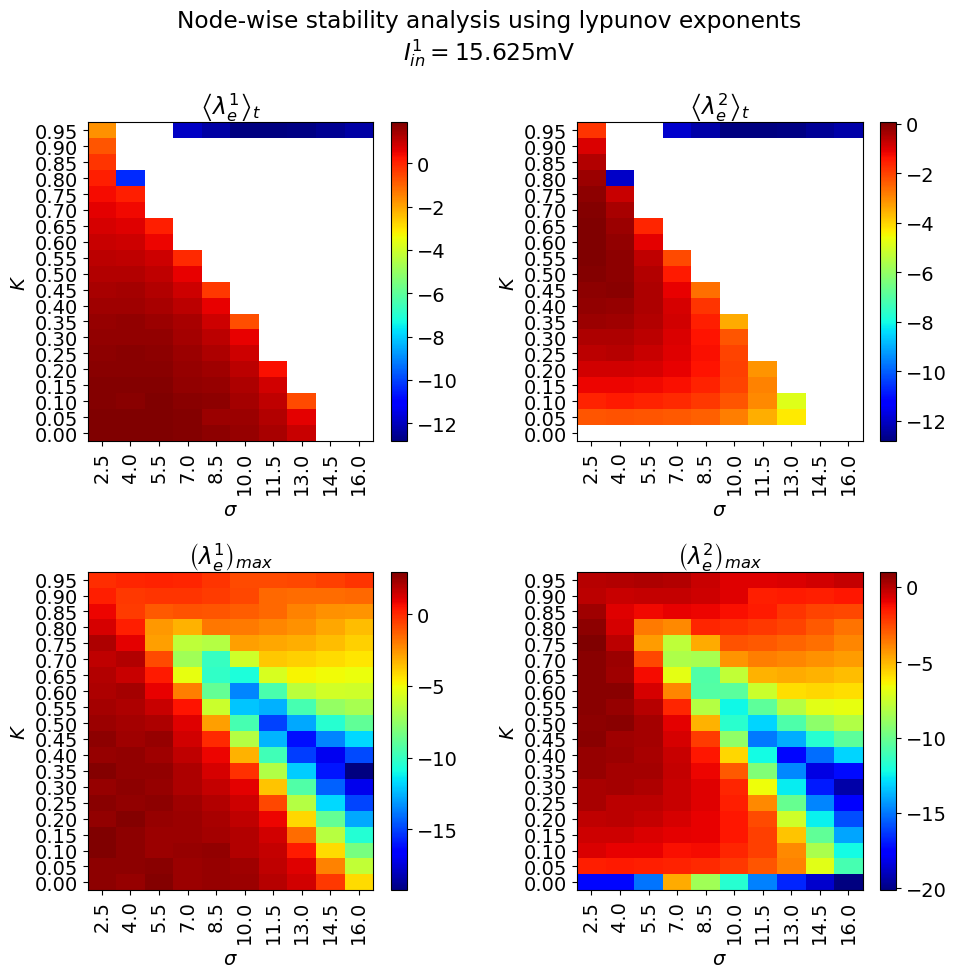

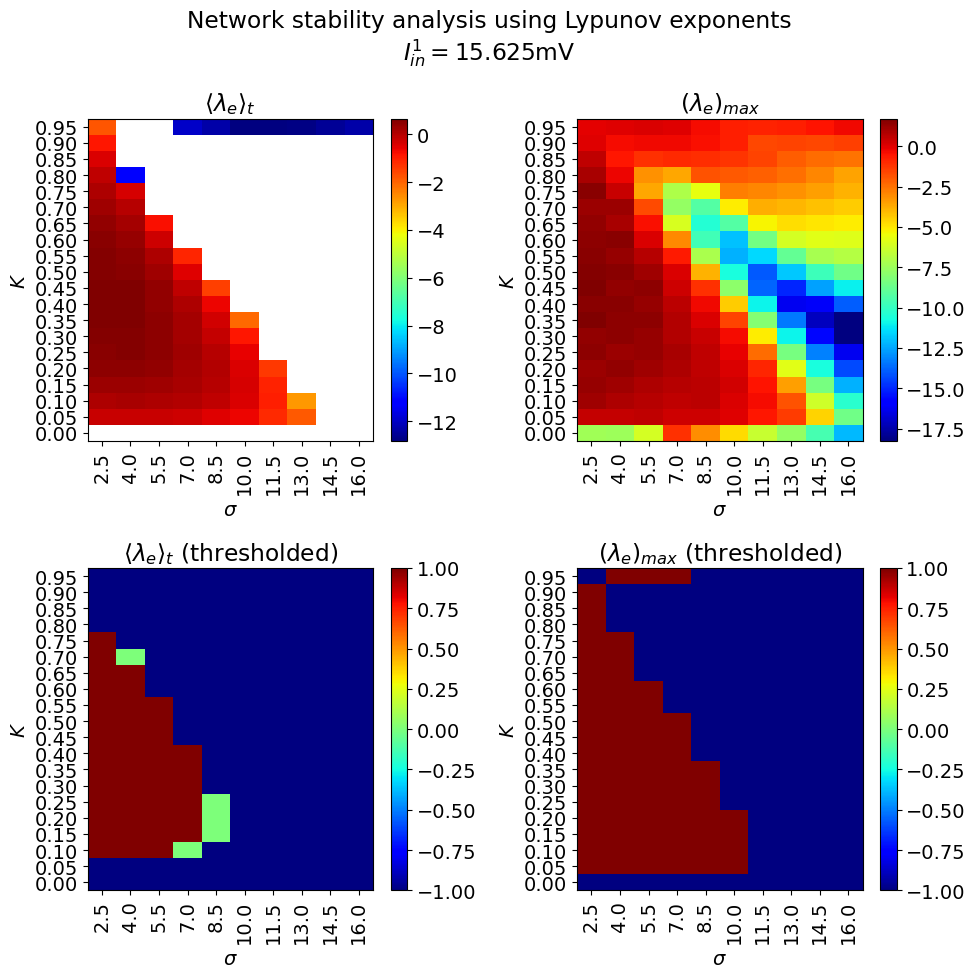

In [26]:
# lyapunov exponenet response maps K vs. sigma

file_name = f"lyap_ie_{params['i_e1']:.3f}"

if_plot_lyap = True
if_save_lyap = False
mask_thresh = 0.05

if os.path.isfile(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')):
    print(f"file found at {os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')} --> loading file...")
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'rb') as f:
        lyap_mats = pickle.load(f)
        
else:
    lyap_mats = {
                    'n1_mean': np.zeros((k_steps, sig_steps)),
                    'n2_mean': np.zeros((k_steps, sig_steps)),
                    'n1_max': np.zeros((k_steps, sig_steps)),
                    'n2_max': np.zeros((k_steps, sig_steps))
                }
    
    for k1, k in enumerate(eval_k):
        params['K'] = k
        
        tic = time.time()
        for s1, sigma in enumerate(eval_sigma):
            params['sig_e1'] = params['sig_e2'] = params['sig_i1'] = params['sig_i2'] = sigma
    
            u = np.zeros((n_trials, 4, T))
            u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
            
            lyapunov_1 = np.zeros((T - t_start - 1))
            for j in range(n_trials):
                diff_1 = np.abs(np.diff(u[j, 0, t_start:]))
                lyapunov_1 += 1 / n_trials * np.log(diff_1)
            
            lyapunov_2 = np.zeros((T - t_start - 1))
            for j in range(n_trials):
                diff_2 = np.abs(np.diff(u[j, 2, t_start:]))
                lyapunov_2 += 1 / n_trials * np.log(diff_2)
    
            lyap_mats['n1_mean'][k1, s1] = np.mean(lyapunov_1)
            lyap_mats['n2_mean'][k1, s1] = np.mean(lyapunov_2)
            lyap_mats['n1_max'][k1, s1] = lyapunov_1.max()
            lyap_mats['n2_max'][k1, s1] = lyapunov_2.max()
        toc = time.time()
        print(f'finishing k value --> Execution time: {toc - tic :.3f}s')
        
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'wb') as f:
        pickle.dump(lyap_mats, f)

# plotting

para_str = r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV"
plot_opts_dict = {'fig_size': (10, 10), 'ylabel': r'$K$', 'xlabel': r'$\sigma$', 'para_str': para_str} 
    
if if_plot_lyap:
    plot_lyapunov_nodes(
                        var1_arr = eval_k,
                        var2_arr = eval_sigma,
                        plot_opts = plot_opts_dict, 
                        save_dir = save_dir, 
                        if_save = if_save_lyap, 
                        image_name = file_name + '_node.png',
                        **lyap_mats
                        )

thresh_mean, thresh_max = plot_lyapunov_network(
                                                  var1_arr = eval_k, 
                                                  var2_arr = eval_sigma, 
                                                  mask_thresh = mask_thresh, 
                                                  if_plot = if_plot_lyap,
                                                  plot_opts = plot_opts_dict, 
                                                  save_dir = save_dir, 
                                                  if_save = if_save_lyap, 
                                                  image_name = file_name + '_net.png', 
                                                  **lyap_mats
                                                  )
thresh_node1_mean = lyapunov_threshold(lyap_mats['n1_mean'], mask_tau=mask_thresh)

In [ ]:
# spectral radius analysis and its link to stability with lyapunov exponent

spec_rad = np.zeros((k_steps, sig_steps))
spec_cent = np.zeros((k_steps, sig_steps))
x = np.arange(-50, 50, 0.01)

for k1, K in enumerate(eval_k):
    params['K'] = K 
    rad_stable = None; rad_unstable = None
    cent_stable = None; cent_unstable = None
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))
        
    rad_colors = plt.get_cmap('Reds')
    rad_colors = iter(rad_colors(np.linspace(0.2, 1, sig_steps)))
    
    eig_val_colors = plt.get_cmap('Reds')
    eig_val_colors = iter(eig_val_colors(np.linspace(0.2, 1, sig_steps)))
    
    file_str = f"K_{params['K']:.3f}_ie1_{params['i_e1']:.3f}"

    tic = time.time()
    for s1, sigma in enumerate(eval_sigma):
        params['sig_e1'] = params['sig_e2'] = params['sig_i1'] = params['sig_i2'] = sigma
        
        while True:
            fp_dict = calc_fixed_points(
                                        minval=minval,
                                        maxval=maxval,
                                        grid_res=1000,
                                        n_init=100,
                                        cal_grad=False,
                                        **params
            )
        
            if fp_dict['n_fps'] != 0:
                break
        
        eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
        rad_, center_, real_, img_ = spectrum_analysis(eig_dict['eigvals'])
        spec_rad[k1, s1] = rad_
        spec_cent[k1, s1] = center_
        
        lyap_val = thresh_node1_mean[k1, s1]

        if lyap_val == 1 or lyap_val == 0:
            rad_unstable = rad_
            cent_unstable = center_
        
        elif lyap_val == -1:
            rad_stable = rad_  
            cent_stable = center_
        
        color_rads = next(rad_colors)
        color_eig = next(eig_val_colors)
        
        para_str =  r'$K$ = ' + f"{params['K']:.2f}, " + r'$i_{in}^1$ = ' + f"{params['i_e1']:.3f}"
        ax[0].plot(real_, img_, '.', markersize=10, color=color_eig, label=r"$\sigma$" + f' = {sigma:.3f}, r = {rad_:.3f}')
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        
    toc = time.time()
    print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    if rad_unstable and rad_stable:
        rad_ = (rad_unstable + rad_stable) / 2    
        center_ = (cent_unstable + cent_stable) / 2
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--',  color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
    
    elif (rad_unstable is None) and rad_stable:
        rad_ = max(spec_rad[k1, :])
        center_ = spec_cent[k1, np.argmax(spec_rad[k1, :])]
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--',  color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
        
    ax[0].axvline(x=0, color='k', linestyle='--')
    ax[0].axis('equal')
    ax[0].grid(True)
    ax[0].set_xlabel(r'$\mathfrak{Re}$');
    ax[0].set_ylabel(r'$\mathfrak{Im}$')
        
    # sns.distplot(spec_rad[k1, :], kde=True, bins=20, hist=False, ax=ax[1])
    # _, _, bars = ax[1].hist(spec_rad[k1, :], bins = 100, color='red',alpha=0.25, density=True)
    markerline, stemlines, baseline = ax[1].stem(eval_sigma, spec_rad[k1, :])
    plt.setp(stemlines, linewidth=2, color='royalblue')
    plt.setp(baseline, visible=False)
    plt.setp(markerline, 'markerfacecolor', 'white', 'markeredgecolor', 'midnightblue', markersize = 8)
    ax[1].set_xlabel(r'$\sigma$'); ax[1].set_ylabel(r'$\Gamma$') 
    
    if (rad_unstable) and (rad_stable):
        ax[1].axhline(y=rad_, color='k', linestyle='--')
        ax[1].text(x = eval_sigma[sig_steps // 2], y = max(spec_rad[k1, :]) // 2, s = 'Unstable', color='red', fontsize=16, animated = True)
        ax[1].text(x = eval_sigma[sig_steps // 2], y = rad_ // 2, s = 'Stable', color='green', fontsize=16, animated = True)
        ax[1].text(x = eval_sigma[sig_steps // 2], y = rad_, s = f'{rad_:.3f}', color='k', fontsize=16)
        
    elif (rad_unstable is None) and (rad_stable):
        ax[1].text(x = eval_sigma[sig_steps // 2], y = max(spec_rad[k1, :]) // 2, s = 'Whole region is stable', color='green', fontsize=16, animated = True)
        
    else:
        ax[1].text(x = eval_sigma[sig_steps // 2], y = max(spec_rad[k1, :]) // 2, s = 'No stable region', color='red', fontsize=16, animated = True)
    
    
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.10), ncols=5, fancybox=True, shadow=True)
    plt.suptitle('Spectral radius analysis with change of ' + r"$\sigma$ vs.  $K$" + '\n' + para_str + '\n')
    plt.tight_layout()

    plt.savefig(os.path.join(save_dir, scene_sub_dir, file_str + '.png'), dpi=600, bbox_inches='tight')
    plt.show()

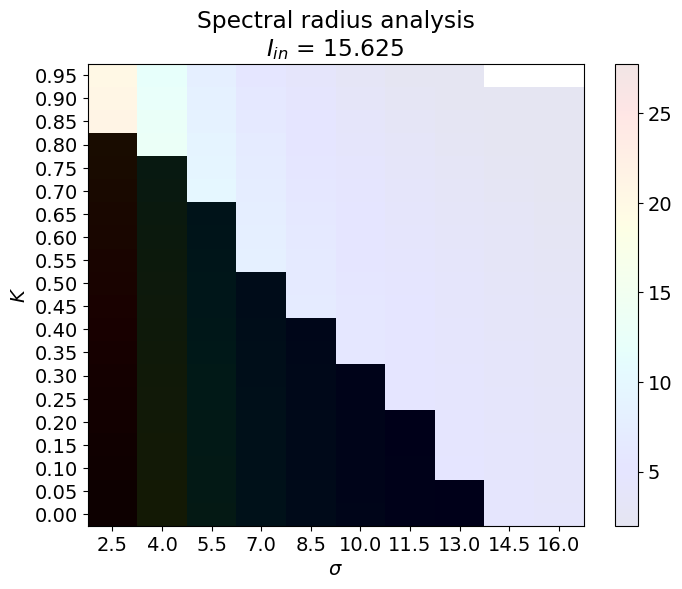

In [28]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(eval_sigma, eval_k, thresh_node1_mean, cmap='Greys', alpha=1.0)
plt.pcolormesh(eval_sigma, eval_k, spec_rad, cmap='jet', alpha=0.1)
plt.xlabel(r'$\sigma$'); plt.ylabel(r'$K$')
plt.xticks(eval_sigma); plt.yticks(eval_k)
plt.colorbar()
plt.title("Spectral radius analysis\n" + r"$I_{in}$ = " + f"{params['i_e1']}")
plt.savefig(os.path.join(save_dir, scene_sub_dir, f"ie_{params['i_e1']}_resmap.png"))
plt.show()

In [203]:
# ts analysis and trajectories
params['sig_e1'] = 4.4; params['sig_i1'] = 16.5; params['sig_e2'] = 7.8; params['sig_i2'] = 16.5
params['K'] = 0.2

In [204]:
u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

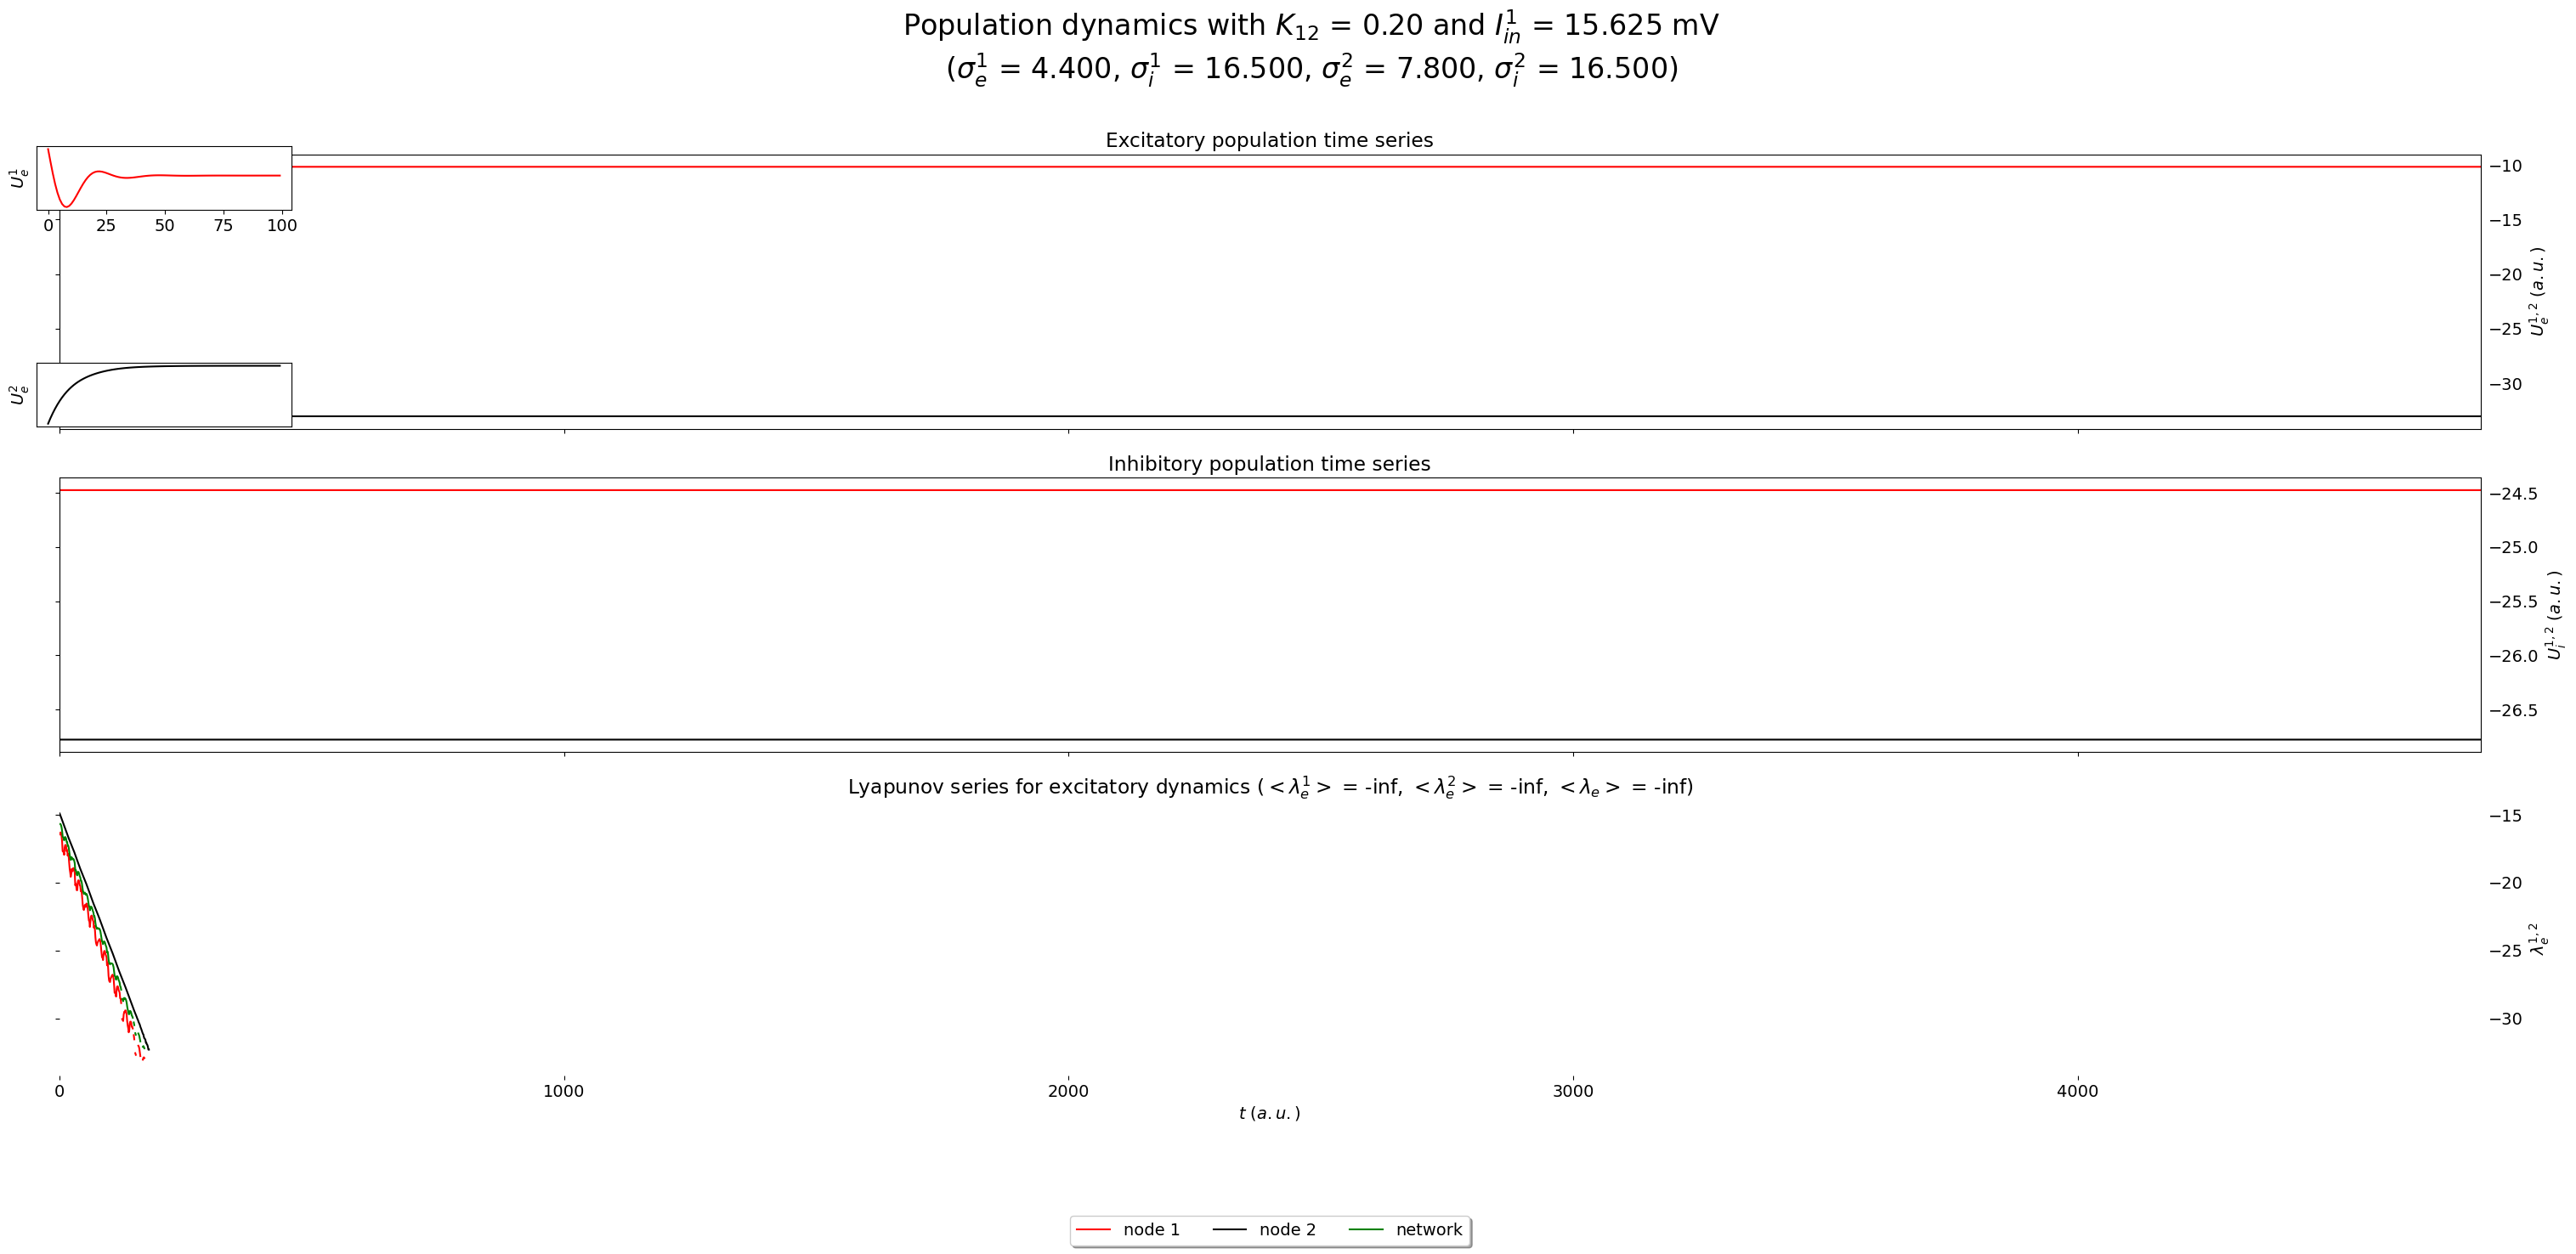

In [205]:
avg_lyap = plot_ts(
                    u = u,
                    t_arr = time_,
                    t1 = t_start,
                    t2 = T,
                    fig_size = (30, 15),
                    if_zoom=True,
                    zoom_t=[0, 100, 0, 100],
                    if_save=False,
                    save_dir=save_dir,
                    image_name=f"ts_sig_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}",
                    **params
                )

fp_dict = calc_fixed_points(
                                minval = minval,
                                maxval = maxval,
                                grid_res = 1000,
                                n_init = 100,
                                cal_grad = False,
                                **params
                            )

if fp_dict['n_fps'] == 0:
    u_ = np.zeros((1, 4, T))
    u_ = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
    
    fe1 = np.max(u_[0, 0, t_start:])
    fi1 = np.max(u_[0, 1, t_start:])
    fe2 = np.max(u_[0, 2, t_start:])
    fi2 = np.max(u_[0, 3, t_start:])
    
    fp_dict['fps'] = np.array([[fe1, fi1, fe2, fi2]]).T
    fp_dict['n_fps'] = 1
    
    del u_, fe1, fe2, fi1, fi2
    
eig_dict = calc_jacobian(fp_dict['fps'].T, **params)

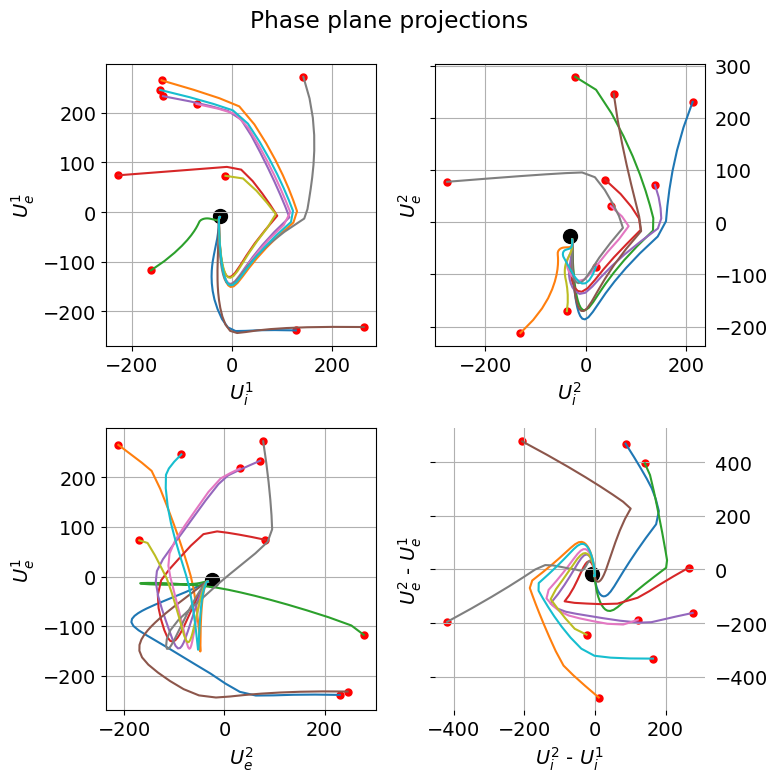

In [206]:
plot_trajectory(u, [x0_, x1_, x2_, x3_], (8, 8), **fp_dict)

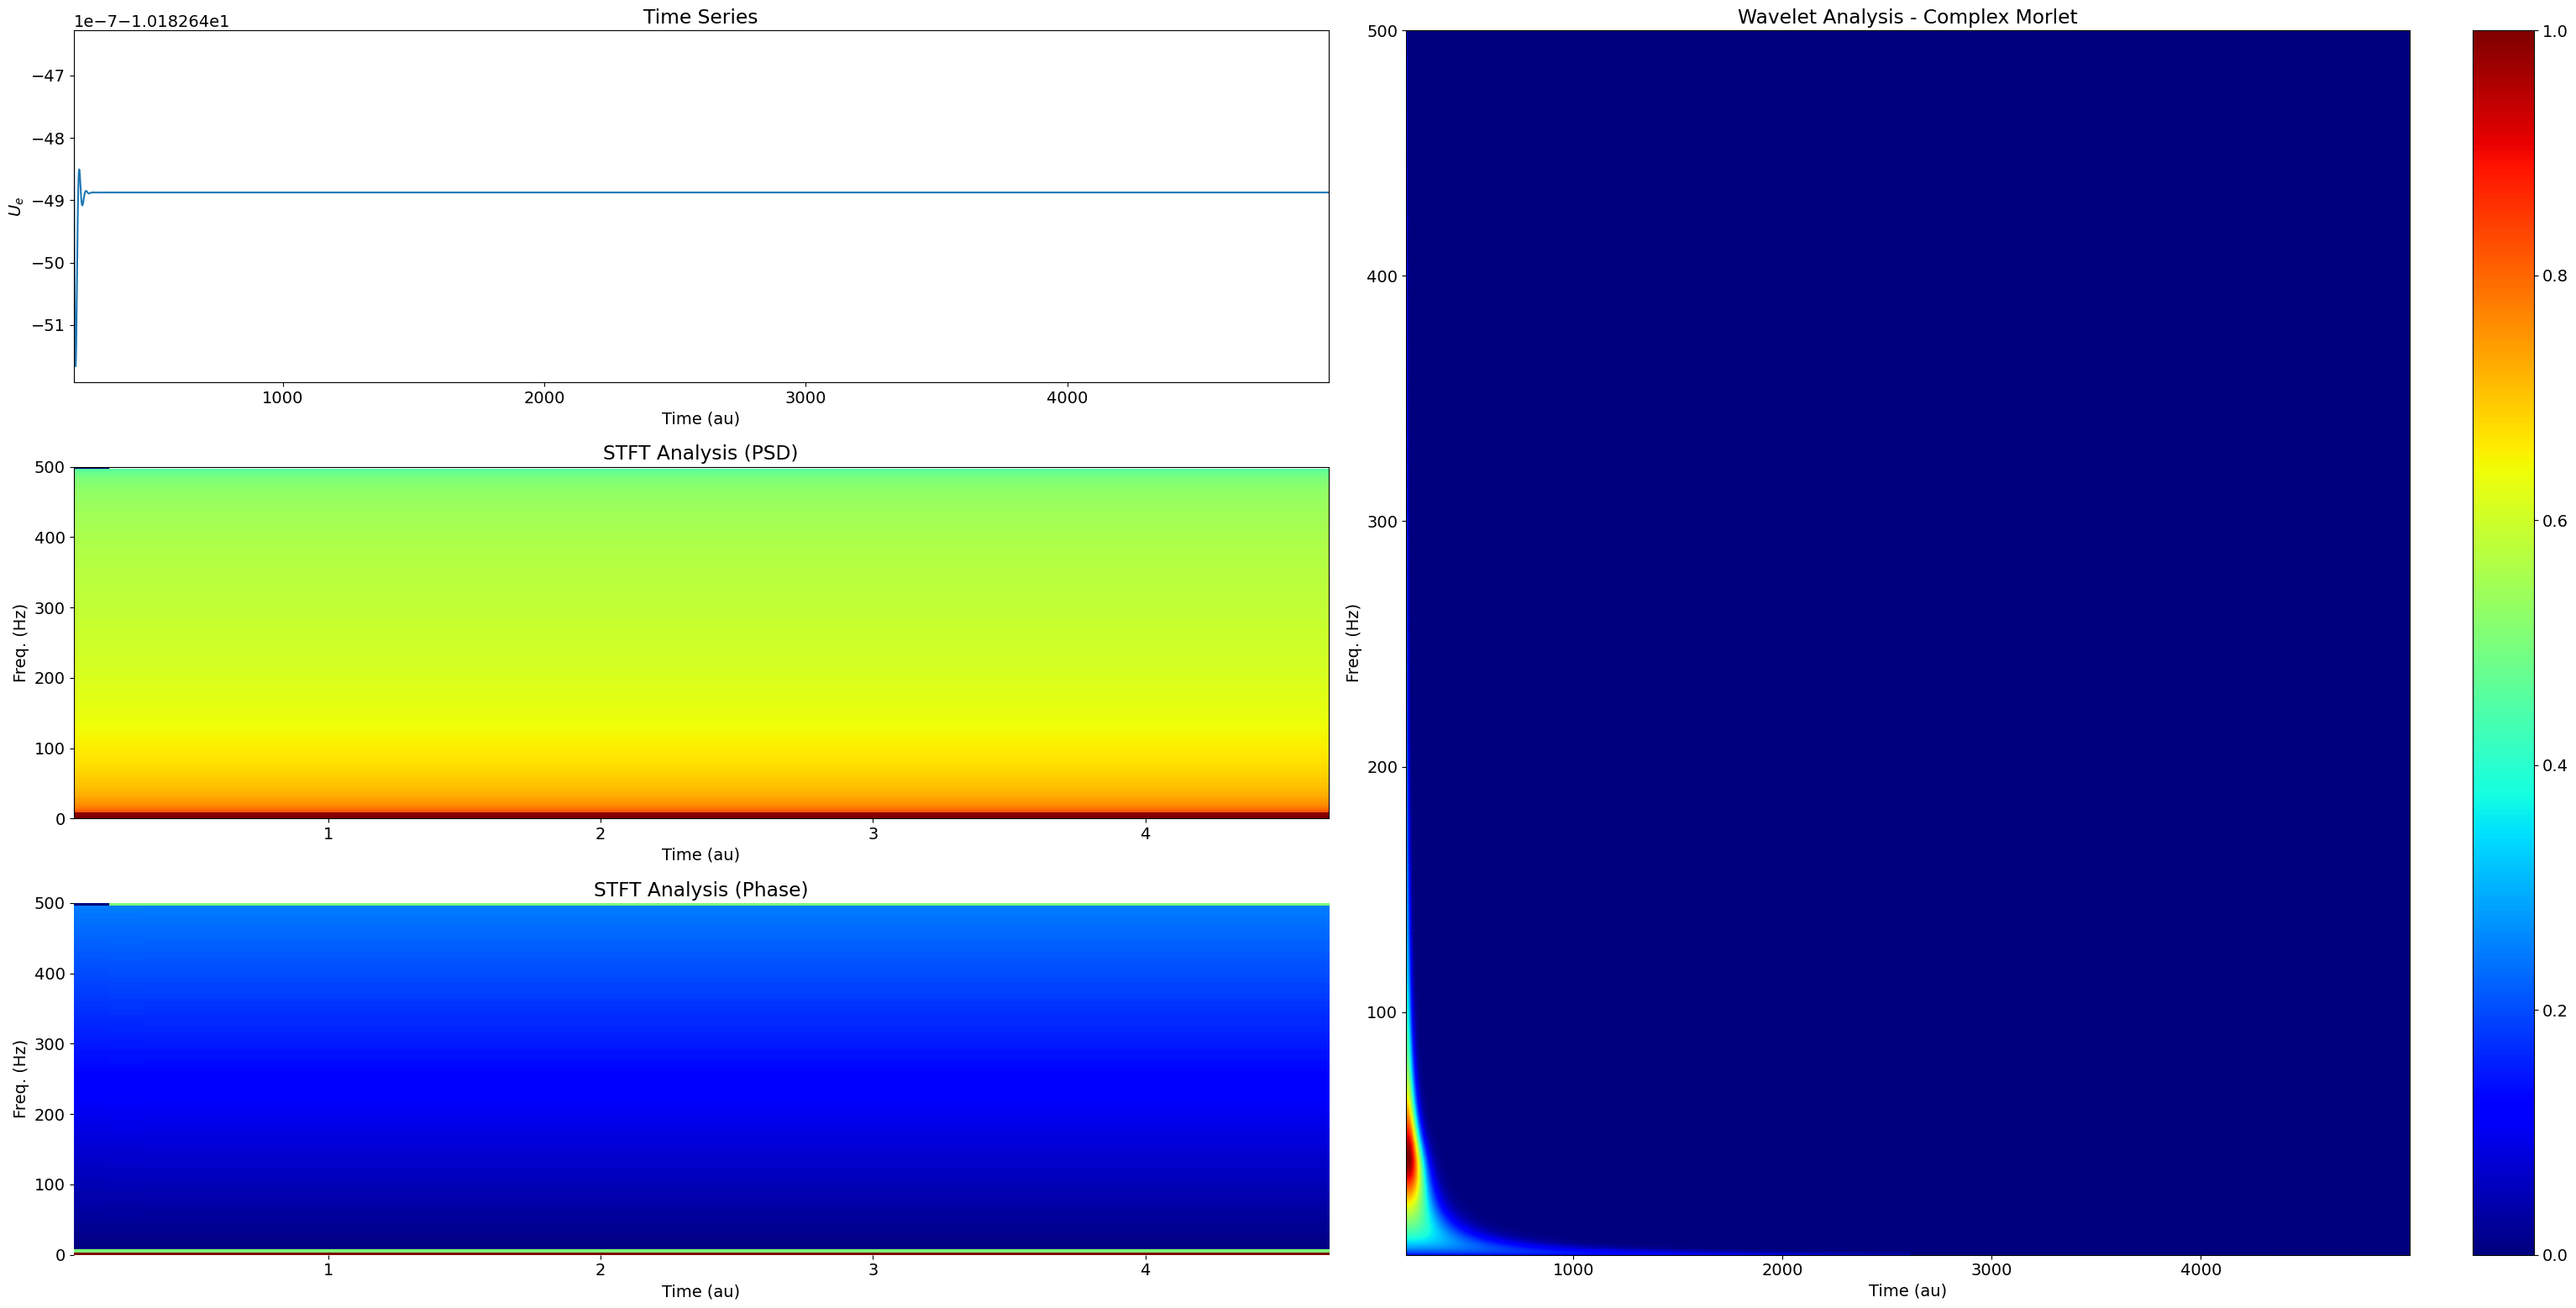

In [207]:
# wavelet analysis
plot_bool = True
ue1 = np.mean(u[:, 0, :], axis=0)
ui1 = np.mean(u[:, 1, :], axis=0)
ue2 = np.mean(u[:, 2, :], axis=0)
ui2 = np.mean(u[:, 3, :], axis=0)

freq_arr, wt_matr1 = wavelet_analysis(
                                     signals = ue1, 
                                     time_arr=time_, 
                                     t1 = t_start, 
                                     t2 = T-1, 
                                     center_freq = 12., 
                                     fs = 1000, 
                                     fig_size = (32, 16),
                                     save_dir = os.path.join(save_dir, scene_sub_dir),
                                     if_plot = plot_bool,
                                     if_save = False,
                                     img_name = f"ue1_spectral_sig_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}"
                                     )

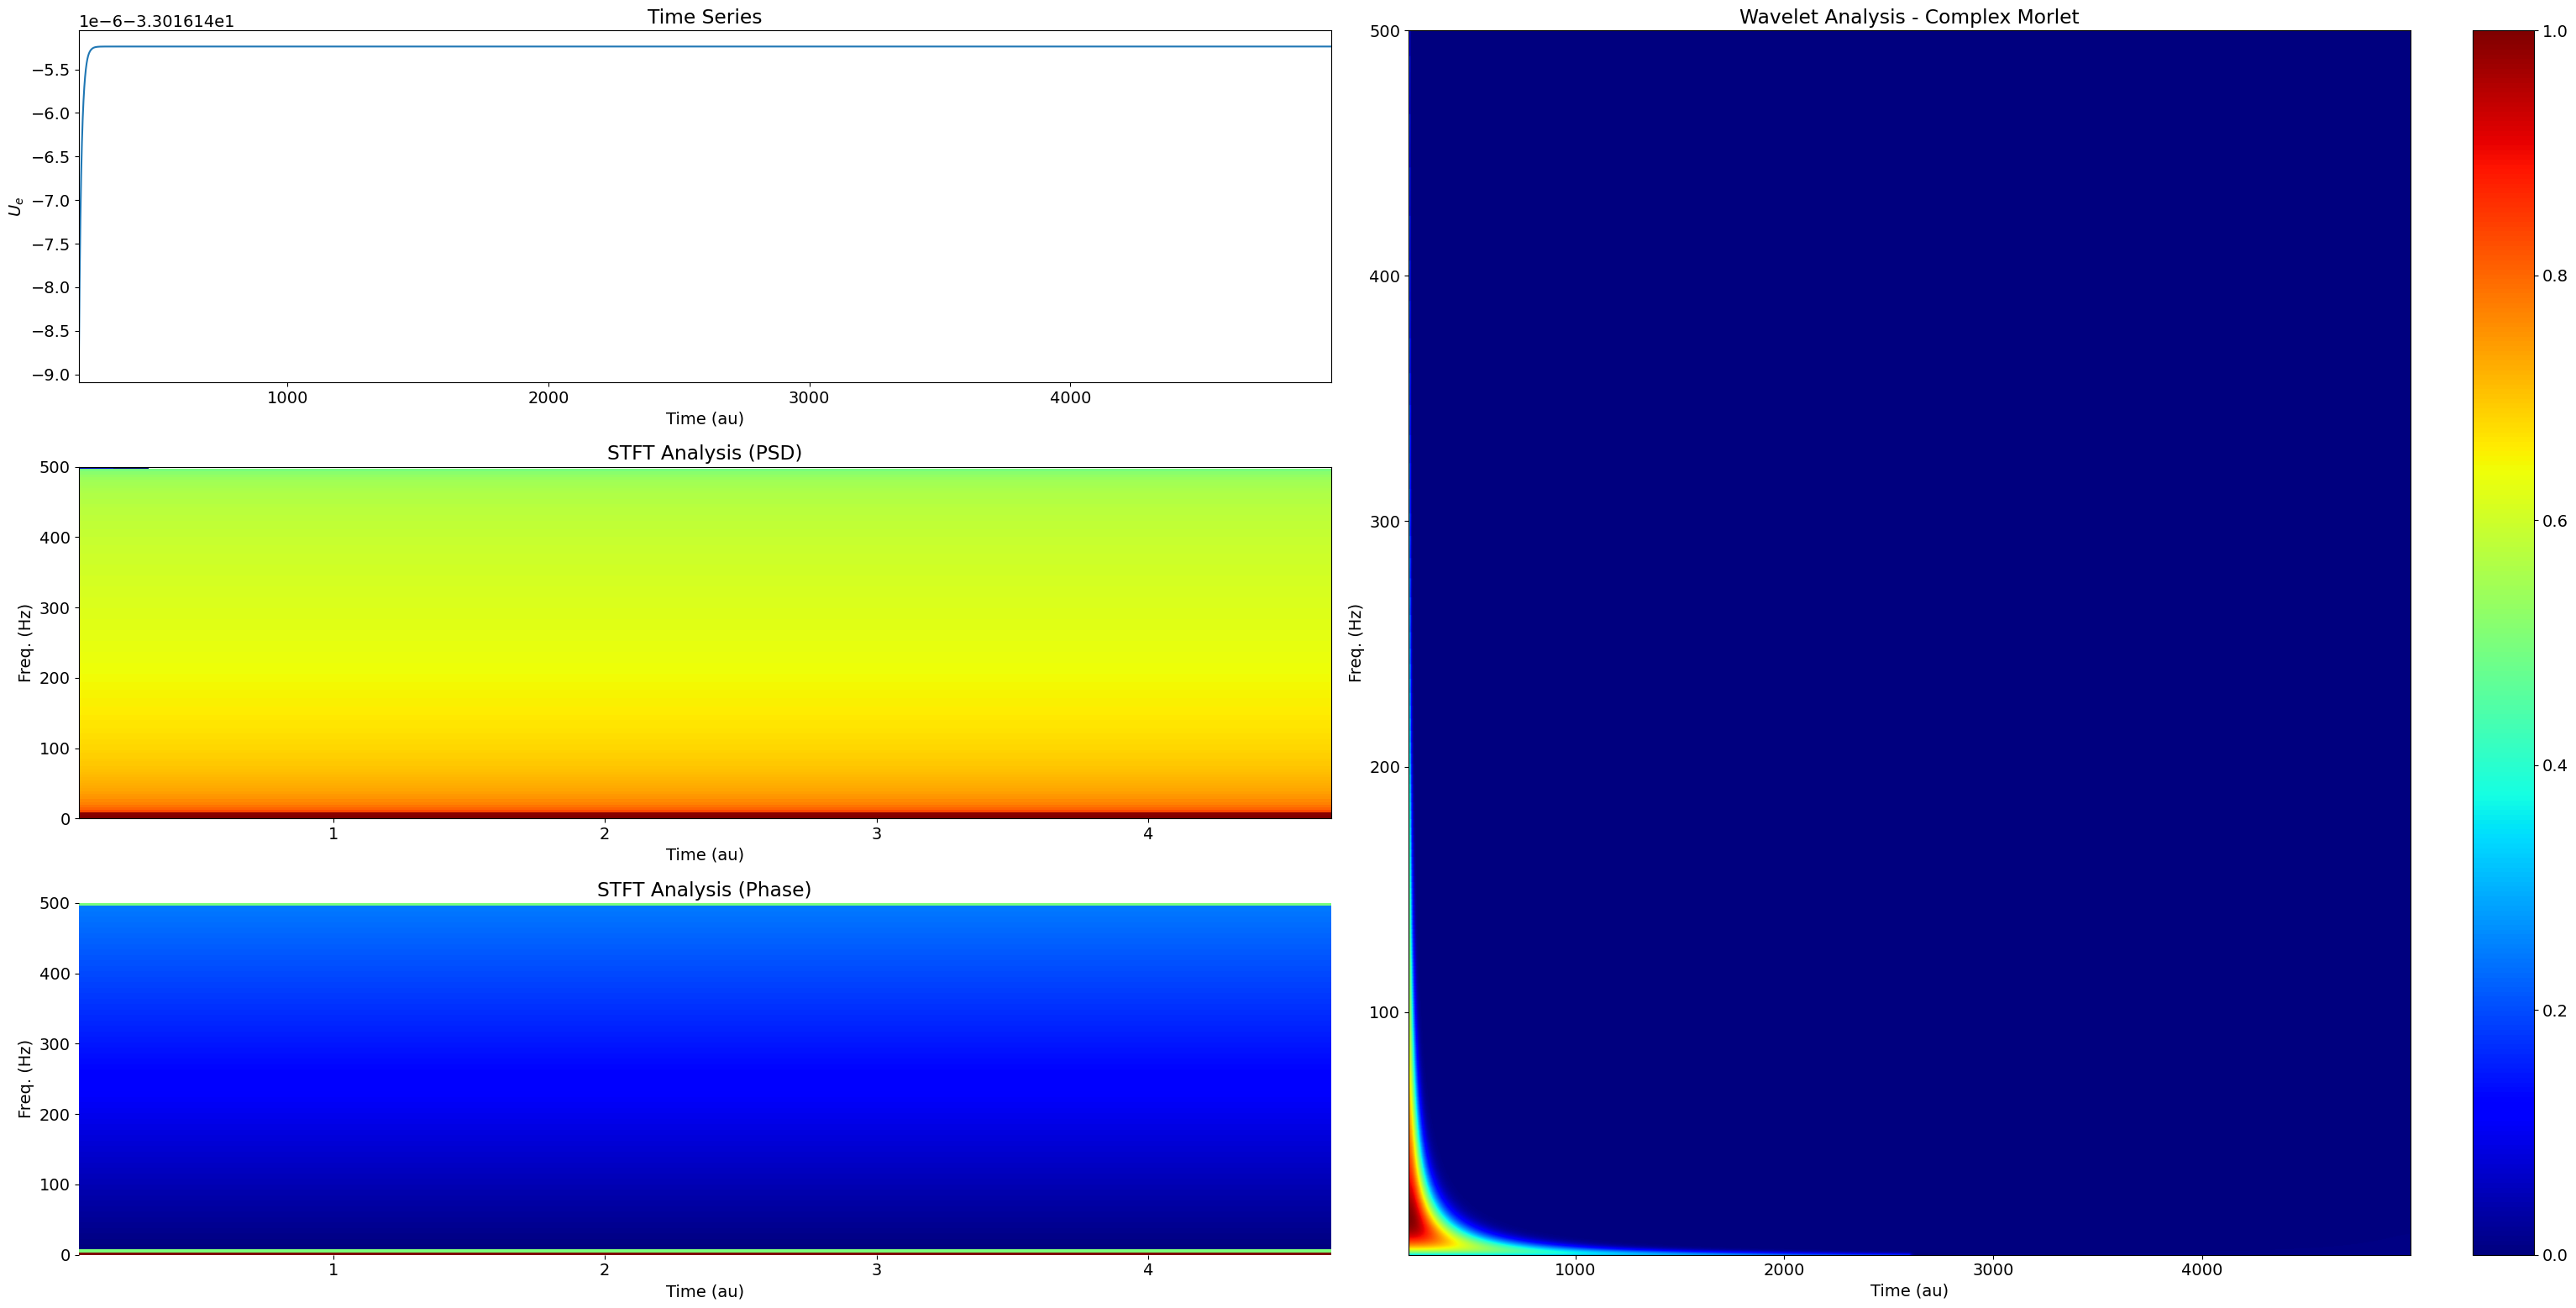

In [208]:
freq_arr, wt_matr2 = wavelet_analysis(
                                     signals = ue2, 
                                     time_arr=time_, 
                                     t1 = t_start, 
                                     t2 = T-1, 
                                     center_freq = 12., 
                                     fs = 1000, 
                                     fig_size = (32, 16),
                                     save_dir = os.path.join(save_dir, scene_sub_dir),
                                     if_plot = plot_bool,
                                     if_save = False,
                                     img_name = f"ue1_spectral_sig_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}"
                                     )

In [209]:
window_size = 200
step_window = 50

kuramoto_order = []

for t in range(t_start, T - window_size, step_window):
    ue = np.mean(u[:, 0, t : t + window_size], axis=0) + np.mean(u[:, 2, t : t + window_size], axis=0)
    ui = np.mean(u[:, 1, t : t + window_size], axis=0) + np.mean(u[:, 3, t : t + window_size], axis=0)
    real_kur = ue - np.mean(ue)
    img_kur = ui - np.mean(ui)

    kuramoto_order.append(np.mean(np.abs(real_kur + 1j * img_kur)))

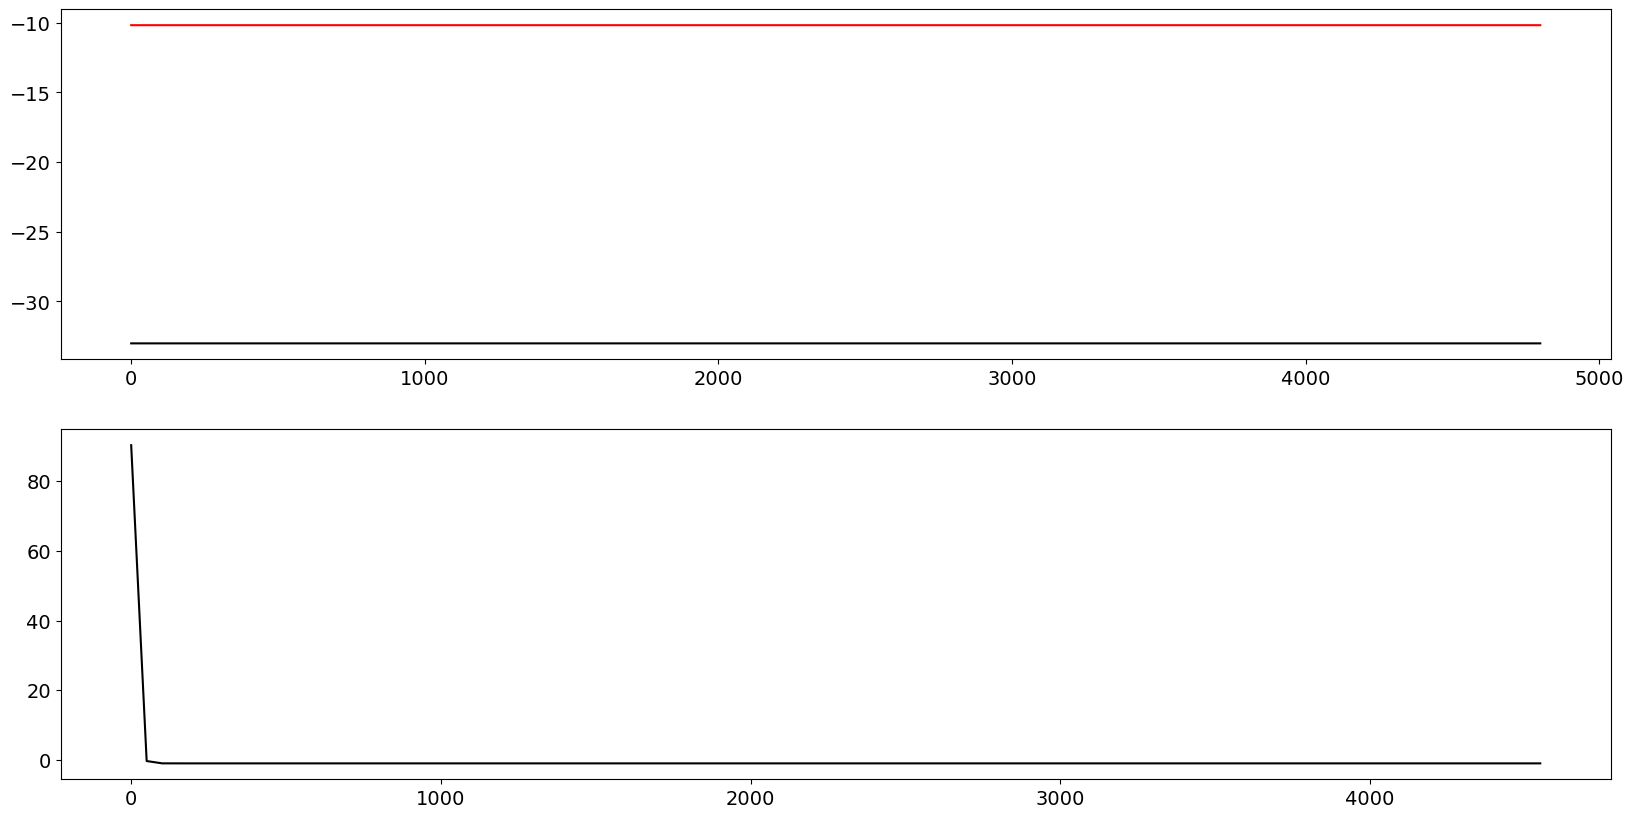

In [210]:
kuramoto_order = np.array(kuramoto_order)
norm_kuramoto = (kuramoto_order - np.mean(kuramoto_order)) / np.mean(kuramoto_order)

plt.figure(figsize=(20, 10))
plt.subplot(2, 1, 1)
plt.plot(time_[:-t_start], ue1[t_start:], 'r')
plt.plot(time_[:-t_start], ue2[t_start:], 'k')

plt.subplot(2, 1, 2)
plt.plot(time_[0:-t_start - window_size:step_window], norm_kuramoto, 'k')

In [211]:
psi_1_args = np.argmax(np.abs(wt_matr1), axis=0)
psi_2_args = np.argmax(np.abs(wt_matr2), axis=0)

In [213]:
psi_1 = np.array([np.unwrap(np.angle(wt_matr1[x, :])) for x in psi_1_args])
psi_2 = np.array([np.unwrap(np.angle(wt_matr2[x, :])) for x in psi_2_args])

np.abs(np.mean((np.max(np.abs(wt_matr1)) * np.exp(1j * psi_1) / (np.max(np.abs(wt_matr2)) * np.exp(1j * psi_2)))))

0.9245549914000374

## Scenario 02 - assume the $\sigma_e^l = \sigma_e$ and for $\sigma_i^l = \sigma_i$ $l = 1, 2$

In [29]:
# saving to separate sub-dir
scene_sub_dir = 's_02'
os.makedirs(os.path.join(save_dir, scene_sub_dir), exist_ok=True)

In [30]:
# setting constant values
params['K'] = 0.2
params['i_e1'] = 0.25 / params['gamma']

# setting variables
sige_min = 2.5; sige_max = 17.5; sige_steps = 10
sigi_min = 2.5; sigi_max = 17.5; sigi_steps = 10

eval_sigma_e = sige_min + np.arange(0, sige_steps) / sige_steps * (sige_max - sige_min)
eval_sigma_i = sigi_min + np.arange(0, sigi_steps) / sigi_steps * (sigi_max - sigi_min)

In [ ]:
# lyapunov exponenet response maps sigma_e vs. sigma_i

if_plot_lyap = True
if_save_lyap = False
mask_thresh = 0.05

file_name = f"lyap_K_{params['K']:.2f}_ie_{params['i_e1']:.3f}"

if os.path.isfile(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')):
    print(f"file found at {os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')} --> loading file...")
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'rb') as f:
        lyap_mats = pickle.load(f)

else:
    lyap_mats = {
                    'n1_mean': np.zeros((sige_steps, sigi_steps)),
                    'n2_mean': np.zeros((sige_steps, sigi_steps)),
                    'n1_max': np.zeros((sige_steps, sigi_steps)),
                    'n2_max': np.zeros((sige_steps, sigi_steps))
                }

    for e1, sigma_e in enumerate(eval_sigma_e):
        params['sig_e1'] = params['sig_e2'] = sigma_e
        tic = time.time()
        for i1, sigma_i in enumerate(eval_sigma_i):
            params['sig_i1'] = params['sig_i2'] = sigma_i
    
            u = np.zeros((n_trials, 4, T))
            u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
            
            lyapunov_1 = np.zeros((T - t_start - 1))
            for k in range(n_trials):
                diff_1 = np.abs(np.diff(u[k, 0, t_start:]))
                lyapunov_1 += 1 / n_trials * np.log(diff_1)
            
            lyapunov_2 = np.zeros((T - t_start - 1))
            for k in range(n_trials):
                diff_2 = np.abs(np.diff(u[k, 2, t_start:]))
                lyapunov_2 += 1 / n_trials * np.log(diff_2)
    
            lyap_mats['n1_mean'][e1, i1] = np.mean(lyapunov_1)
            lyap_mats['n2_mean'][e1, i1] = np.mean(lyapunov_2)
            lyap_mats['n1_max'][e1, i1] = lyapunov_1.max()
            lyap_mats['n2_max'][e1, i1] = lyapunov_2.max()
        toc = time.time()
        print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'wb') as f:
        pickle.dump(lyap_mats, f)

# plotting

para_str = r"($K = $" + f"{params['K']:.2f}, " + r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV)"
plot_opts_dict = {'fig_size': (10, 10), 'ylabel': r'$\sigma_e$', 'xlabel': r'$\sigma_i$', 'para_str': para_str} 
    
if if_plot_lyap:
    plot_lyapunov_nodes(
                        var1_arr = eval_sigma_e,
                        var2_arr = eval_sigma_i,
                        plot_opts = plot_opts_dict, 
                        save_dir = save_dir, 
                        if_save = if_save_lyap, 
                        image_name = file_name + '_node.png',
                        **lyap_mats
                        )

thresh_mean, thresh_max = plot_lyapunov_network(
                                                  var1_arr = eval_sigma_e, 
                                                  var2_arr = eval_sigma_i, 
                                                  mask_thresh = mask_thresh, 
                                                  if_plot = if_plot_lyap,
                                                  plot_opts = plot_opts_dict, 
                                                  save_dir = save_dir, 
                                                  if_save = if_save_lyap, 
                                                  image_name = file_name + '_net.png', 
                                                  **lyap_mats
                                                  )
thresh_node1_mean = lyapunov_threshold(lyap_mats['n1_mean'], mask_tau=mask_thresh)

In [ ]:
# spectral radius analysis and its link to stability with lyapunov exponent
spec_rad = np.zeros((sige_steps, sigi_steps))
spec_cent = np.zeros((sige_steps, sigi_steps))

x = np.arange(-50, 50, 0.01)

for e1, sig_e in enumerate(eval_sigma_e):
    params['sig_e1'] = params['sig_e2'] = sig_e
    rad_stable = None; rad_unstable = None
    cent_stable = None; cent_unstable = None
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))
        
    rad_colors = plt.get_cmap('Reds')
    rad_colors = iter(rad_colors(np.linspace(0.2, 1, sig_steps)))
    
    eig_val_colors = plt.get_cmap('Reds')
    eig_val_colors = iter(eig_val_colors(np.linspace(0.2, 1, sig_steps)))
    
    file_str = f"K_{params['K']:.3f}_ie1_{params['i_e1']:.3f}_sige_{params['sig_e1']:.3f}"

    tic = time.time()
    for i1, sig_i in enumerate(eval_sigma_i):
        params['sig_i1'] = params['sig_i2'] = sig_i
        
        while True:
            fp_dict = calc_fixed_points(
                                        minval=minval,
                                        maxval=maxval,
                                        grid_res=1000,
                                        n_init=100,
                                        cal_grad=False,
                                        **params
            )
        
            if fp_dict['n_fps'] != 0:
                break
        
        eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
        rad_, center_, real_, img_ = spectrum_analysis(eig_dict['eigvals'])
        spec_rad[e1, i1] = rad_
        spec_cent[e1, i1] = center_
        
        lyap_val = thresh_node1_mean[e1, i1]
        
        if lyap_val == 1:
            rad_unstable = rad_
            cent_unstable = center_
        
        elif lyap_val == -1 or lyap_val == 0:
            rad_stable = rad_  
            cent_stable = center_
        
        color_rads = next(rad_colors)
        color_eig = next(eig_val_colors)
        
        para_str =  r'$K$ = ' + f"{params['K']:.2f}, " + r'$i_{in}^1$ = ' + f"{params['i_e1']:.3f} " + r'$\sigma_e$ = ' + f"{params['sig_e1']:.3f}"
        ax[0].plot(real_, img_, '.', markersize=10, color=color_eig, label=r"$\sigma_i$" + f' = {sig_i:.3f}, r = {rad_:.3f}')
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        
    toc = time.time()
    print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    if (rad_unstable) and (rad_stable):
        rad_ = (rad_unstable + rad_stable) / 2    
        center_ = (cent_unstable + cent_stable) / 2
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--',  color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
    elif (rad_unstable is None) and (rad_stable):
        rad_ = max(spec_rad[e1, :])  
        center_ = spec_cent[e1, np.argmax(spec_rad[e1, :])]
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--',  color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
    
    ax[0].axvline(x=0, color='k', linestyle='--')
    ax[0].axis('equal')
    ax[0].grid(True)
    ax[0].set_xlabel(r'$\mathfrak{Re}$');
    ax[0].set_ylabel(r'$\mathfrak{Im}$')
        
    # sns.distplot(spec_rad[e1, :], kde=True, bins=20, hist=False, ax=ax[1])
    # _, _, bars = ax[1].hist(spec_rad[e1, :], bins = 100, color='red',alpha=0.25, density=True)
    markerline, stemlines, baseline = ax[1].stem(eval_sigma_i, spec_rad[e1, :])
    plt.setp(stemlines, linewidth=2, color='royalblue')
    plt.setp(baseline, visible=False)
    plt.setp(markerline, 'markerfacecolor', 'white', 'markeredgecolor', 'midnightblue', markersize = 8)
    ax[1].set_xlabel(r'$\sigma_i$'); ax[1].set_ylabel(r'$\Gamma$') 
    
    if rad_unstable and rad_stable:
        ax[1].axhline(y=rad_unstable, color='k', linestyle='--')
        ax[1].text(x = eval_sigma_i[sigi_steps // 2], y = max(spec_rad[e1, :]) // 2, s = 'Unstable', color='red', fontsize=16, animated = True)
        ax[1].text(x = eval_sigma_i[sigi_steps // 2], y = rad_ // 2, s = 'Stable', color='green', fontsize=16, animated = True)
        ax[1].text(x = eval_sigma_i[sigi_steps // 2], y = rad_unstable, s = f'{rad_unstable:.3f}', color='k', fontsize=16)
        
    elif (rad_unstable is None) and rad_stable:
        ax[1].text(x = eval_sigma_i[sigi_steps // 2], y = max(spec_rad[e1, :]) // 2, s = 'Whole region is stable', color='green', fontsize=16, animated = True)
        
    else:
        ax[1].text(x = eval_sigma_i[sigi_steps // 2], y = max(spec_rad[e1, :]) // 2, s = 'No stable region', color='red', fontsize=16, animated = True)
    
    
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.10), ncols=5, fancybox=True, shadow=True)
    plt.suptitle('Spectral radius analysis with change of ' + r"$\sigma_e$ vs.  $\sigma_i$" + '\n' + para_str + '\n')
    plt.tight_layout()

    plt.savefig(os.path.join(save_dir, scene_sub_dir, file_str + '.png'), dpi=600, bbox_inches='tight')
    plt.show()

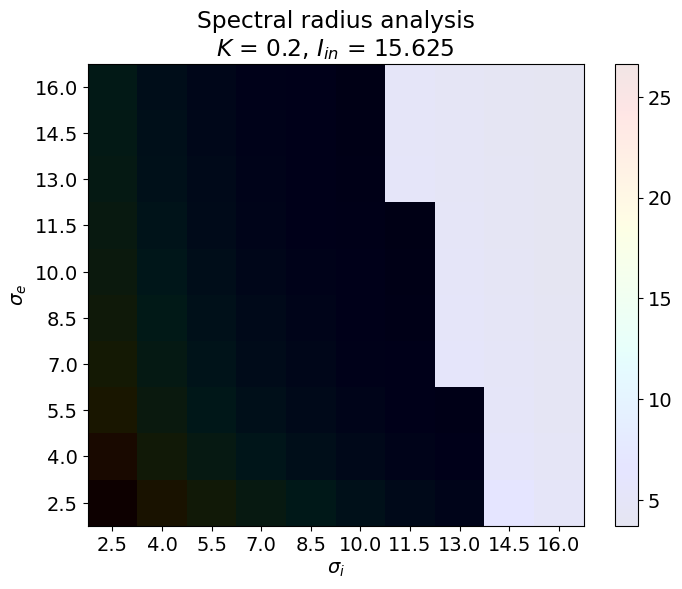

In [34]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(eval_sigma_e, eval_sigma_i, thresh_node1_mean, cmap='Greys', alpha=1.0)
plt.pcolormesh(eval_sigma_e, eval_sigma_i, spec_rad, cmap='jet', alpha=0.1)
plt.xlabel(r'$\sigma_i$'); plt.ylabel(r'$\sigma_e$')
plt.xticks(eval_sigma_i); plt.yticks(eval_sigma_e)
plt.colorbar()
plt.title("Spectral radius analysis\n" + r"$K$ = " + f"{params['K']}, " + r"$I_{in}$ = " + f"{params['i_e1']}")
plt.savefig(os.path.join(save_dir, scene_sub_dir, f"K_{params['K']}_ie_{params['i_e1']}_resmap.png"))
plt.show()

In [51]:
# ts analysis and trajectories
params['sig_e1'] =  params['sig_e2'] = 7
params['sig_i1'] =params['sig_i2'] = 16

In [52]:
u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

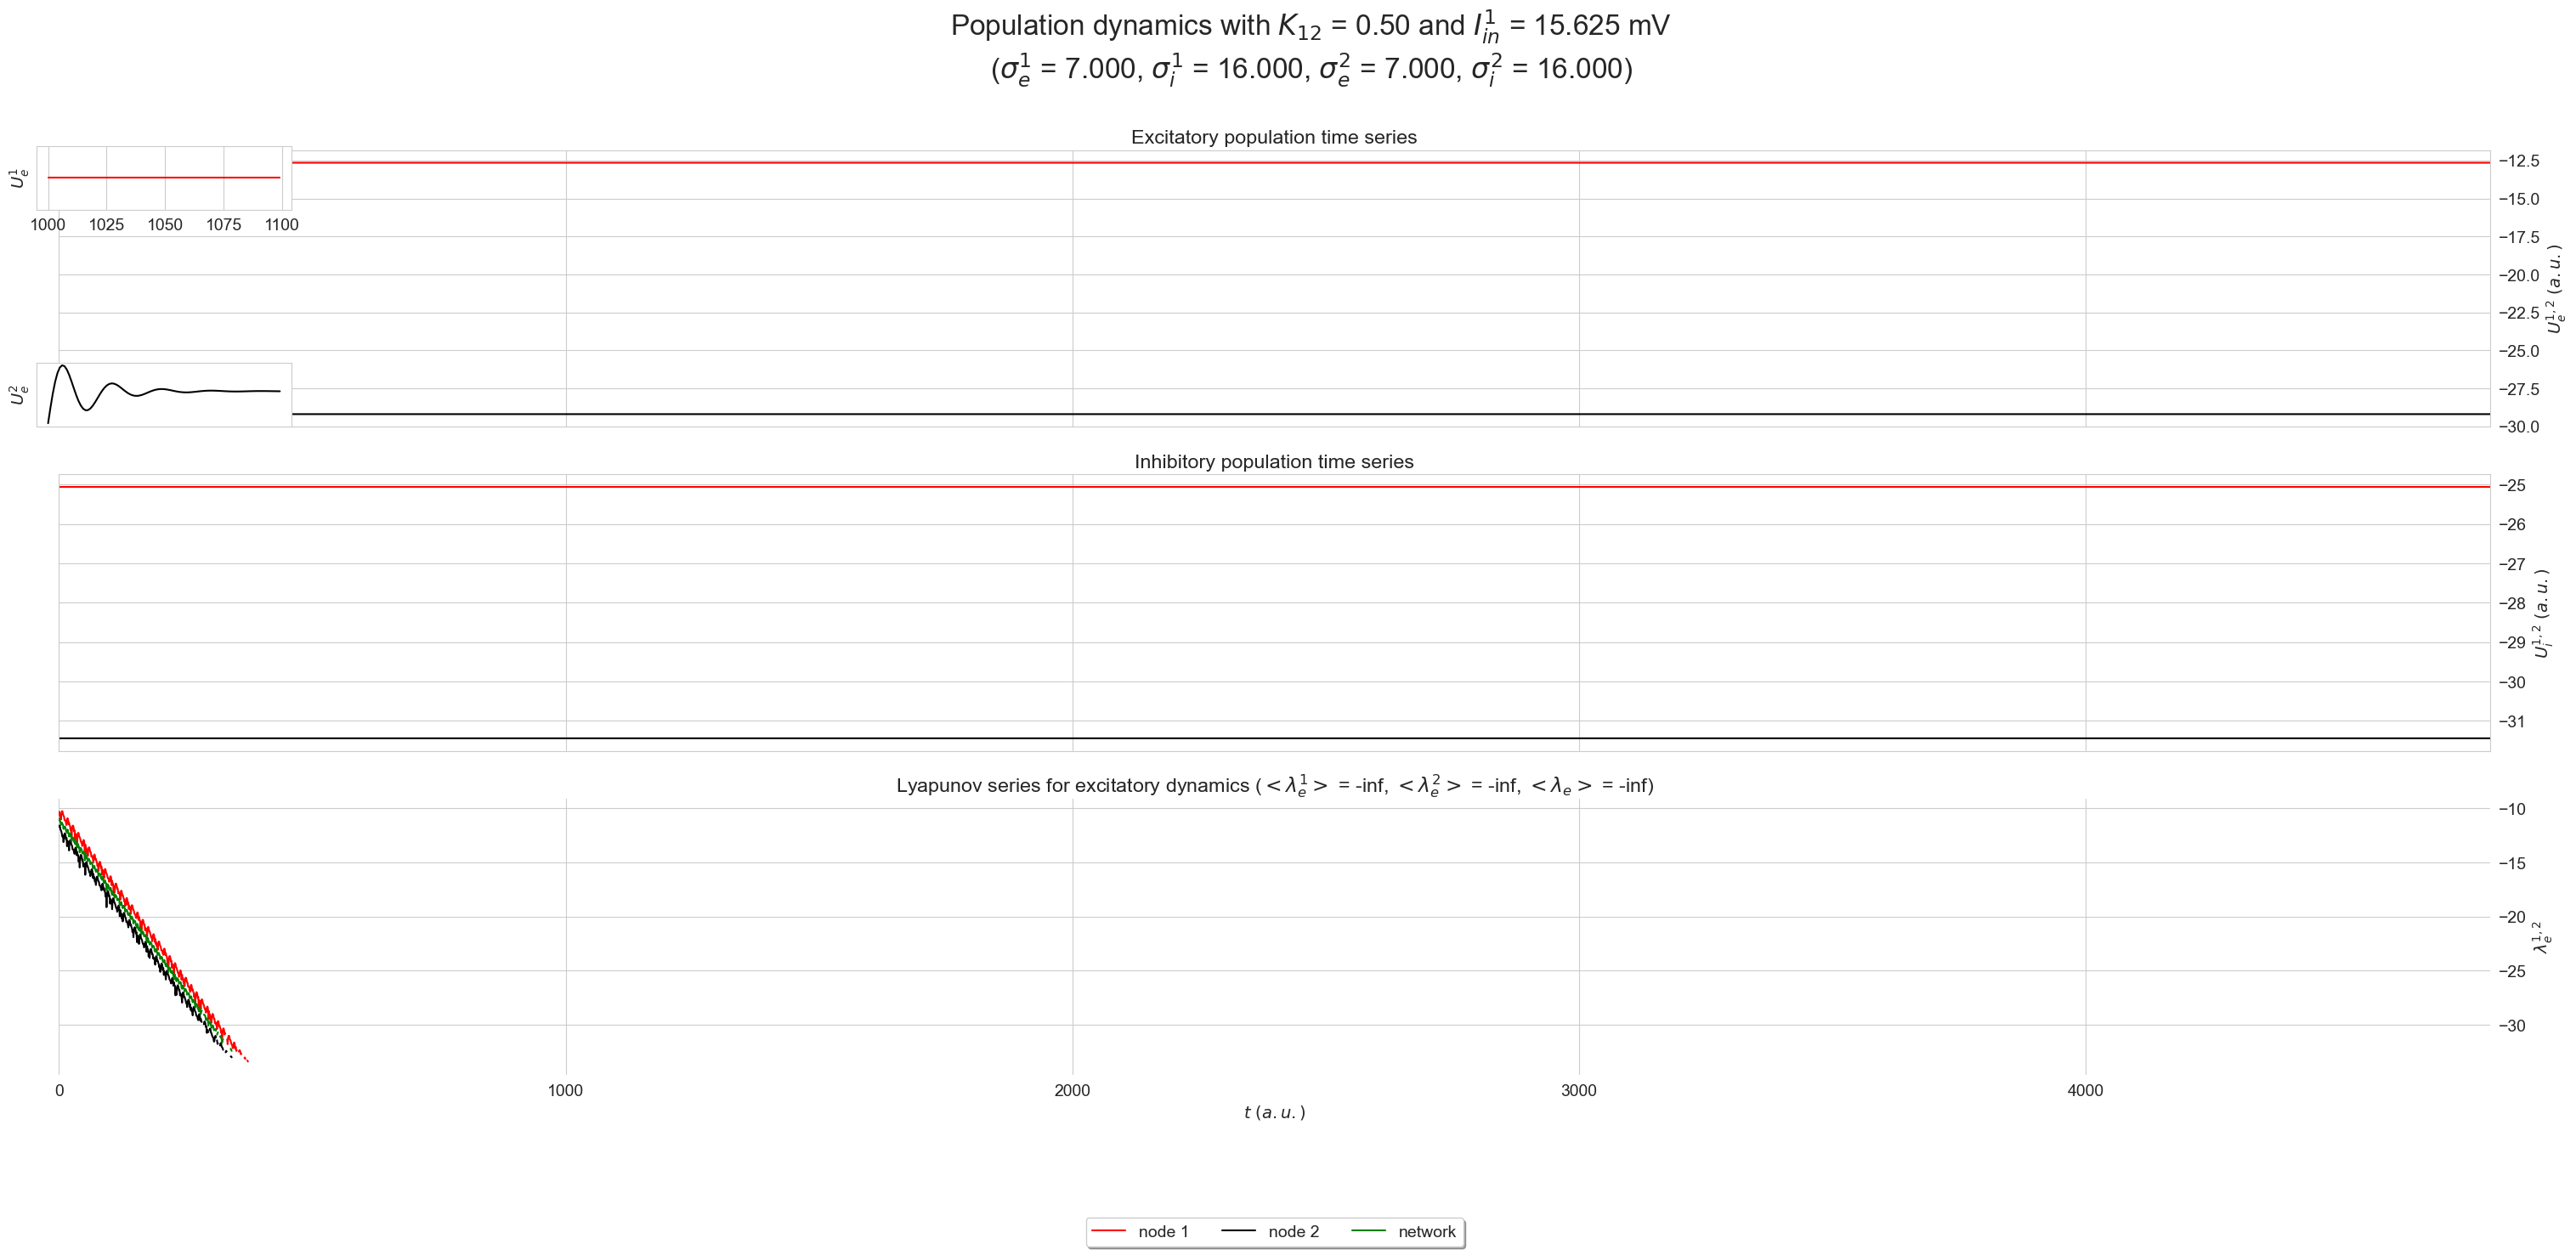

In [53]:
avg_lyap = plot_ts(
                    u = u,
                    t_arr = time_,
                    t1 = t_start,
                    t2 = T,
                    fig_size = (30, 15),
                    if_zoom=True,
                    zoom_t=[1000, 1100, 0, 100],
                    if_save=False,
                    save_dir=save_dir,
                    image_name=f"ts_sige_{params['sig_e1']:.3f}_sigi_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}",
                    **params
                )

fp_dict = calc_fixed_points(
                                minval = minval,
                                maxval = maxval,
                                grid_res = 1000,
                                n_init = 100,
                                cal_grad = False,
                                **params
                            )

if fp_dict['n_fps'] == 0:
    u_ = np.zeros((1, 4, T))
    u_ = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
    
    fe1 = np.max(u_[0, 0, t_start:])
    fi1 = np.max(u_[0, 1, t_start:])
    fe2 = np.max(u_[0, 2, t_start:])
    fi2 = np.max(u_[0, 3, t_start:])
    
    fp_dict['fps'] = np.array([[fe1, fi1, fe2, fi2]]).T
    fp_dict['n_fps'] = 1
    
    del u_, fe1, fe2, fi1, fi2
    
eig_dict = calc_jacobian(fp_dict['fps'].T, **params)

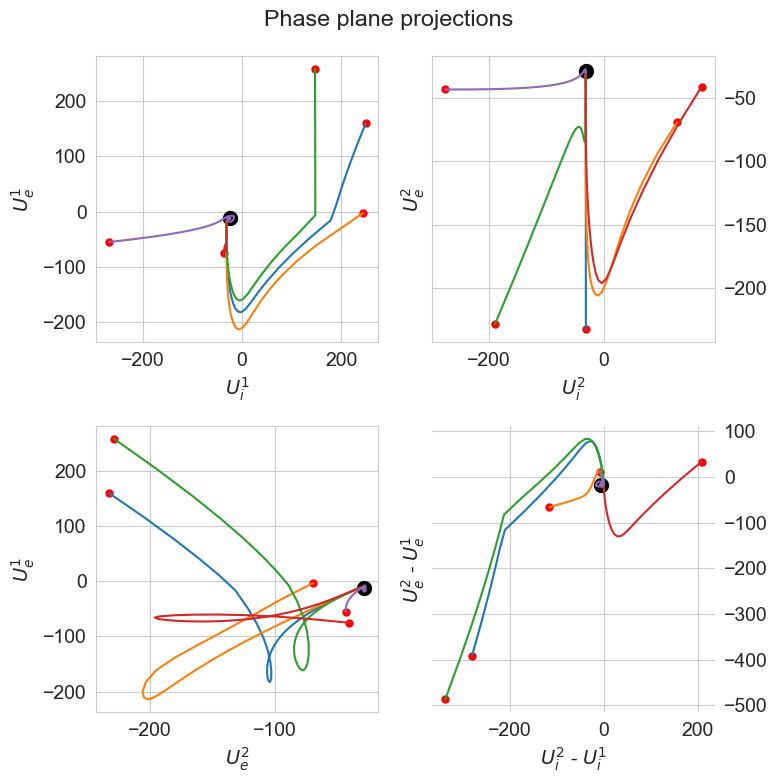

In [54]:
plot_trajectory(u, [x0_, x1_, x2_, x3_], (8, 8), **fp_dict)

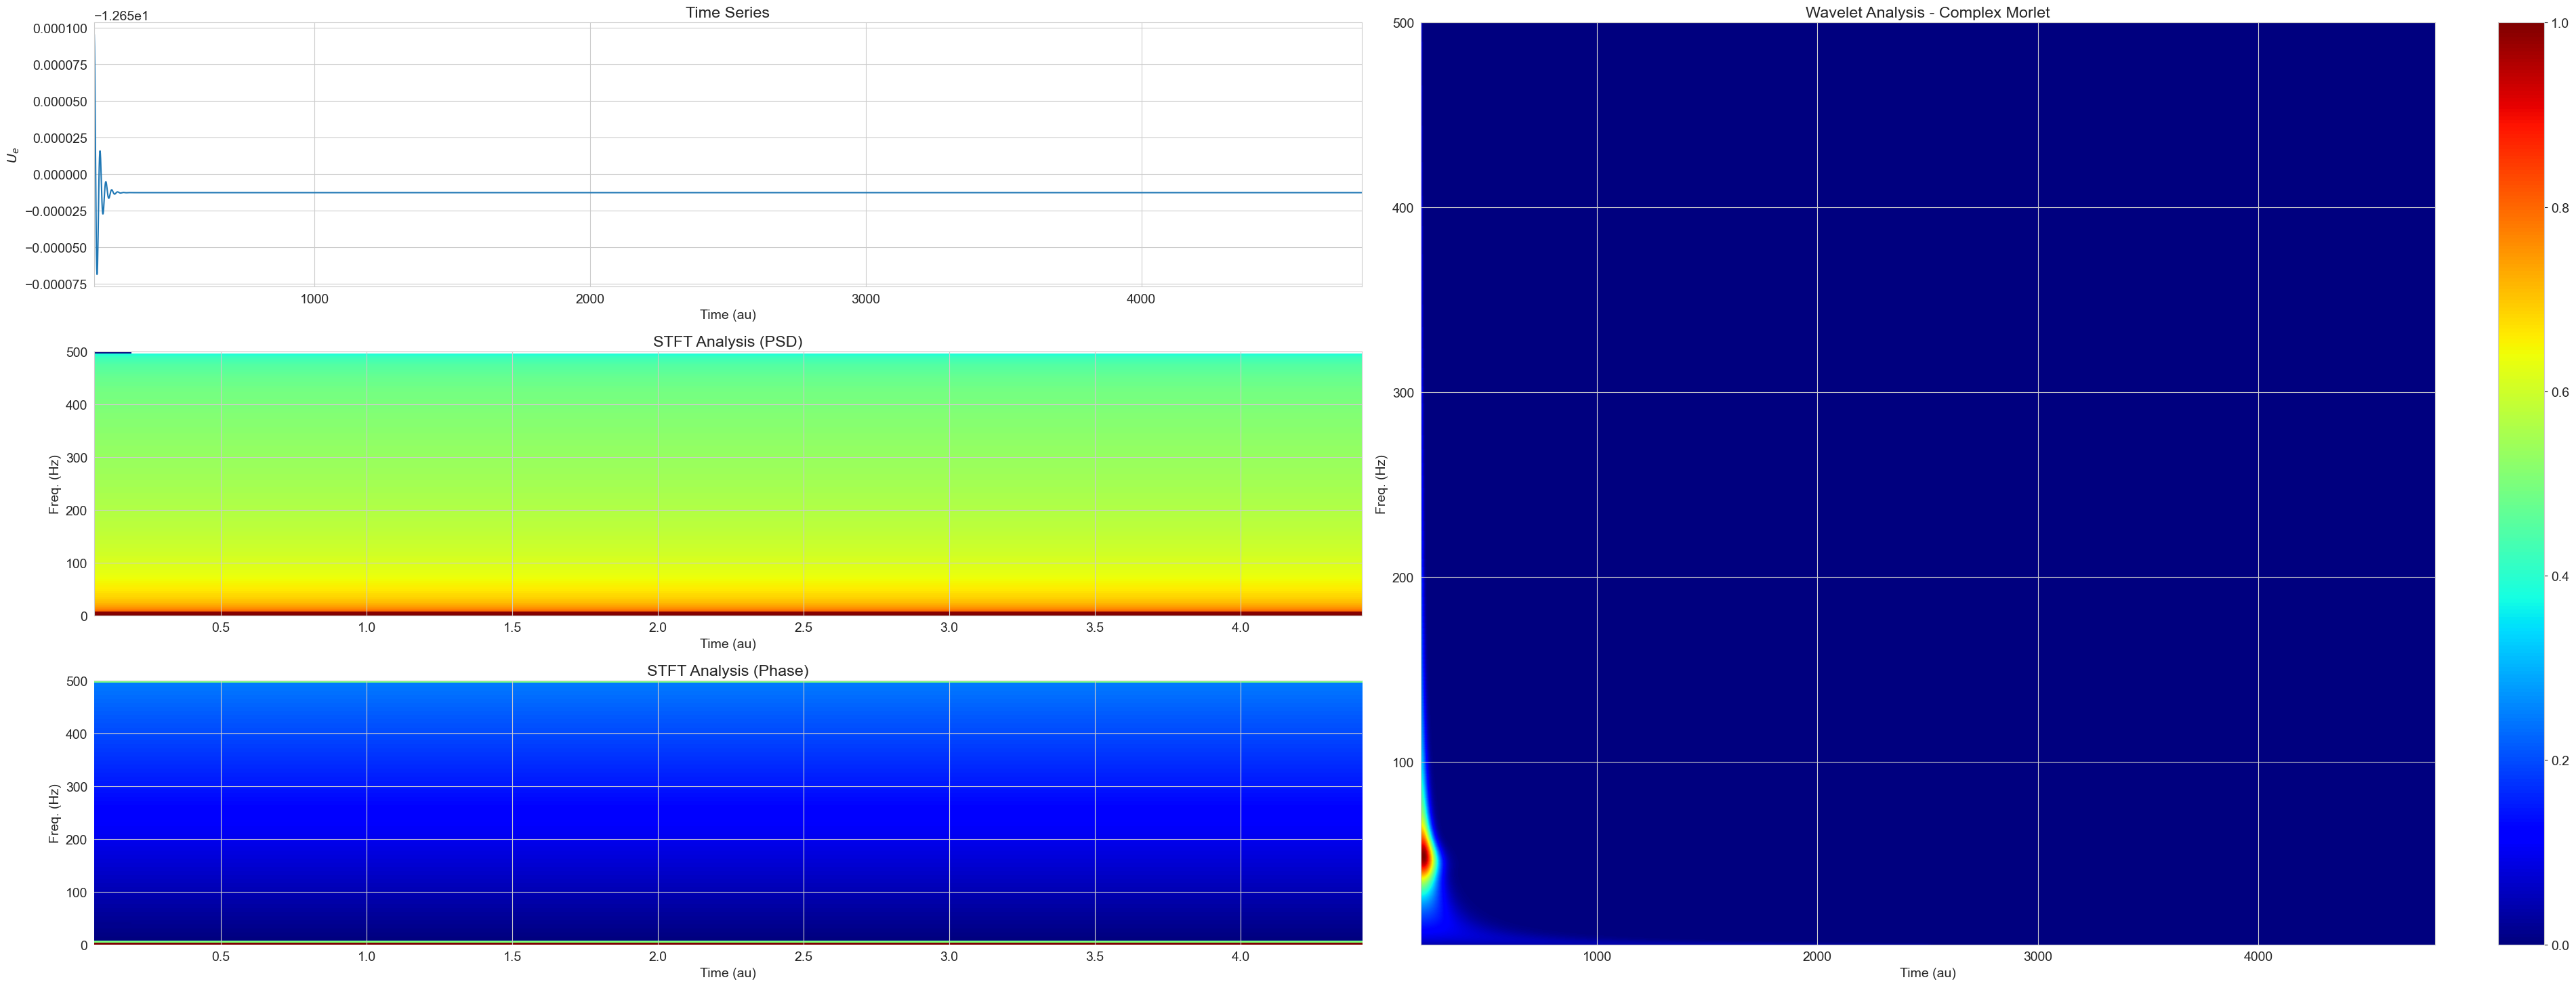

In [55]:
# wavelet analysis
plot_bool = True
ue1 = np.mean(u[:, 0, :], axis=0)
ui1 = np.mean(u[:, 1, :], axis=0)
ue2 = np.mean(u[:, 2, :], axis=0)
ui2 = np.mean(u[:, 3, :], axis=0)

freq_arr, wt_matr = wavelet_analysis(
                                     signals = ue1, 
                                     time_arr=time_, 
                                     t1 = t_start, 
                                     t2 = T - t_start, 
                                     center_freq = 12., 
                                     fs = 1000, 
                                     fig_size = (40, 15),
                                     save_dir = os.path.join(save_dir, scene_sub_dir),
                                     if_plot = plot_bool,
                                     if_save = False,
                                     img_name = f"ue1_spectral_sige_{params['sig_e1']:.3f}_sigi_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}"
                                     )

## Scenario 03 - assume the $\sigma_x^1 = \sigma^1$ and for $\sigma_x^2 = \sigma^2$ $x = \{e, i\}$

In [14]:
# saving to separate sub-dir
scene_sub_dir = 's_03'
os.makedirs(os.path.join(save_dir, scene_sub_dir), exist_ok=True)

In [17]:
# setting constant values
params['K'] = 0.0
params['i_e1'] = 0.25 / params['gamma']

# setting variables
sig1_min = 2.5; sig1_max = 17.5; sig1_steps = 10
sig2_min = 2.5; sig2_max = 17.5; sig2_steps = 10

eval_sigma_1 = sig1_min + np.arange(0, sig1_steps) / sig1_steps * (sig1_max - sig1_min)
eval_sigma_2 = sig2_min + np.arange(0, sig2_steps) / sig2_steps * (sig2_max - sig2_min)

file found at ./sv_coupled_model_m\exp-2023-11-18\s_03\lyap_K_0.00_ie_15.625.pkl --> loading file...


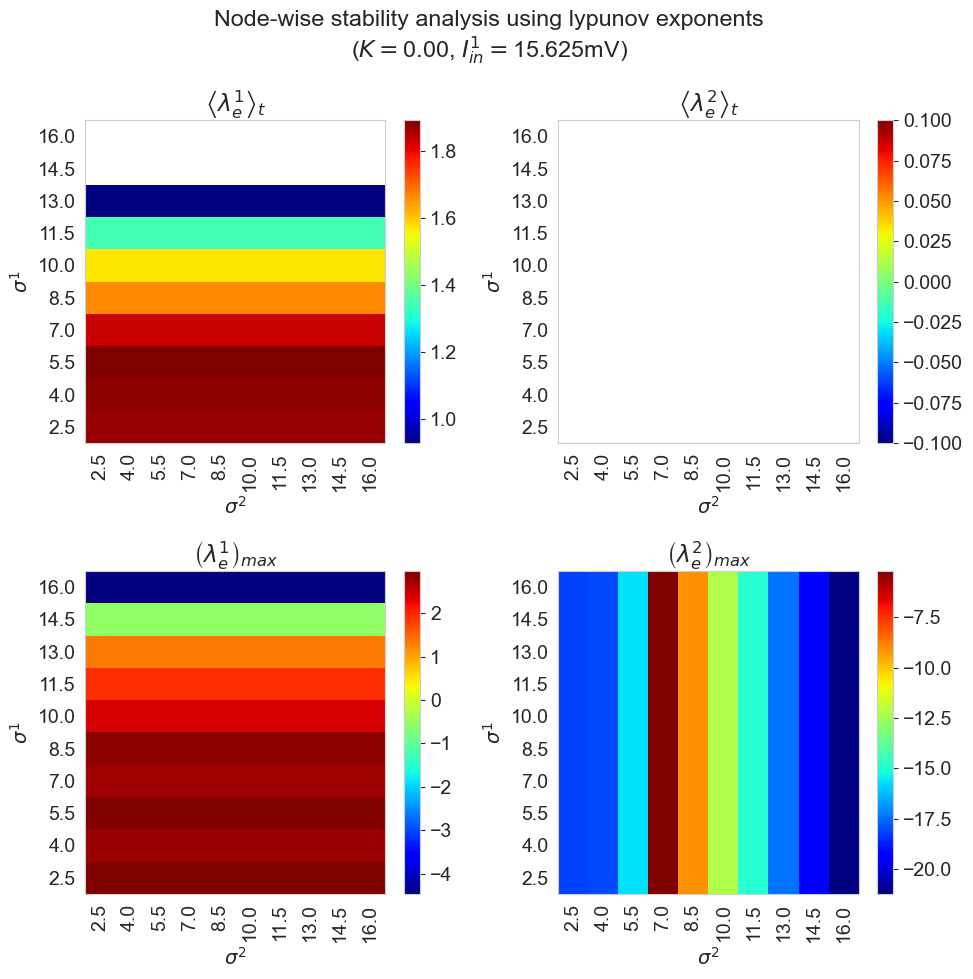

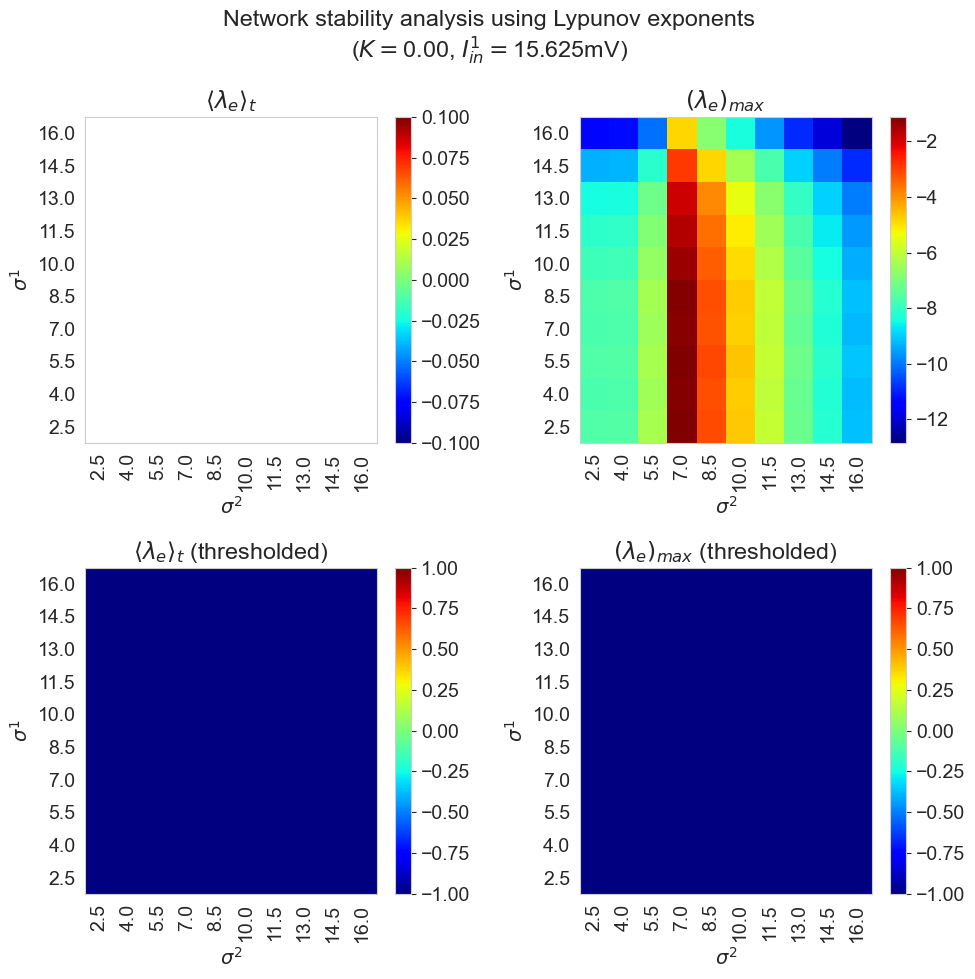

In [18]:
# lyapunov exponenet response maps sigma_1 vs. sigma_2

if_plot_lyap = True
if_save_lyap = False
mask_thresh = 0.05

file_name = f"lyap_K_{params['K']:.2f}_ie_{params['i_e1']:.3f}"

if os.path.isfile(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')):
    print(f"file found at {os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')} --> loading file...")
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'rb') as f:
        lyap_mats = pickle.load(f)

else:
    lyap_mats = {
                    'n1_mean': np.zeros((sig1_steps, sig2_steps)),
                    'n2_mean': np.zeros((sig1_steps, sig2_steps)),
                    'n1_max': np.zeros((sig1_steps, sig2_steps)),
                    'n2_max': np.zeros((sig1_steps, sig2_steps))
                }

    for s1, sigma_1 in enumerate(eval_sigma_1):
        params['sig_e1'] = params['sig_i1'] = sigma_1
        tic = time.time()
        for s2, sigma_2 in enumerate(eval_sigma_2):
            params['sig_e2'] = params['sig_i2'] = sigma_2
    
            u = np.zeros((n_trials, 4, T))
            u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
            
            lyapunov_1 = np.zeros((T - t_start - 1))
            for k in range(n_trials):
                diff_1 = np.abs(np.diff(u[k, 0, t_start:]))
                lyapunov_1 += 1 / n_trials * np.log(diff_1)
            
            lyapunov_2 = np.zeros((T - t_start - 1))
            for k in range(n_trials):
                diff_2 = np.abs(np.diff(u[k, 2, t_start:]))
                lyapunov_2 += 1 / n_trials * np.log(diff_2)
    
            lyap_mats['n1_mean'][s1, s2] = np.mean(lyapunov_1)
            lyap_mats['n2_mean'][s1, s2] = np.mean(lyapunov_2)
            lyap_mats['n1_max'][s1, s2] = lyapunov_1.max()
            lyap_mats['n2_max'][s1, s2] = lyapunov_2.max()
        toc = time.time()
        print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'wb') as f:
        pickle.dump(lyap_mats, f)

# plotting

para_str = r"($K = $" + f"{params['K']:.2f}, " + r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV)"
plot_opts_dict = {'fig_size': (10, 10), 'ylabel': r'$\sigma^1$', 'xlabel': r'$\sigma^2$', 'para_str': para_str} 
    
if if_plot_lyap:
    plot_lyapunov_nodes(
                        var1_arr = eval_sigma_1,
                        var2_arr = eval_sigma_2,
                        plot_opts = plot_opts_dict, 
                        save_dir = save_dir, 
                        if_save = if_save_lyap, 
                        image_name = file_name + '_node.png',
                        **lyap_mats
                        )

thresh_mean, thresh_max = plot_lyapunov_network(
                                                  var1_arr = eval_sigma_1, 
                                                  var2_arr = eval_sigma_2, 
                                                  mask_thresh = mask_thresh, 
                                                  if_plot = if_plot_lyap,
                                                  plot_opts = plot_opts_dict, 
                                                  save_dir = save_dir, 
                                                  if_save = if_save_lyap, 
                                                  image_name = file_name + '_net.png', 
                                                  **lyap_mats
                                                  )

thresh_node1_mean = lyapunov_threshold(lyap_mats['n1_mean'], mask_tau=mask_thresh)

finishing sigma value --> Execution time: 17.826s


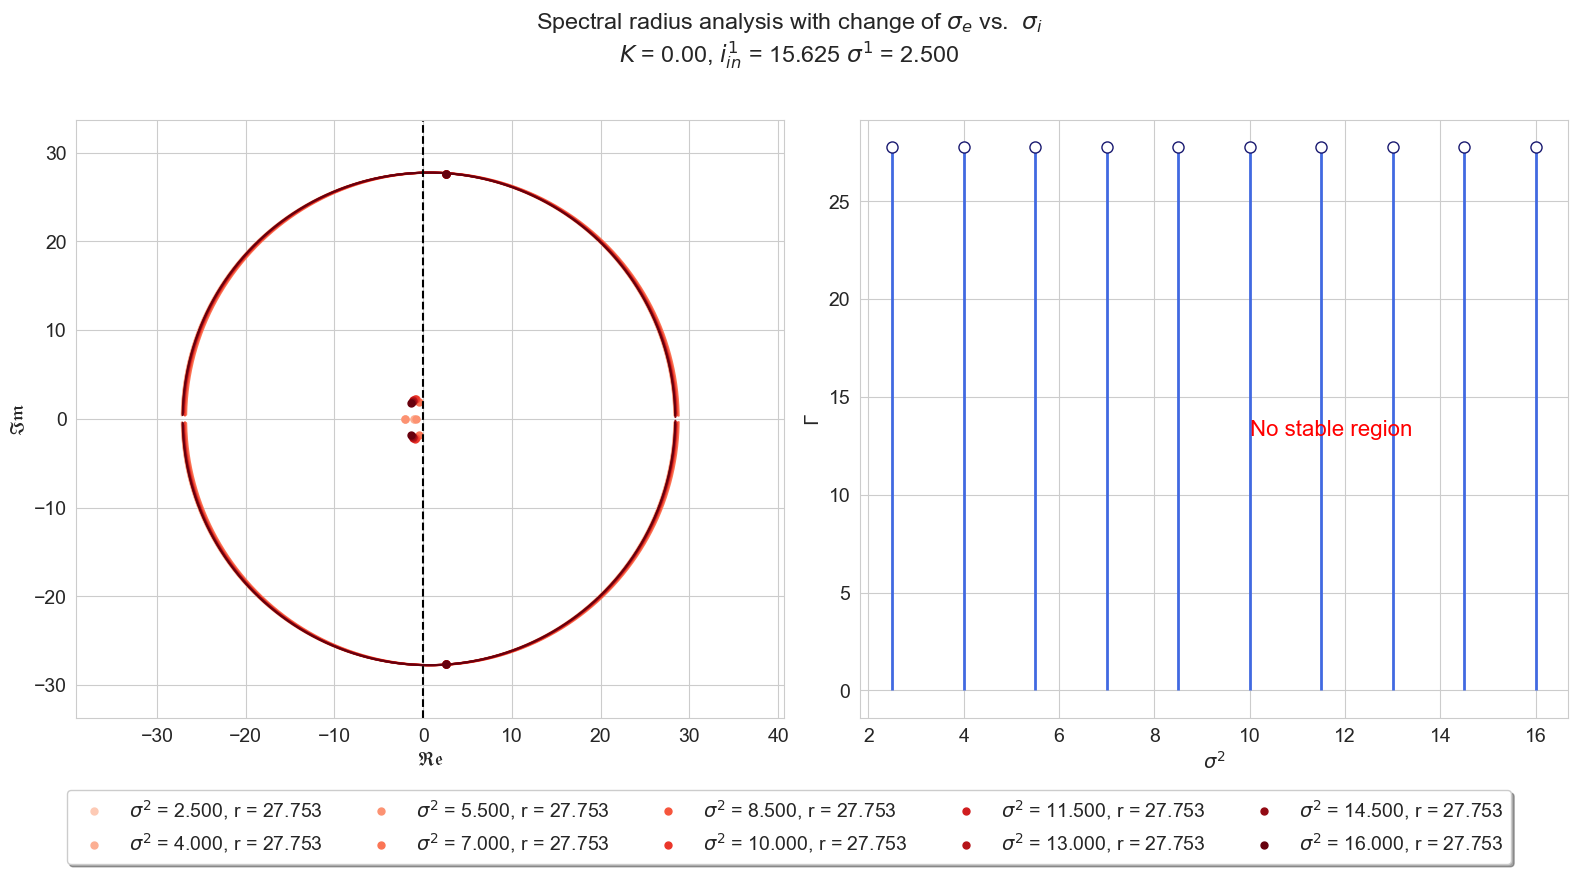

finishing sigma value --> Execution time: 15.933s


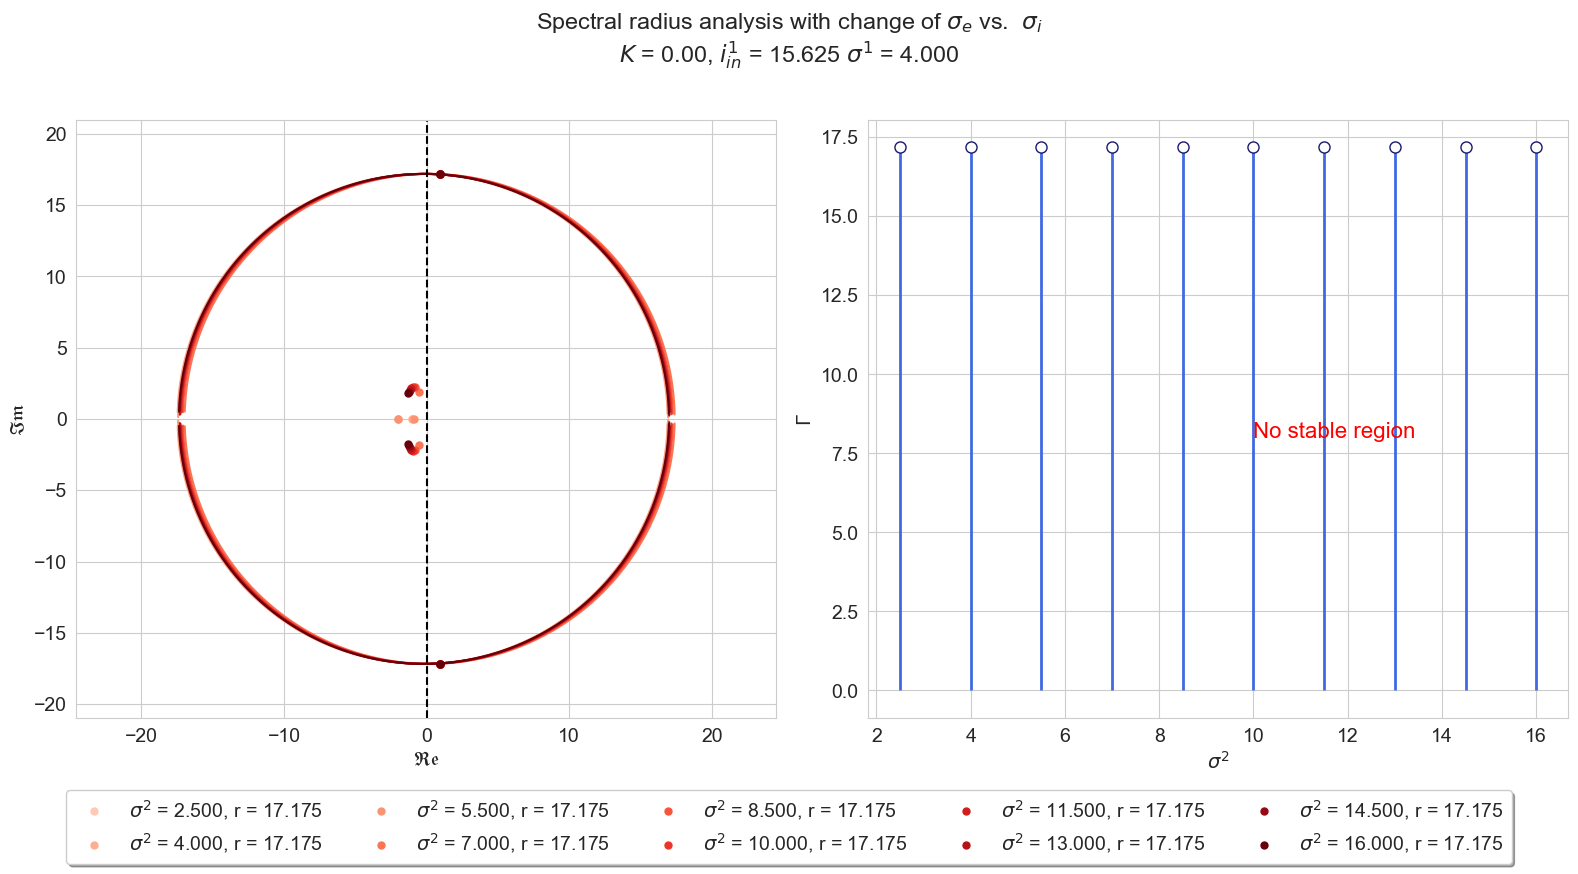

finishing sigma value --> Execution time: 14.494s


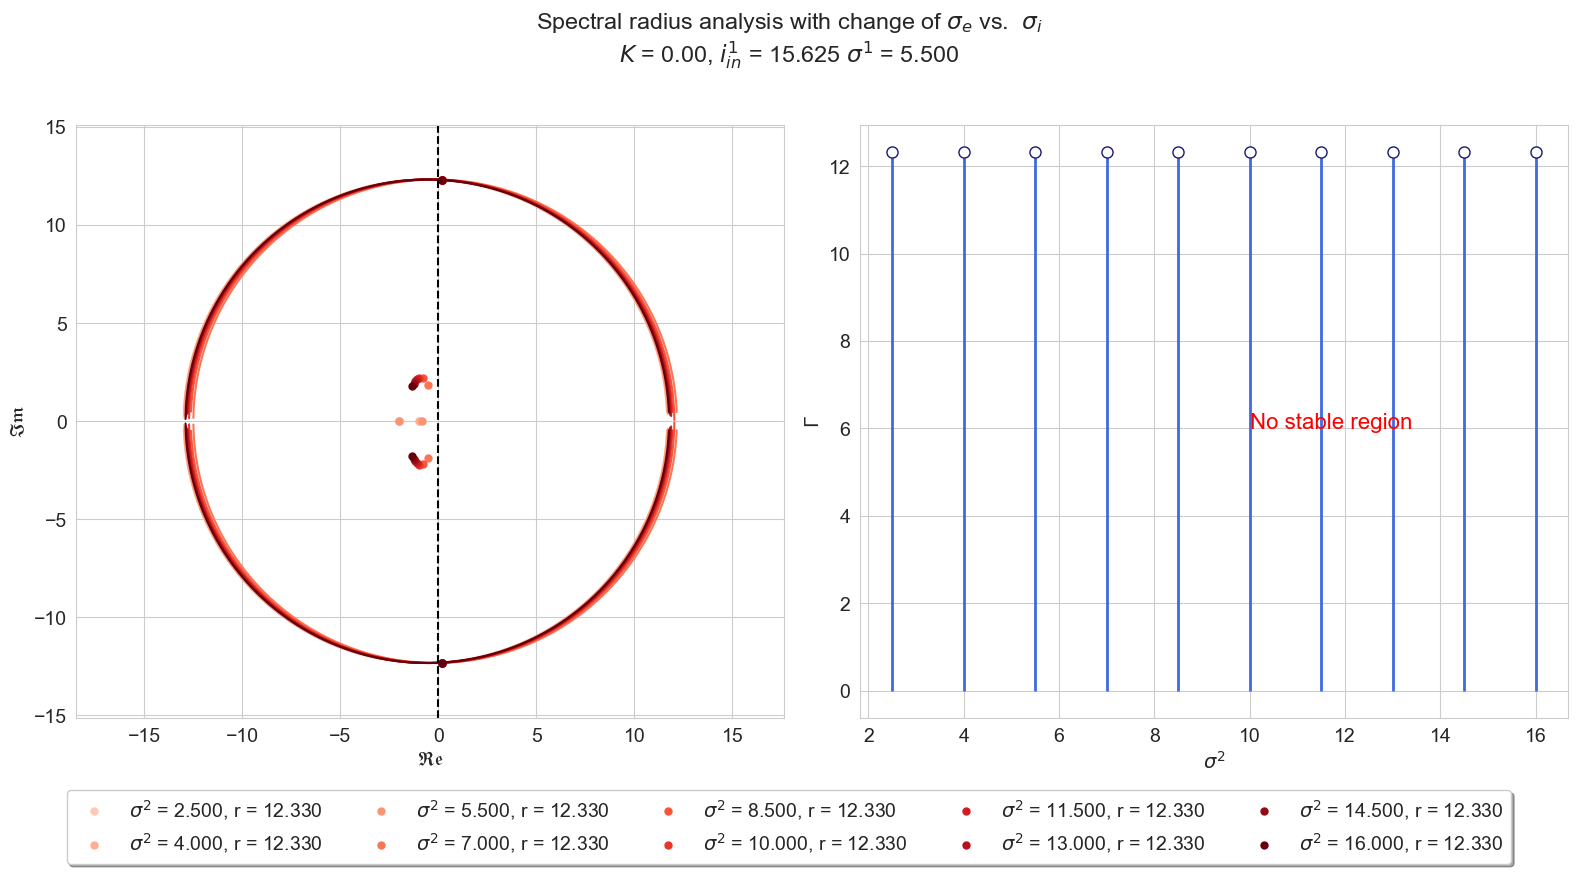

finishing sigma value --> Execution time: 12.824s


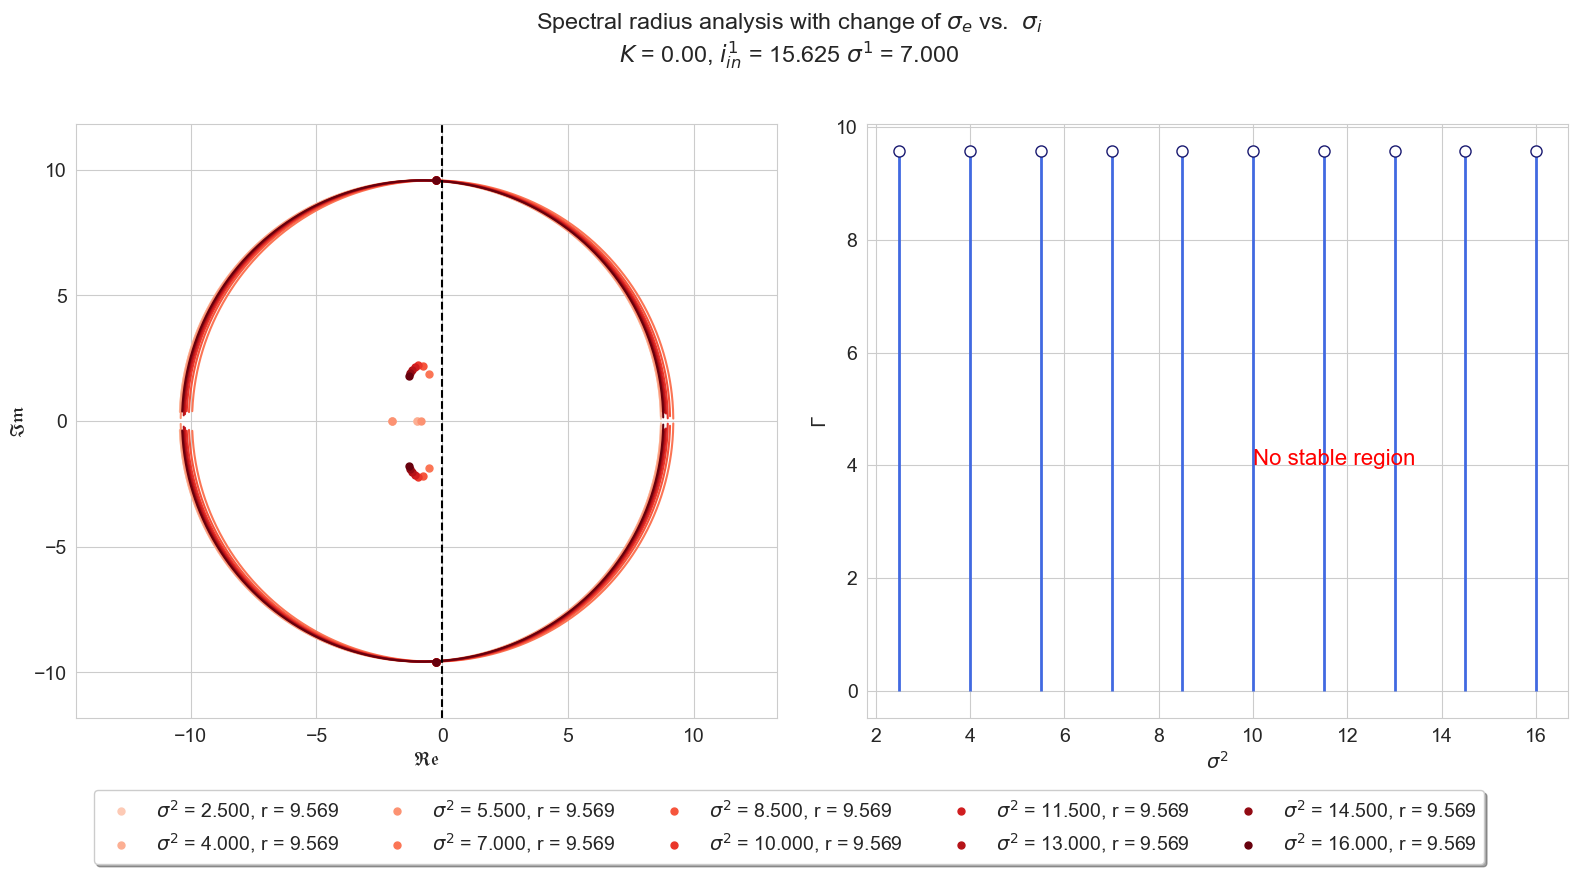

finishing sigma value --> Execution time: 11.963s


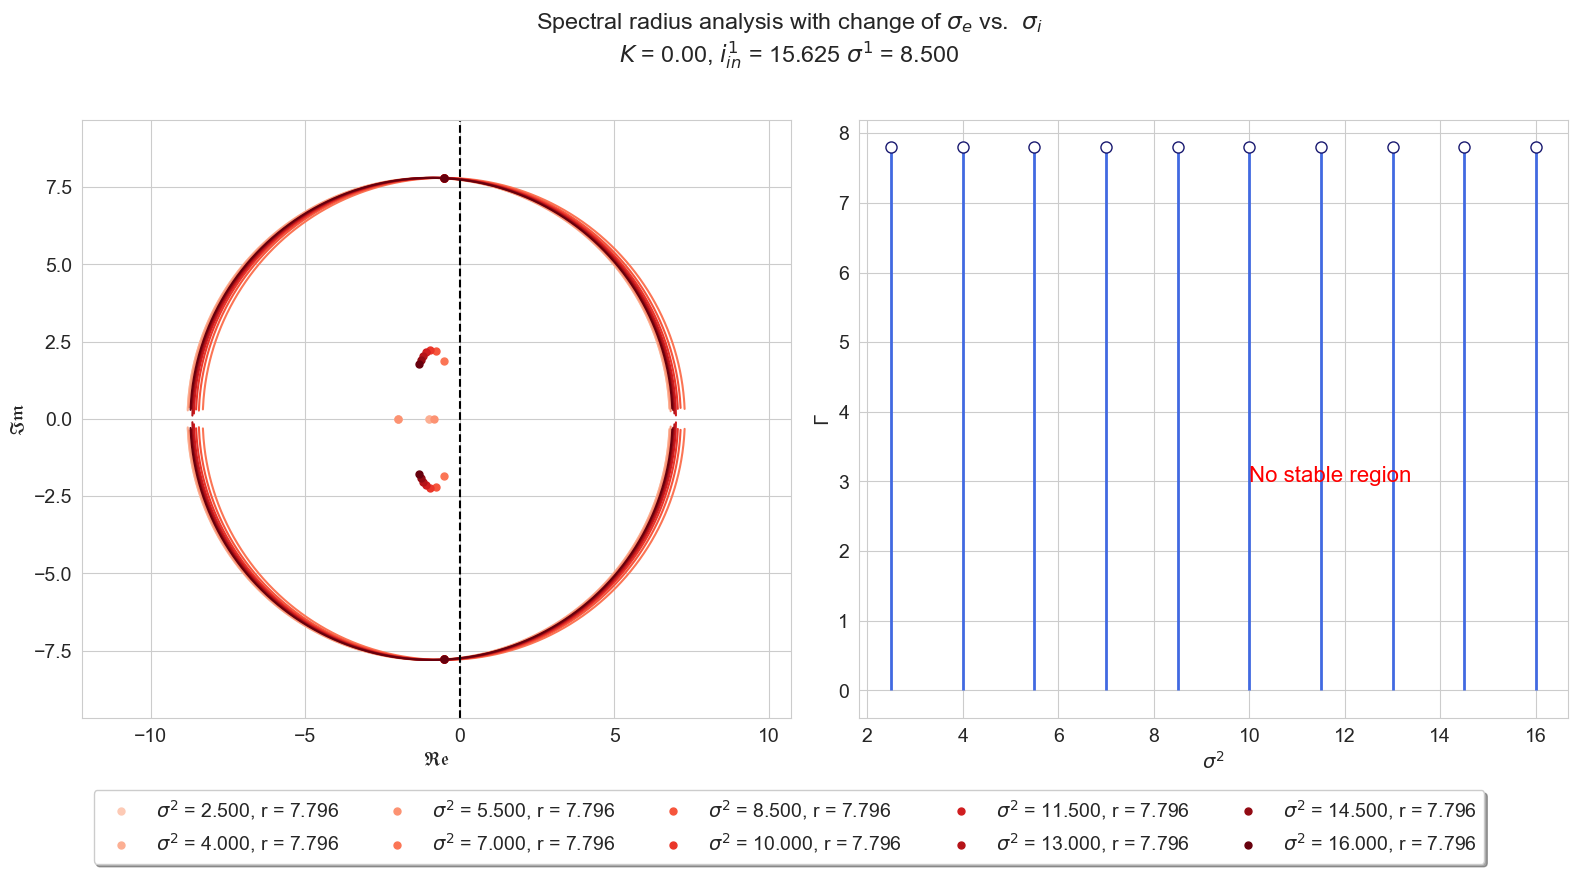

finishing sigma value --> Execution time: 11.777s


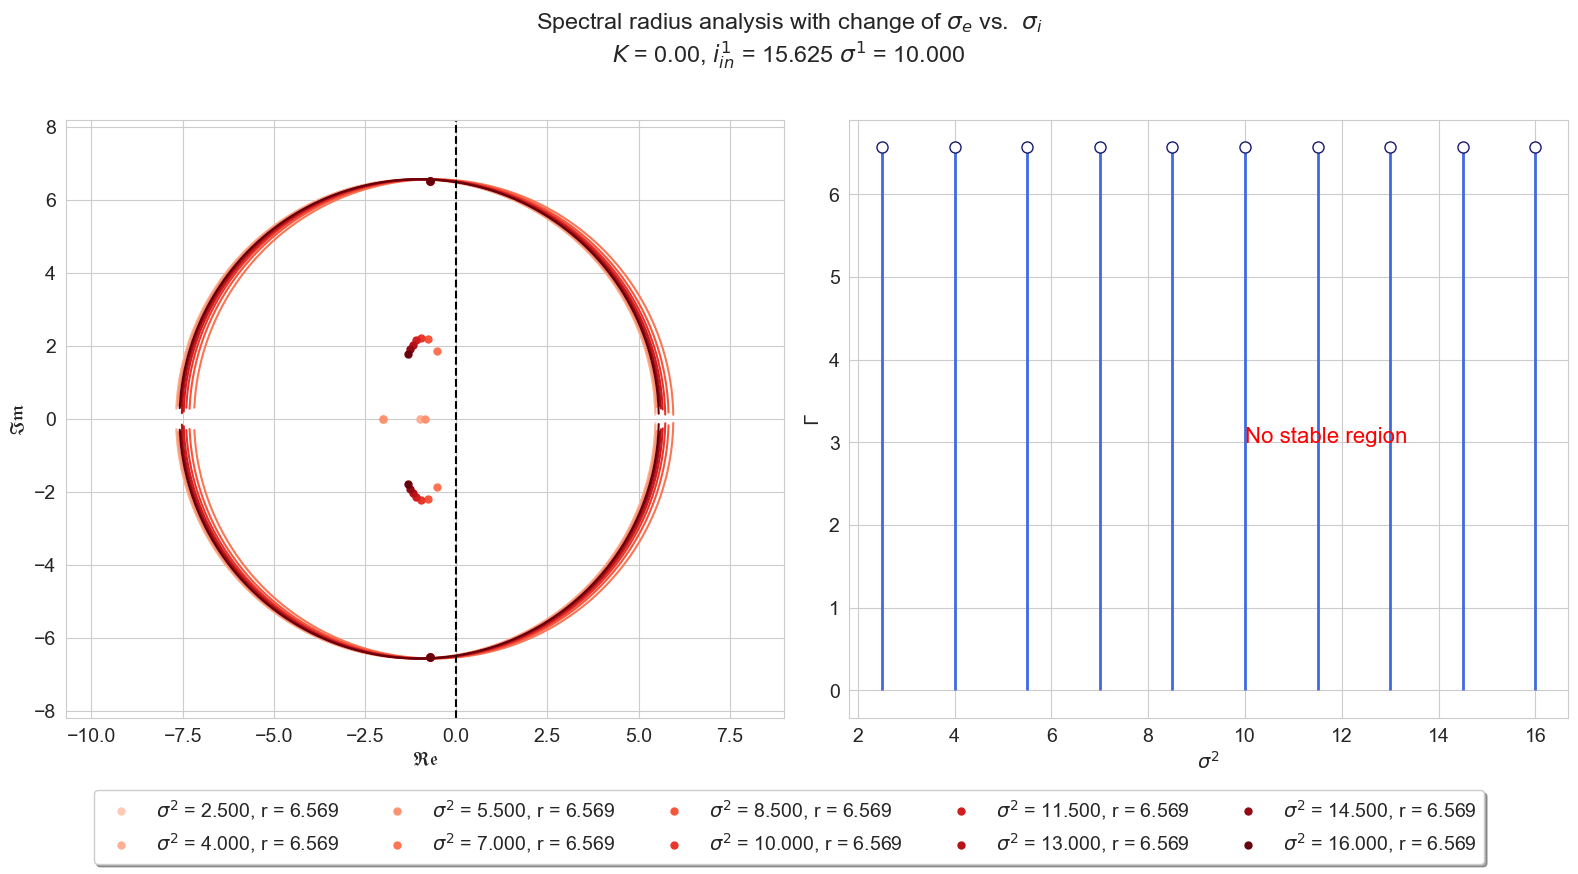

finishing sigma value --> Execution time: 12.799s


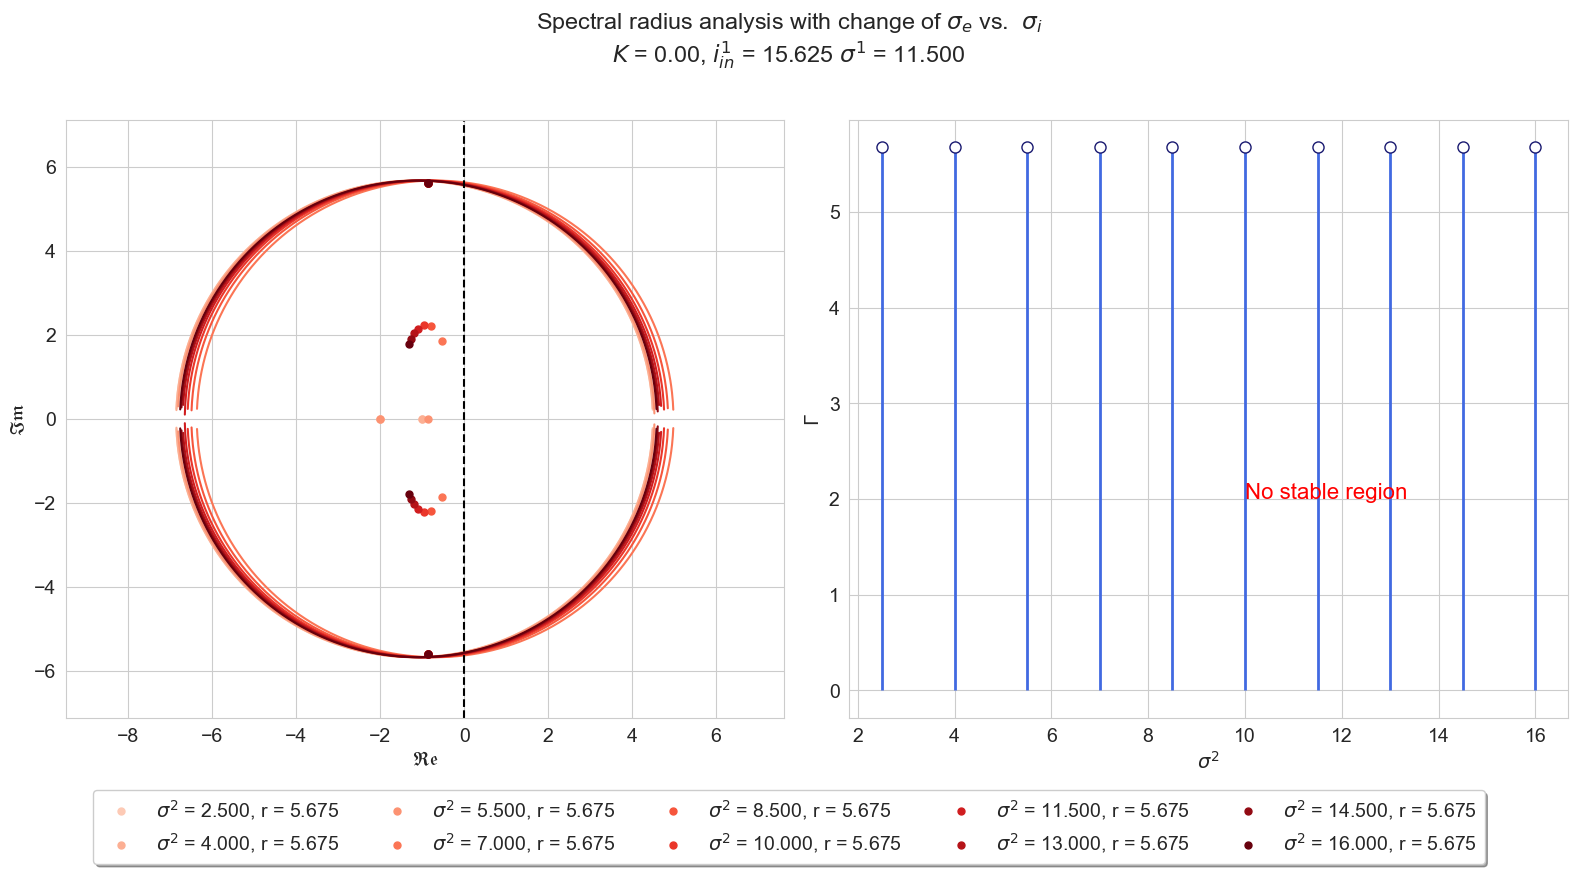

finishing sigma value --> Execution time: 11.242s


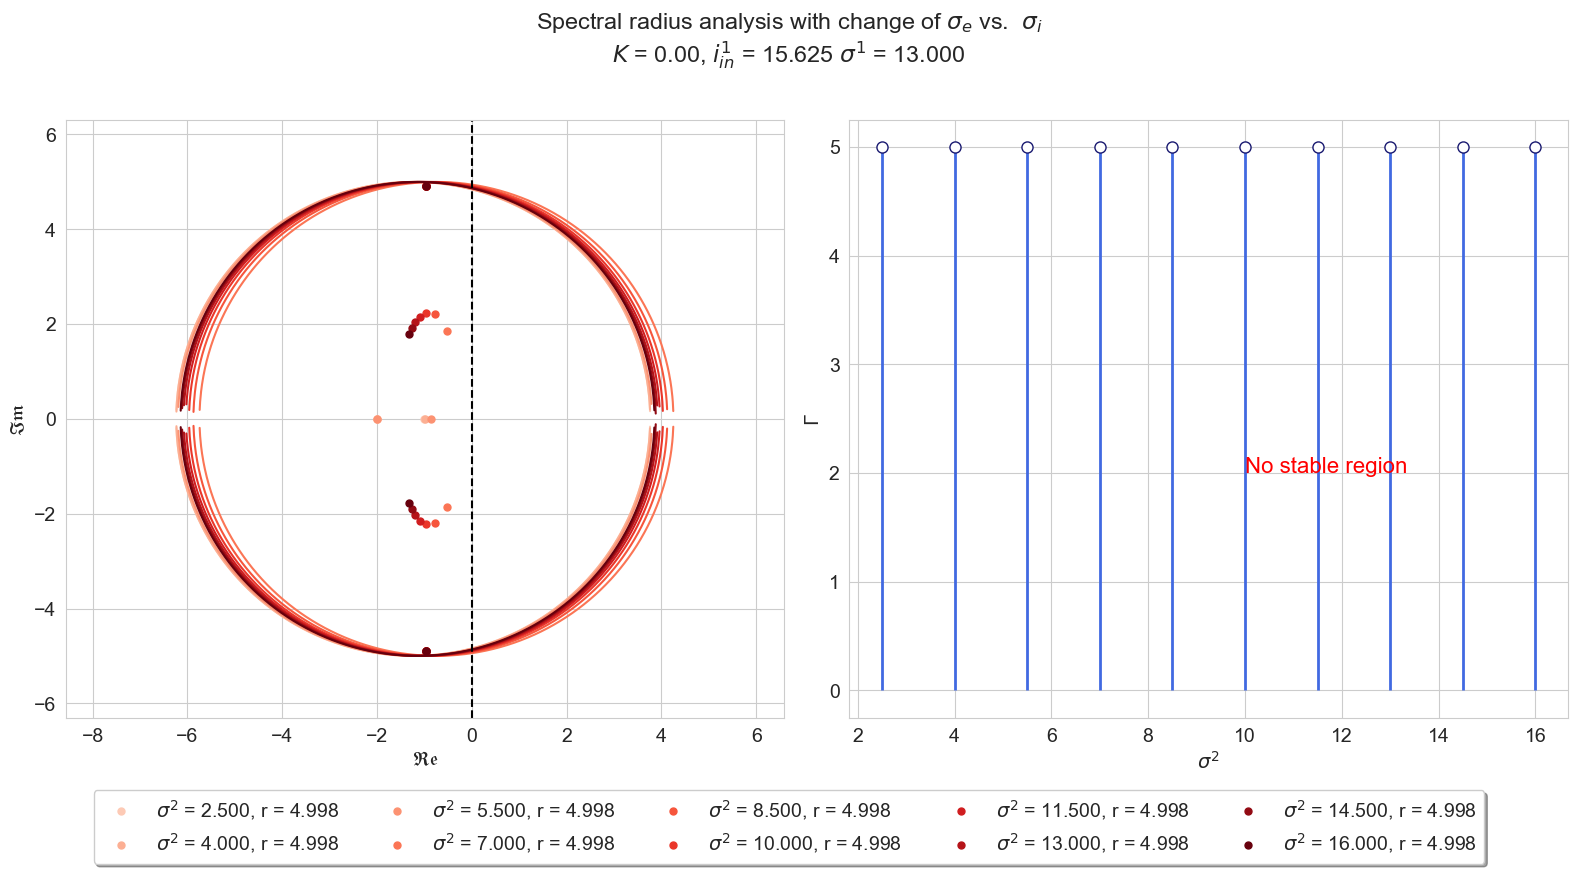

finishing sigma value --> Execution time: 10.868s


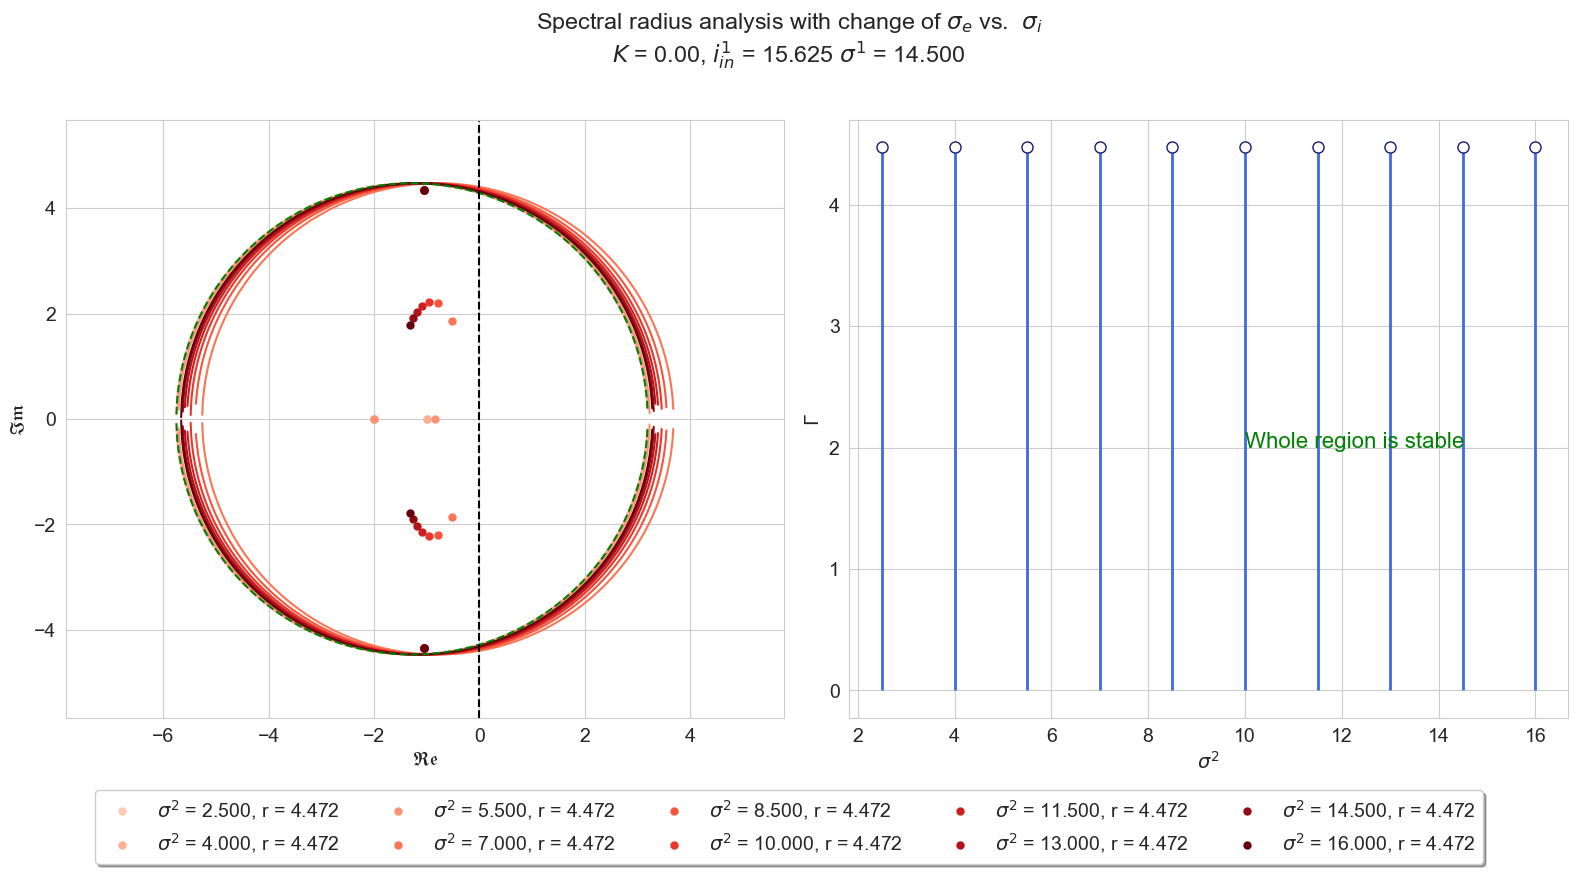

finishing sigma value --> Execution time: 10.769s


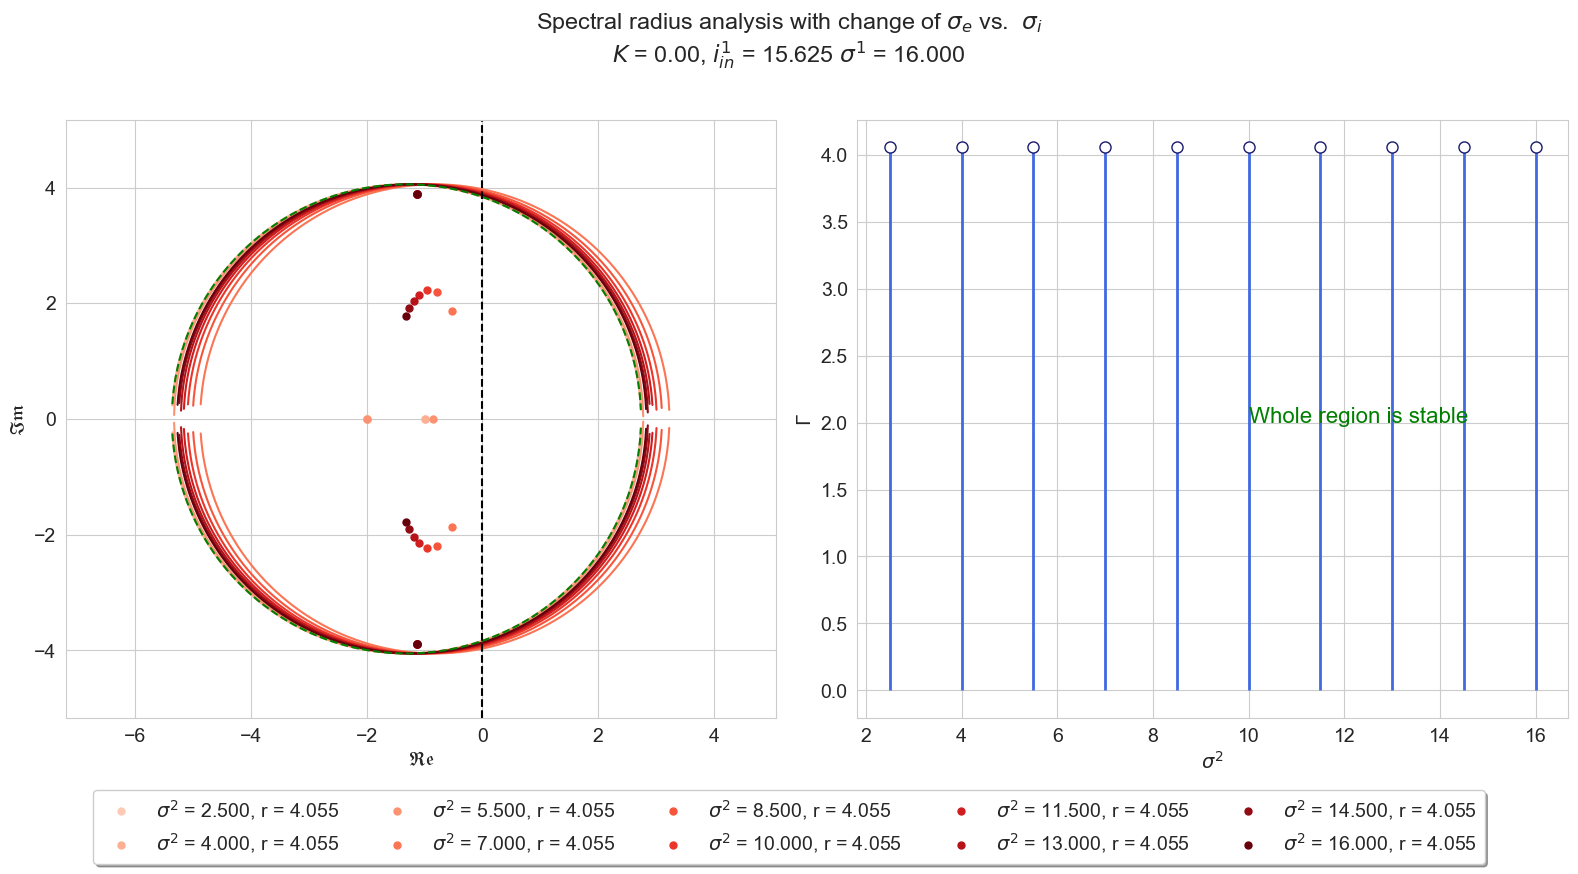

In [73]:
# spectral radius analysis and its link to stability with lyapunov exponent
spec_rad = np.zeros((sig1_steps, sig2_steps))
spec_cent = np.zeros((sig1_steps, sig2_steps))

x = np.arange(-50, 50, 0.01)

for s1, sig_1 in enumerate(eval_sigma_1):
    params['sig_e1'] = params['sig_i1'] = sig_1
    rad_stable = []; rad_unstable = []
    cent_stable = []; cent_unstable = []
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))
        
    rad_colors = plt.get_cmap('Reds')
    rad_colors = iter(rad_colors(np.linspace(0.2, 1, sig2_steps)))
    
    eig_val_colors = plt.get_cmap('Reds')
    eig_val_colors = iter(eig_val_colors(np.linspace(0.2, 1, sig2_steps)))
    
    file_str = f"K_{params['K']:.3f}_ie1_{params['i_e1']:.3f}_sige_{params['sig_e1']:.3f}"

    tic = time.time()
    for s2, sig_2 in enumerate(eval_sigma_2):
        params['sig_e2'] = params['sig_i2'] = sig_2
        
        while True:
            fp_dict = calc_fixed_points(
                    minval=minval,
                    maxval=maxval,
                    grid_res=1000,
                    n_init=100,
                    cal_grad=False,
                    **params
                )

            if fp_dict['n_fps'] != 0:
                break
        
        eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
        rad_, center_, real_, img_ = spectrum_analysis(eig_dict['eigvals'])
        spec_rad[s1, s2] = rad_
        spec_cent[s1, s2] = center_
        
        lyap_val = thresh_node1_mean[s1, s2]
        
        if lyap_val == 1 or lyap_val == 0:
            rad_unstable.append(rad_)
            cent_unstable.append(center_)
        
        elif lyap_val == -1:
            rad_stable.append(rad_)
            cent_stable.append(center_)
        
        color_rads = next(rad_colors)
        color_eig = next(eig_val_colors)
        
        para_str =  r'$K$ = ' + f"{params['K']:.2f}, " + r'$i_{in}^1$ = ' + f"{params['i_e1']:.3f} " + r'$\sigma^1$ = ' + f"{params['sig_e1']:.3f}"
        ax[0].plot(real_, img_, '.', markersize=10, color=color_eig, label=r"$\sigma^2$" + f' = {sig_2:.3f}, r = {rad_:.3f}')
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        
    toc = time.time()
    print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    if (len(rad_unstable) != 0) and (len(rad_stable) != 0):
        cent_unstable = cent_unstable[np.argmin(np.array(rad_unstable))]
        cent_stable = cent_stable[np.argmax(np.array(rad_stable))]
        
        rad_unstable = min(rad_unstable)
        rad_stable = max(rad_stable)
        
        rad_ = (rad_unstable + rad_stable) / 2
        center_ = (cent_unstable + cent_stable) / 2
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')

    elif (len(rad_unstable) == 0) and (len(rad_stable) != 0):
        rad_ = max(spec_rad[s1, :])
        center_ = spec_cent[s1, np.argmax(spec_rad[s1, :])]
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
    
    ax[0].axvline(x=0, color='k', linestyle='--')
    ax[0].axis('equal')
    ax[0].grid(True)
    ax[0].set_xlabel(r'$\mathfrak{Re}$');
    ax[0].set_ylabel(r'$\mathfrak{Im}$')
        
    # sns.distplot(spec_rad[s1, :], kde=True, bins=20, hist=False, ax=ax[1])
    # _, _, bars = ax[1].hist(spec_rad[s1, :], bins = 100, color='red',alpha=0.25)
    markerline, stemlines, baseline = ax[1].stem(eval_sigma_2, spec_rad[s1, :])
    plt.setp(stemlines, linewidth=2, color='royalblue')
    plt.setp(baseline, visible=False)
    plt.setp(markerline, 'markerfacecolor', 'white', 'markeredgecolor', 'midnightblue', markersize=8)
    ax[1].set_xlabel(r'$\sigma^2$'); ax[1].set_ylabel(r'$\Gamma$')
    
    if rad_unstable and rad_stable:
        ax[1].axhline(y=rad_unstable, color='k', linestyle='--')
        ax[1].text(x=eval_sigma_2[sig2_steps // 2], y=(rad_unstable + max(spec_rad[s1, :])) / 2, s='Unstable', color='red',
                   fontsize=16, animated=True)
        ax[1].text(x=eval_sigma_2[sig2_steps // 2], y=rad_ // 2, s='Stable', color='green', fontsize=16,
                   animated=True)
        ax[1].text(x=eval_sigma_2[sig2_steps // 2], y = rad_unstable, s = f'{rad_unstable:.3f}', color='k', fontsize=16)

    elif (len(rad_unstable) == 0) and (len(rad_stable) != 0):
        ax[1].text(x=eval_sigma_2[sig2_steps // 2], y=max(spec_rad[s1, :]) // 2, s='Whole region is stable',
                   color='green', fontsize=16, animated=True)

    else:
        ax[1].text(x=eval_sigma_2[sig2_steps // 2], y=max(spec_rad[s1, :]) // 2, s='No stable region', color='red',
                   fontsize=16, animated=True)
    
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.10), ncols=5, fancybox=True, shadow=True)
    plt.suptitle('Spectral radius analysis with change of ' + r"$\sigma_e$ vs.  $\sigma_i$" + '\n' + para_str + '\n')
    plt.tight_layout()

    plt.savefig(os.path.join(save_dir, scene_sub_dir, file_str + '.png'), dpi=600, bbox_inches='tight')
    plt.show()

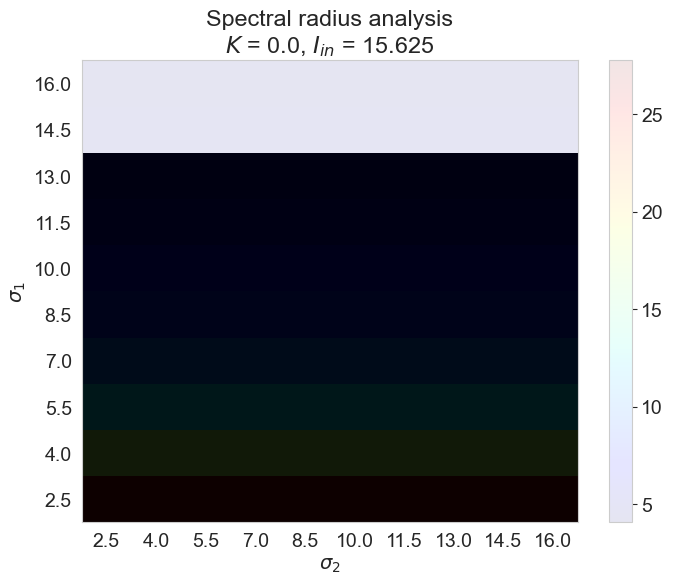

In [74]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(eval_sigma_1, eval_sigma_2, thresh_node1_mean, cmap='Greys', alpha=1.0)
plt.pcolormesh(eval_sigma_1, eval_sigma_2, spec_rad, cmap='jet', alpha=0.1)
plt.xlabel(r'$\sigma_2$'); plt.ylabel(r'$\sigma_1$')
plt.xticks(eval_sigma_2); plt.yticks(eval_sigma_1)
plt.colorbar()
plt.title("Spectral radius analysis\n" + r"$K$ = " + f"{params['K']}, " + r"$I_{in}$ = " + f"{params['i_e1']}")
plt.savefig(os.path.join(save_dir, scene_sub_dir, f"K_{params['K']}_ie_{params['i_e1']}_resmap.png"))
plt.show()

In [67]:
# ts analysis and trajectories
params['sig_e2'] = params['sig_i2'] = 2.5
params['sig_e1'] = params['sig_i1'] = 14

u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

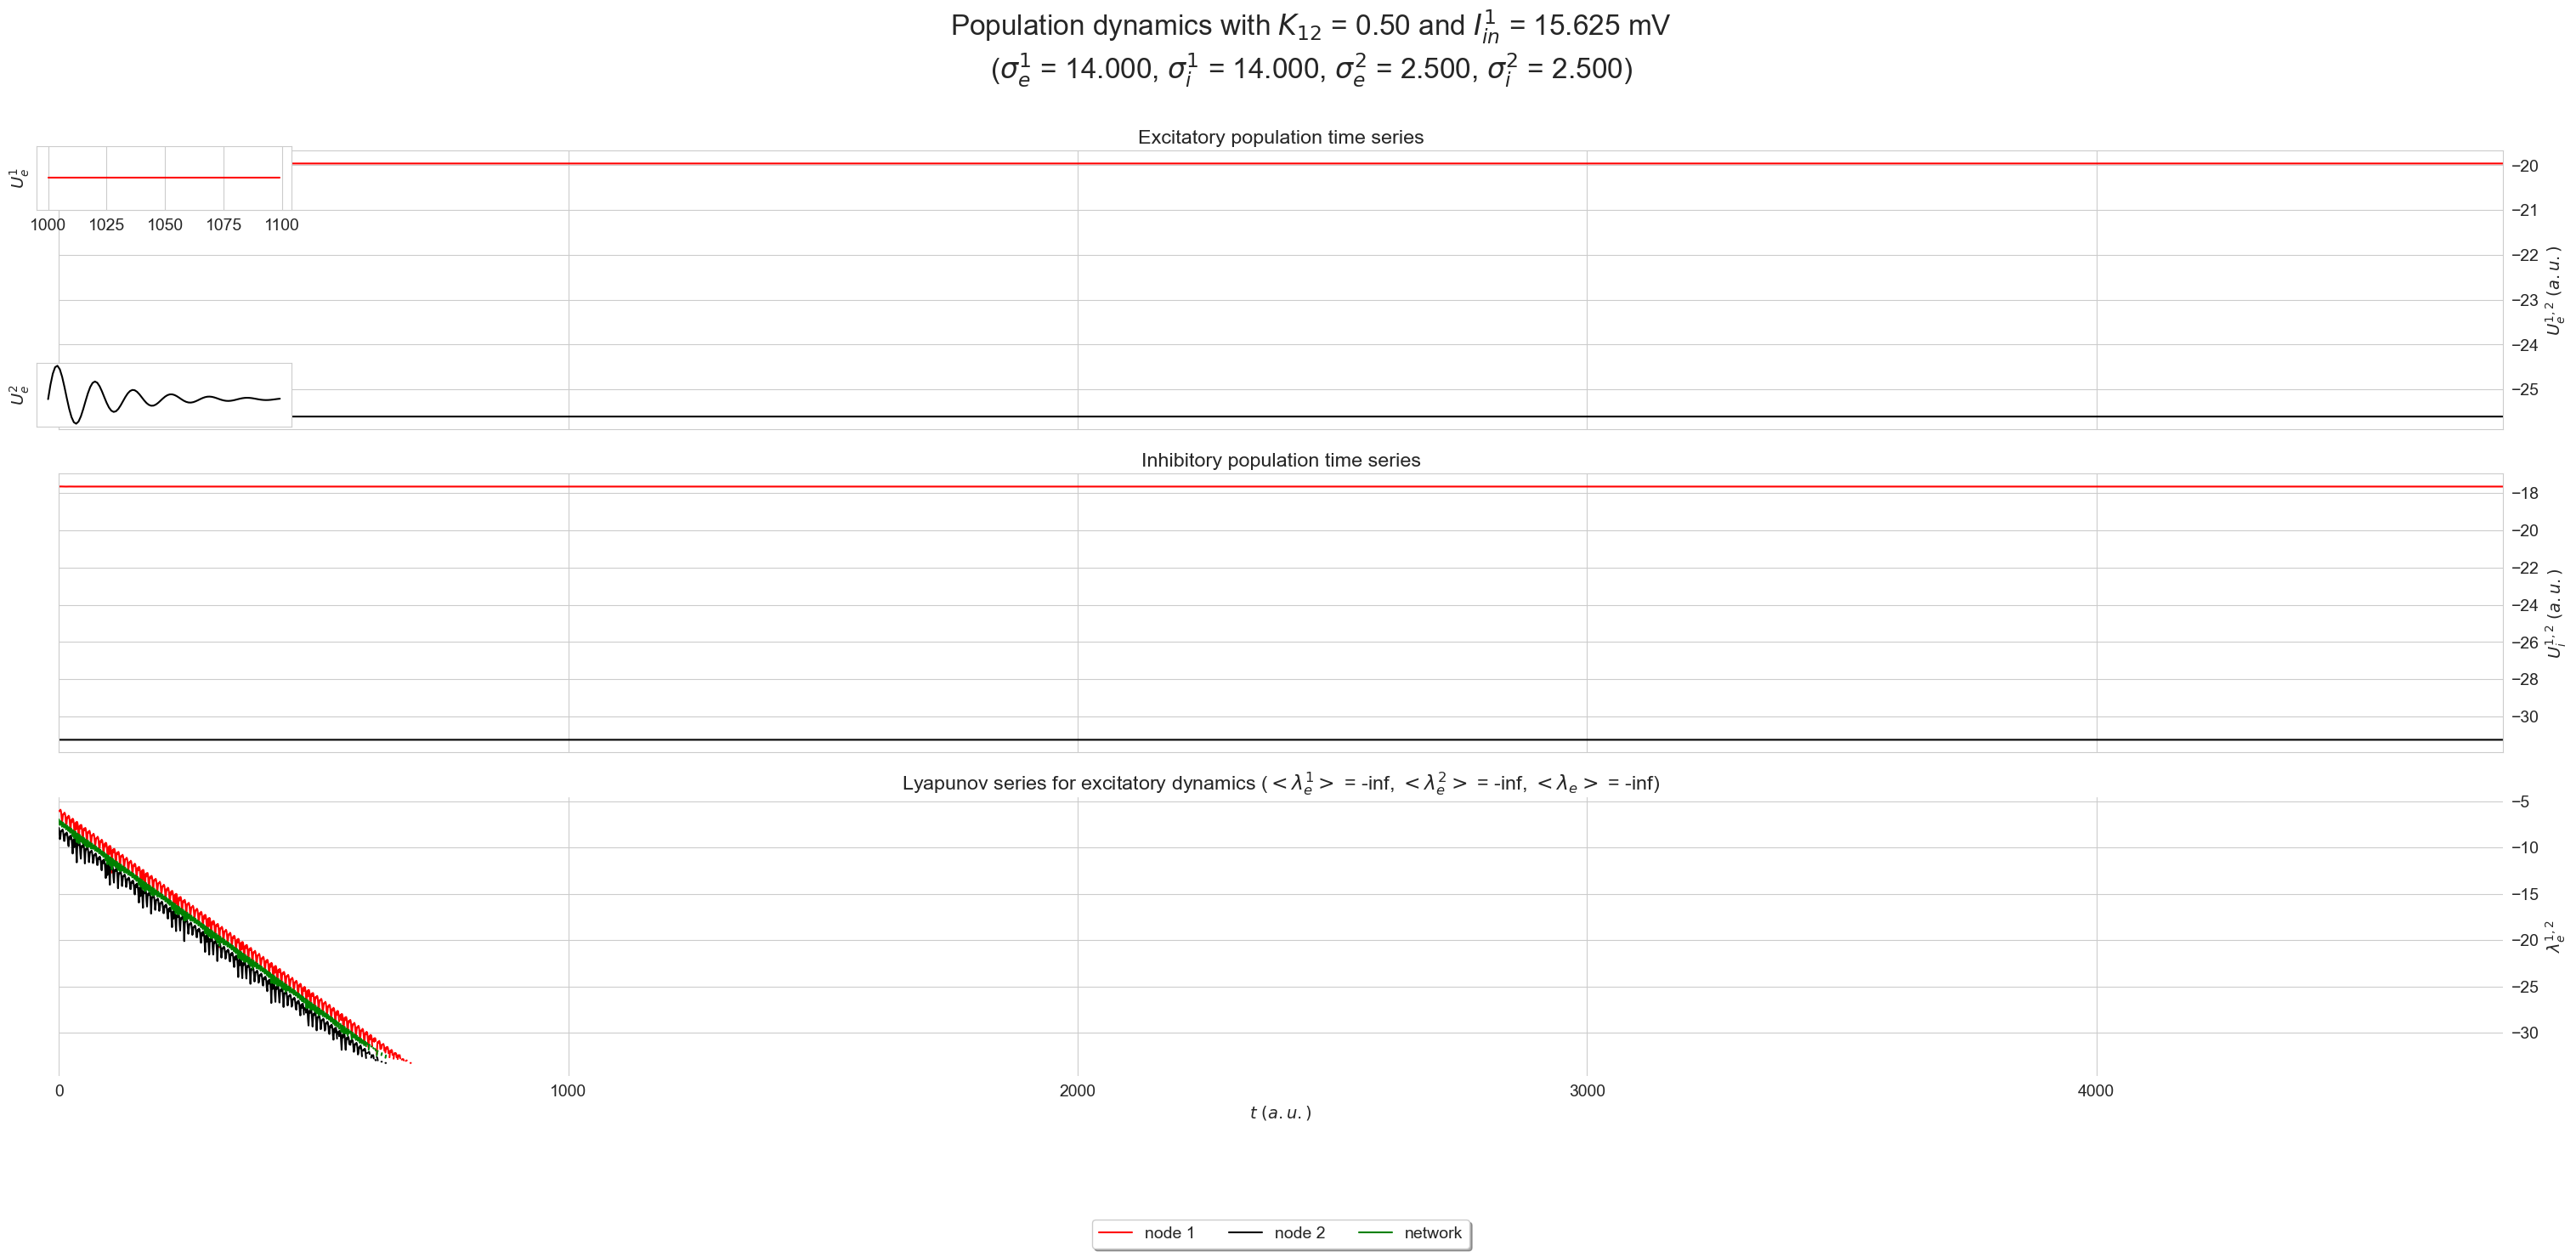

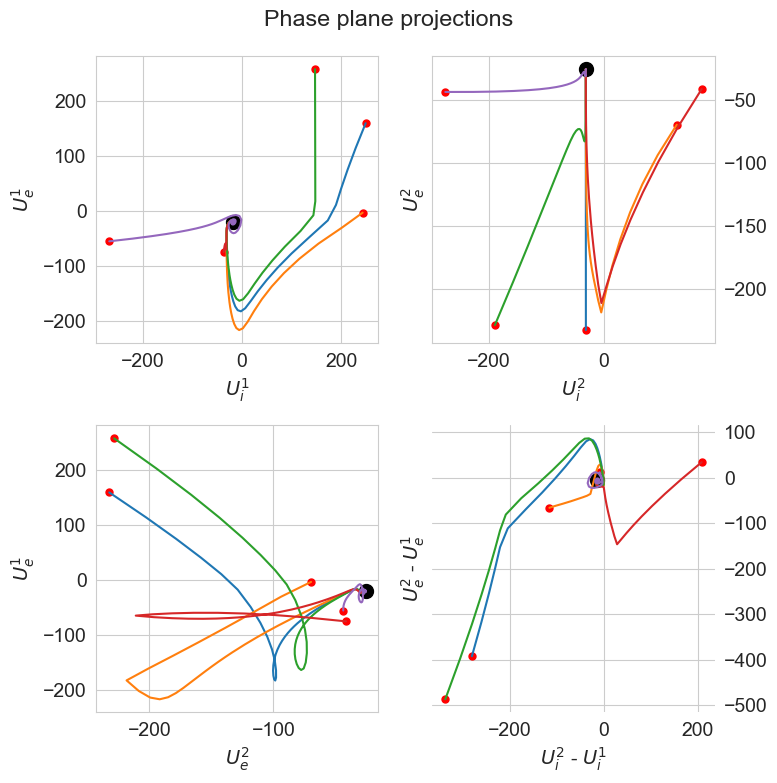

In [68]:
avg_lyap = plot_ts(
    u=u,
    t_arr=time_,
    t1=t_start,
    t2=T,
    fig_size=(30, 15),
    if_zoom=True,
    zoom_t=[1000, 1100, 0, 100],
    if_save=False,
    save_dir=save_dir,
    image_name=f"ts_sige_{params['sig_e1']:.3f}_sigi_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}",
    **params
)

fp_dict = calc_fixed_points(
    minval=minval,
    maxval=maxval,
    grid_res=1000,
    n_init=100,
    cal_grad=False,
    **params
)

if fp_dict['n_fps'] == 0:
    u_ = np.zeros((1, 4, T))
    u_ = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

    fe1 = np.max(u_[0, 0, t_start:])
    fi1 = np.max(u_[0, 1, t_start:])
    fe2 = np.max(u_[0, 2, t_start:])
    fi2 = np.max(u_[0, 3, t_start:])

    fp_dict['fps'] = np.array([[fe1, fi1, fe2, fi2]]).T
    fp_dict['n_fps'] = 1

    del u_, fe1, fe2, fi1, fi2

eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
plot_trajectory(u, [x0_, x1_, x2_, x3_], (8, 8), **fp_dict)

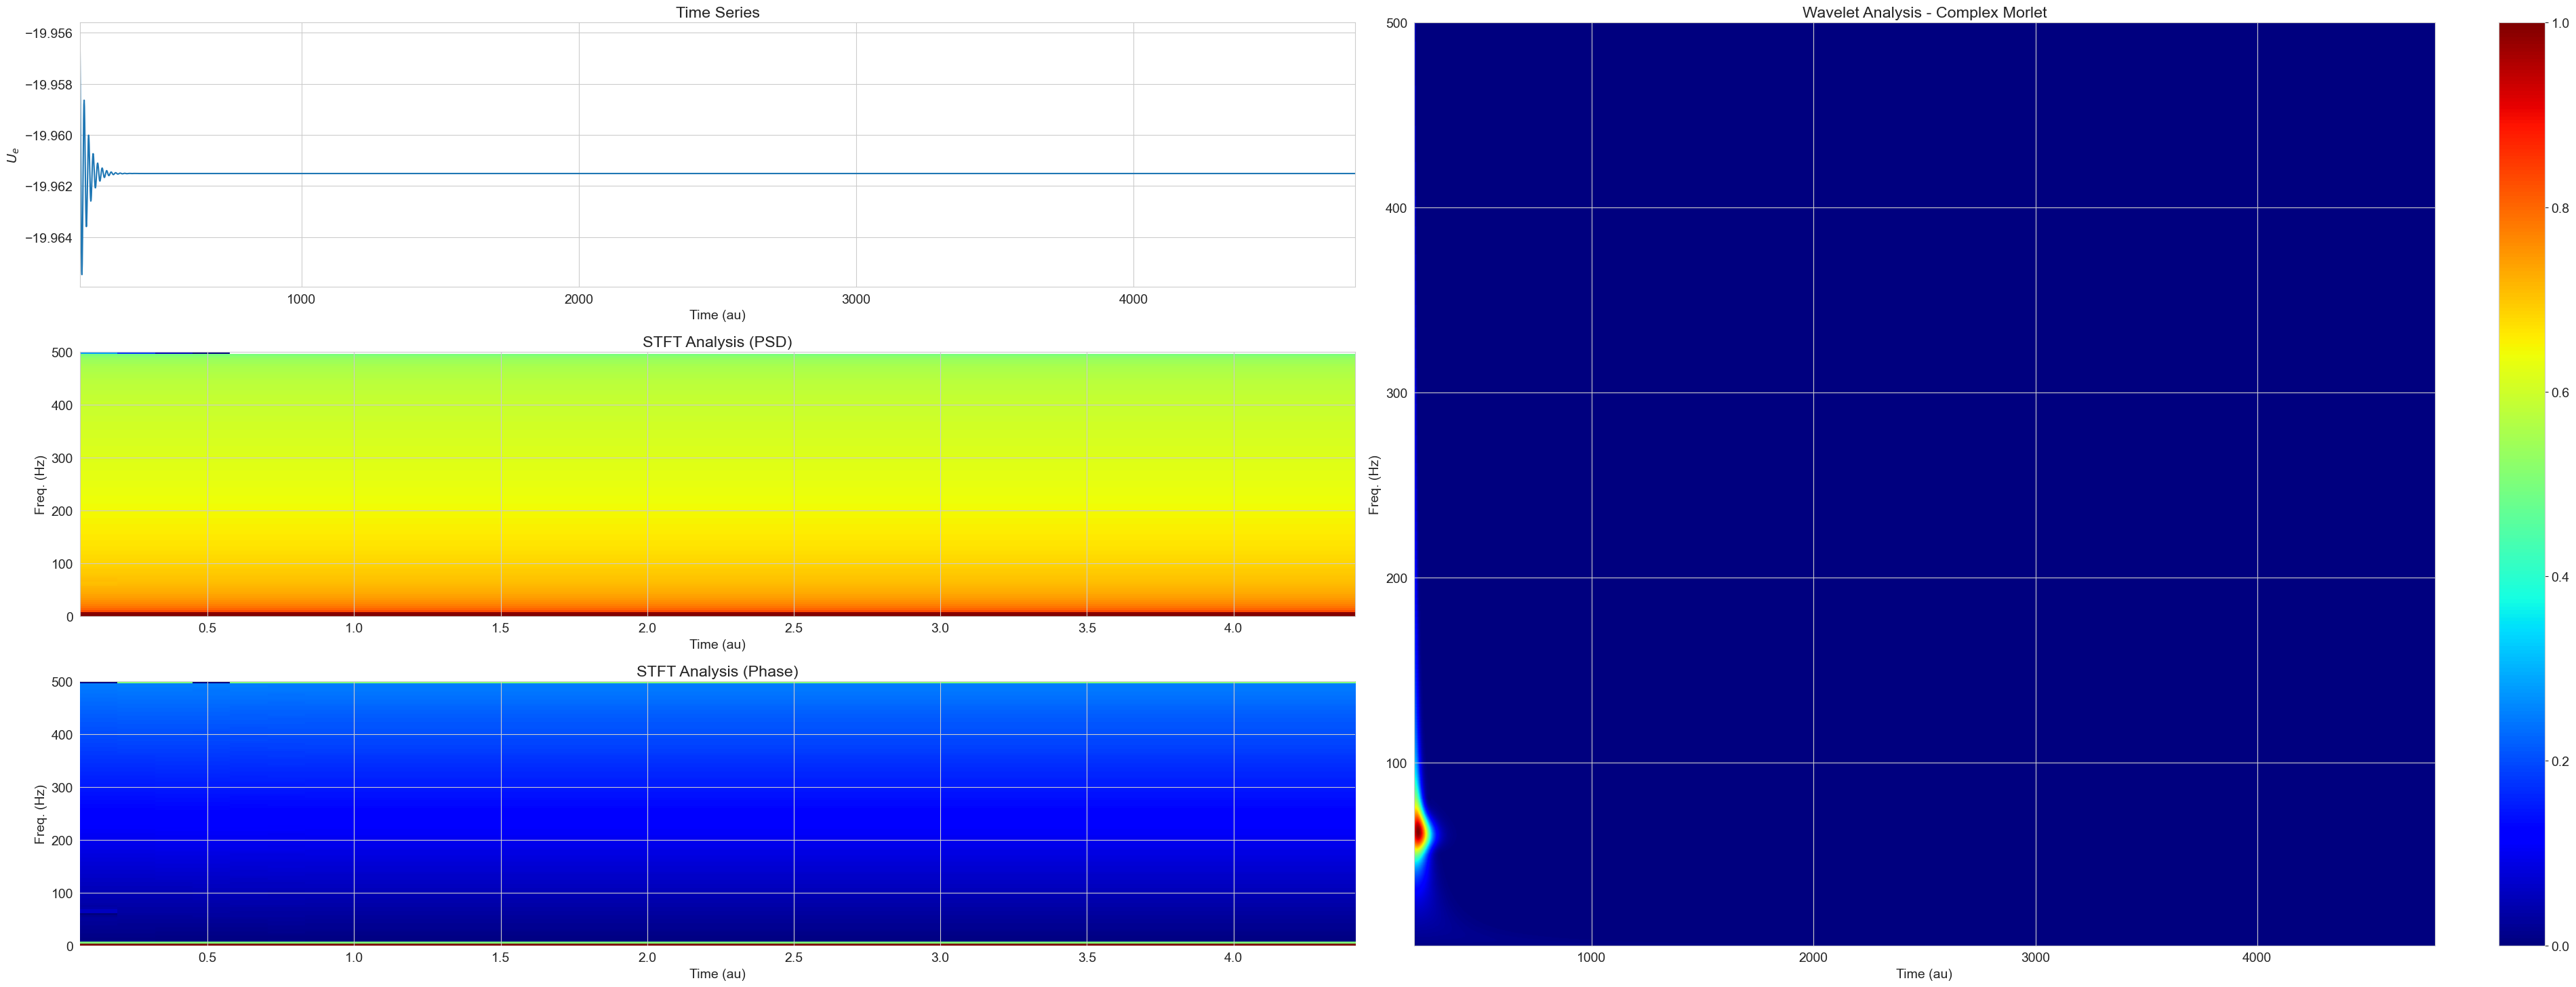

In [69]:
# wavelet analysis
plot_bool = True
ue1 = np.mean(u[:, 0, :], axis=0)
ui1 = np.mean(u[:, 1, :], axis=0)
ue2 = np.mean(u[:, 2, :], axis=0)
ui2 = np.mean(u[:, 3, :], axis=0)

freq_arr, wt_matr = wavelet_analysis(
                                     signals = ue1, 
                                     time_arr=time_, 
                                     t1 = t_start, 
                                     t2 = T - t_start, 
                                     center_freq = 12., 
                                     fs = 1000, 
                                     fig_size = (40, 15),
                                     save_dir = os.path.join(save_dir, scene_sub_dir),
                                     if_plot = plot_bool,
                                     if_save = False,
                                     img_name = f"ue1_spectral_sige_{params['sig_e1']:.3f}_sigi_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}"
                                     )

In [19]:
# saving to separate sub-dir
scene_sub_dir = 's_04'
os.makedirs(os.path.join(save_dir, scene_sub_dir), exist_ok=True)

In [20]:
# setting constant values
params['K'] = 0.2
params['i_e1'] = 0.25 / params['gamma']
params['sig_e1'] = params['sig_i1'] = 2.5

# setting variables
sige_min = 2.5; sige_max = 17.5; sige_steps = 10
sigi_min = 2.5; sigi_max = 17.5; sigi_steps = 10

eval_sigma_e = sige_min + np.arange(0, sige_steps) / sige_steps * (sige_max - sige_min)
eval_sigma_i = sigi_min + np.arange(0, sigi_steps) / sigi_steps * (sigi_max - sigi_min)

In [ ]:
# lyapunov exponenet response maps sigma_e vs. sigma_i

if_plot_lyap = False
if_save_lyap = False
mask_thresh = 0.05

file_name = f"lyap_K_{params['K']:.2f}_ie_{params['i_e1']:.3f}_sig1_{params['sig_i1']:.3f}"

if os.path.isfile(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')):
    print(f"file found at {os.path.join(save_dir, scene_sub_dir, file_name + '.pkl')} --> loading file...")
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'rb') as f:
        lyap_mats = pickle.load(f)

else:
    lyap_mats = {
                    'n1_mean': np.zeros((sige_steps, sigi_steps)),
                    'n2_mean': np.zeros((sige_steps, sigi_steps)),
                    'n1_max': np.zeros((sige_steps, sigi_steps)),
                    'n2_max': np.zeros((sige_steps, sigi_steps))
                }

    for e1, sigma_e in enumerate(eval_sigma_e):
        params['sig_e2'] = sigma_e
        tic = time.time()
        for i1, sigma_i in enumerate(eval_sigma_i):
            params['sig_i2'] = sigma_i
    
            u = np.zeros((n_trials, 4, T))
            u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
            
            lyapunov_1 = np.zeros((T - t_start - 1))
            for k in range(n_trials):
                diff_1 = np.abs(np.diff(u[k, 0, t_start:]))
                lyapunov_1 += 1 / n_trials * np.log(diff_1)
            
            lyapunov_2 = np.zeros((T - t_start - 1))
            for k in range(n_trials):
                diff_2 = np.abs(np.diff(u[k, 2, t_start:]))
                lyapunov_2 += 1 / n_trials * np.log(diff_2)
    
            lyap_mats['n1_mean'][e1, i1] = np.mean(lyapunov_1)
            lyap_mats['n2_mean'][e1, i1] = np.mean(lyapunov_2)
            lyap_mats['n1_max'][e1, i1] = lyapunov_1.max()
            lyap_mats['n2_max'][e1, i1] = lyapunov_2.max()
        toc = time.time()
        print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    with open(os.path.join(save_dir, scene_sub_dir, file_name + '.pkl'), 'wb') as f:
        pickle.dump(lyap_mats, f)

# plotting

para_str = r"($K = $" + f"{params['K']:.2f}, " + r"$I_{in}^1 = $" + f"{params['i_e1']:.3f}mV), " + r"$\sigma^1$ = " + f"{params['sig_i1']:.3f}"  
plot_opts_dict = {'fig_size': (10, 10), 'ylabel': r'$\sigma^2_e$', 'xlabel': r'$\sigma^2_i$', 'para_str': para_str} 
    
if if_plot_lyap:
    plot_lyapunov_nodes(
                        var1_arr = eval_sigma_e,
                        var2_arr = eval_sigma_i,
                        plot_opts = plot_opts_dict, 
                        save_dir = save_dir, 
                        if_save = if_save_lyap, 
                        image_name = file_name + '_node.png',
                        **lyap_mats
                        )

thresh_mean, thresh_max = plot_lyapunov_network(
                                                  var1_arr = eval_sigma_e, 
                                                  var2_arr = eval_sigma_i, 
                                                  mask_thresh = mask_thresh, 
                                                  if_plot = if_plot_lyap,
                                                  plot_opts = plot_opts_dict, 
                                                  save_dir = save_dir, 
                                                  if_save = if_save_lyap, 
                                                  image_name = file_name + '_net.png', 
                                                  **lyap_mats
                                                  )

finishing sigma value --> Execution time: 53.505s
finishing sigma value --> Execution time: 52.134s
finishing sigma value --> Execution time: 52.483s
finishing sigma value --> Execution time: 52.224s
finishing sigma value --> Execution time: 57.786s
finishing sigma value --> Execution time: 54.620s
finishing sigma value --> Execution time: 52.808s
finishing sigma value --> Execution time: 53.500s


In [64]:
thersh_node1 = lyapunov_threshold(lyap_mats['n1_mean'], mask_tau=mask_thresh)

finishing sigma value --> Execution time: 56.312s


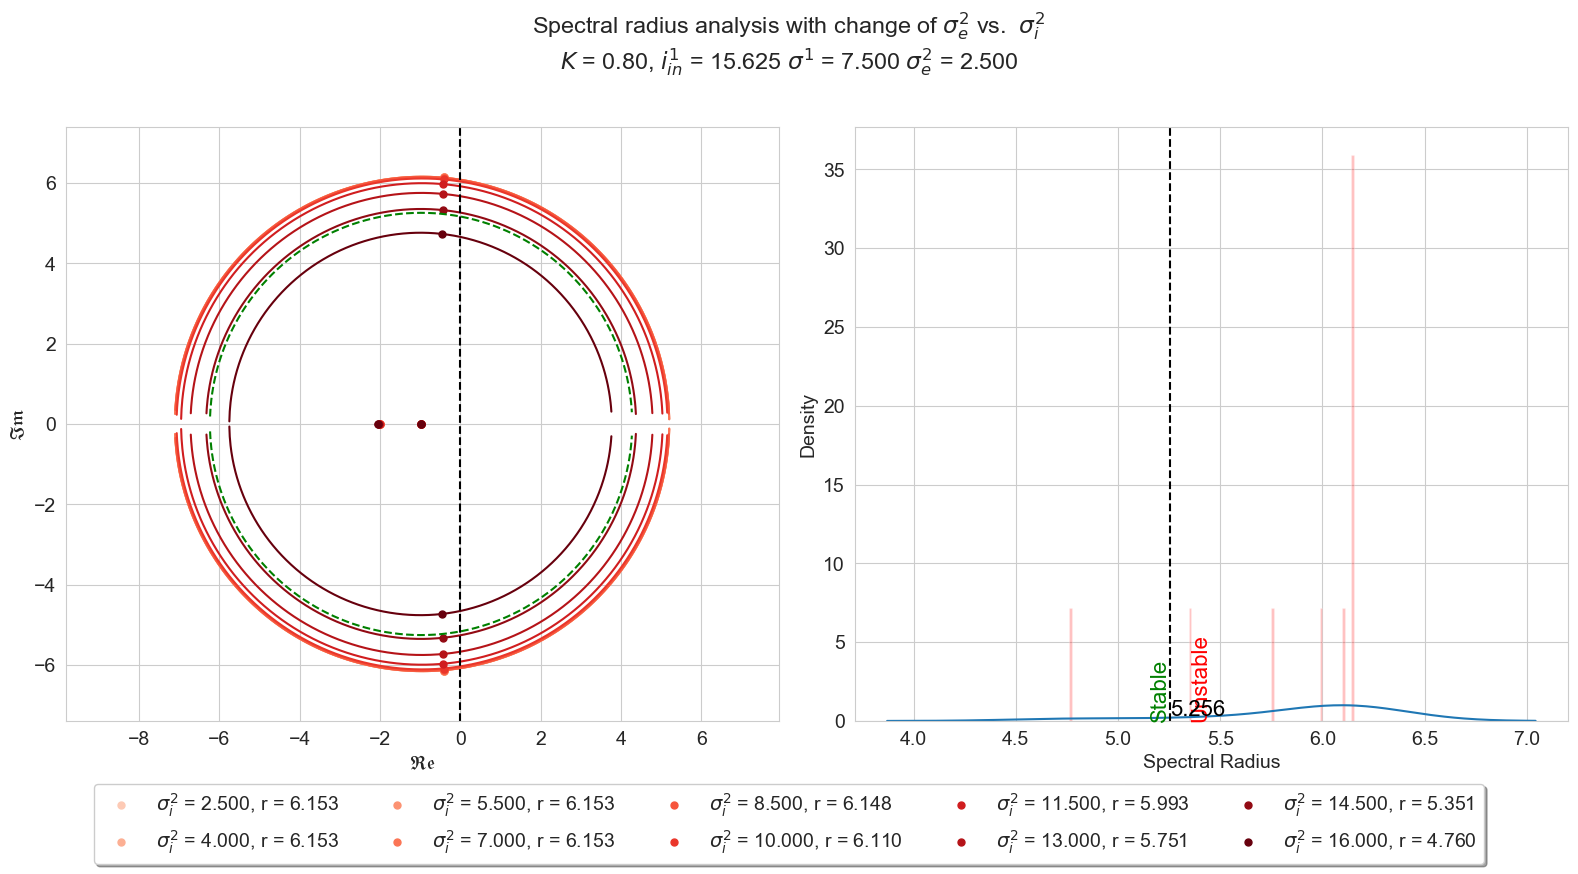

finishing sigma value --> Execution time: 34.091s


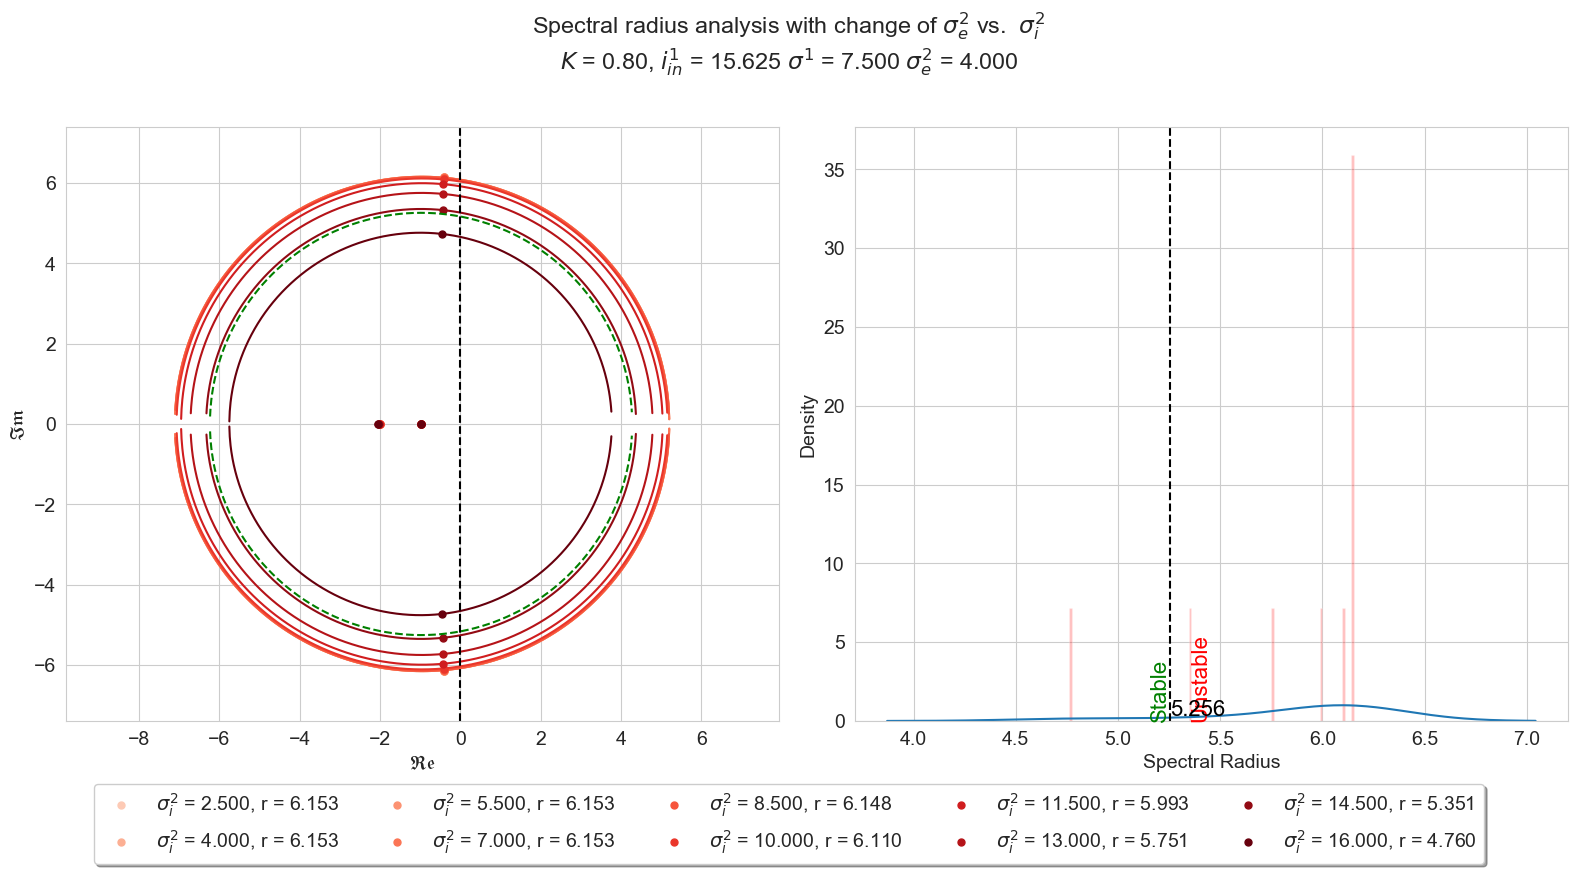

finishing sigma value --> Execution time: 61.982s


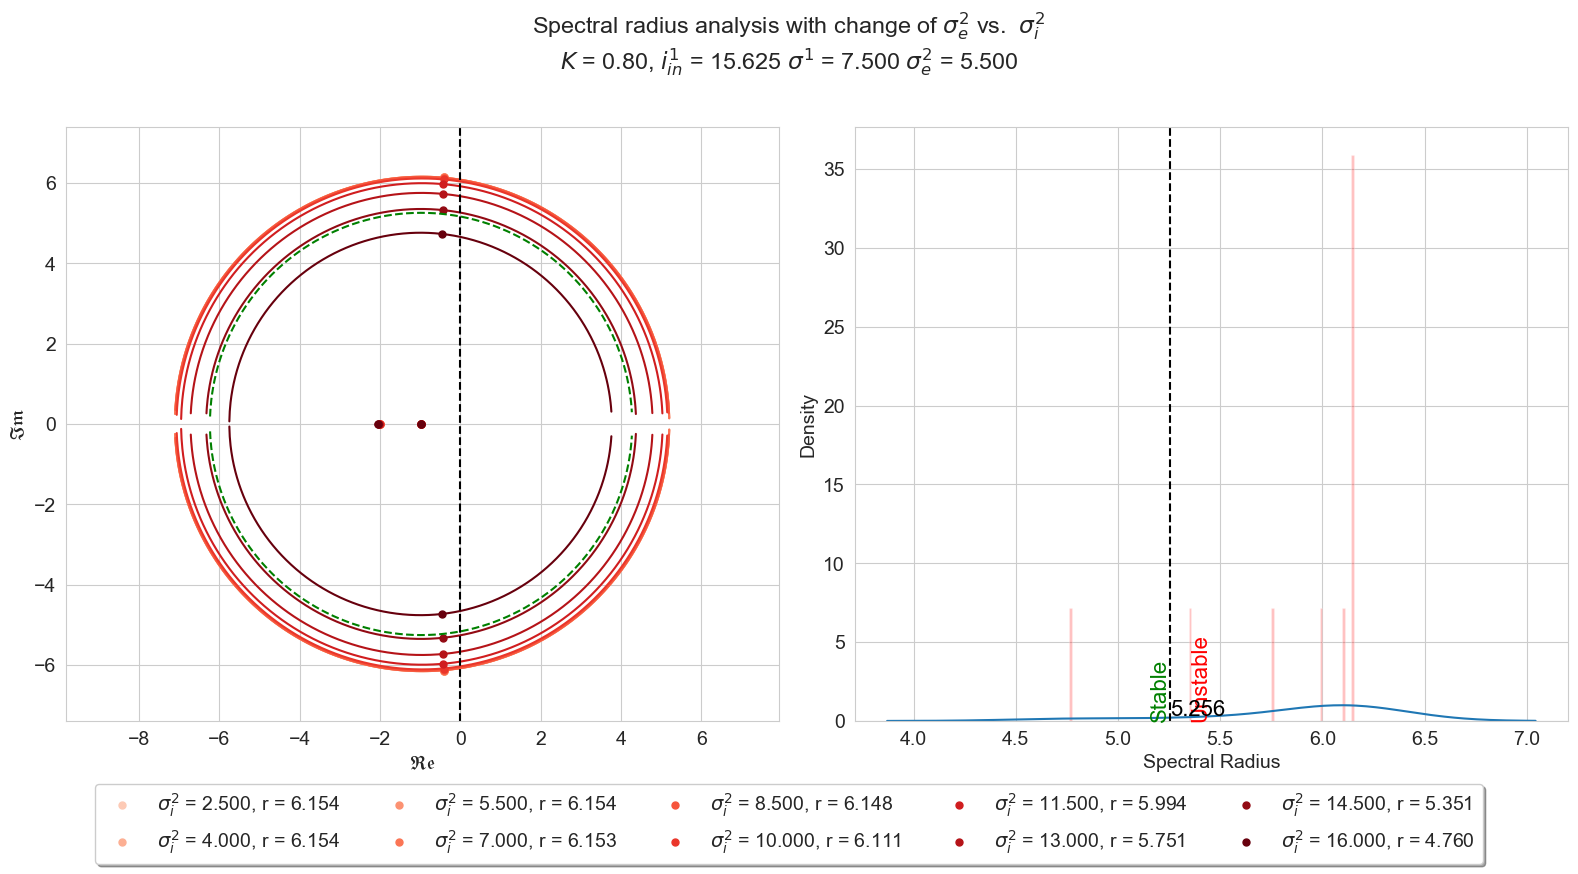

finishing sigma value --> Execution time: 26.192s


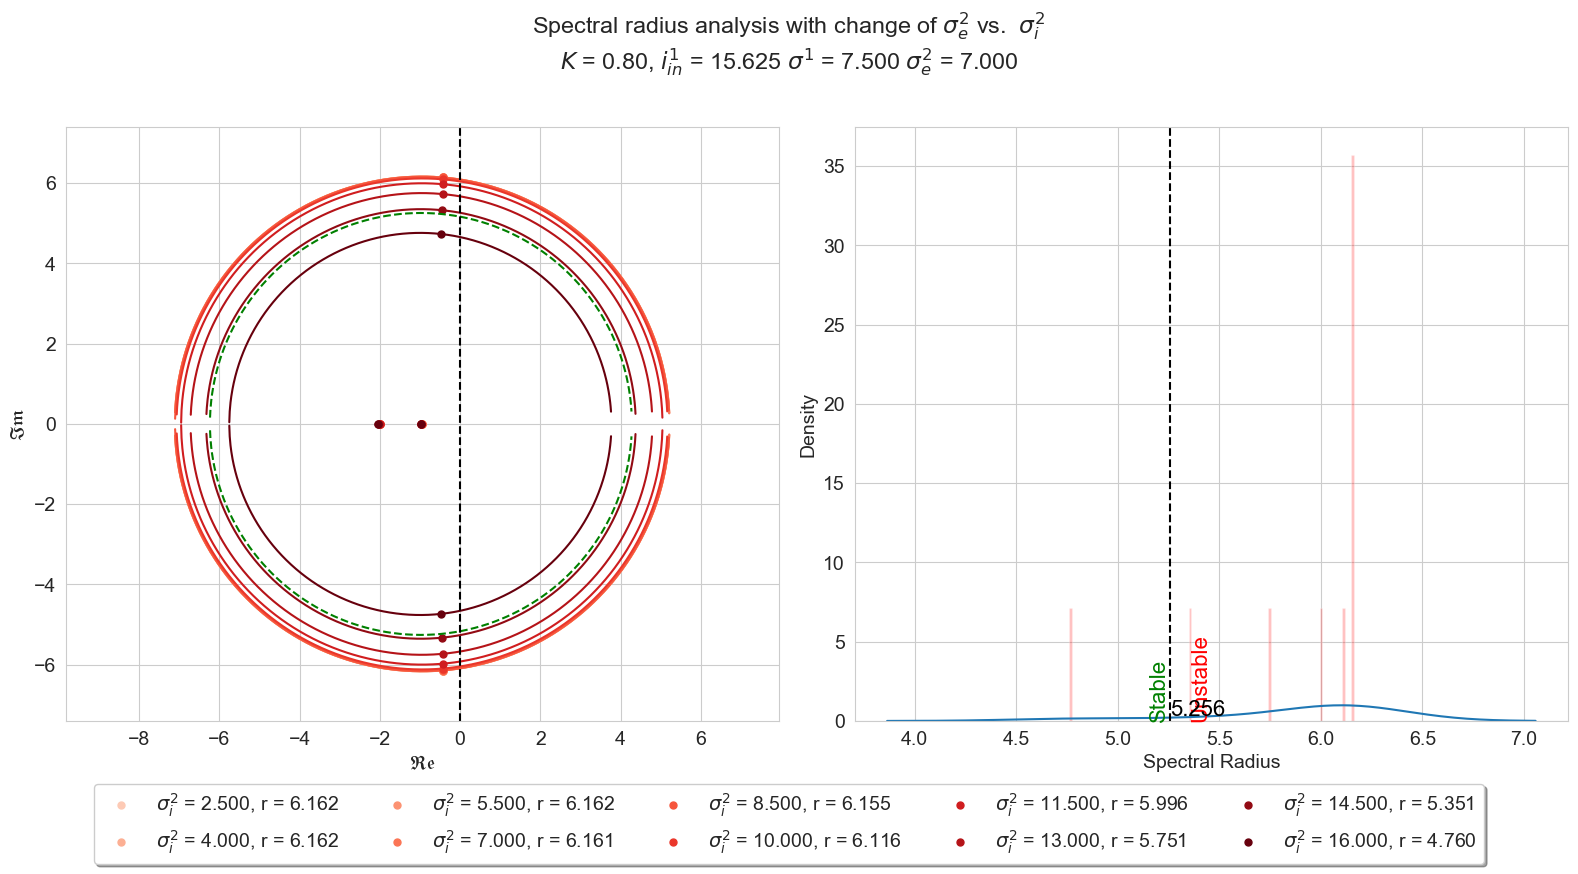

finishing sigma value --> Execution time: 27.095s


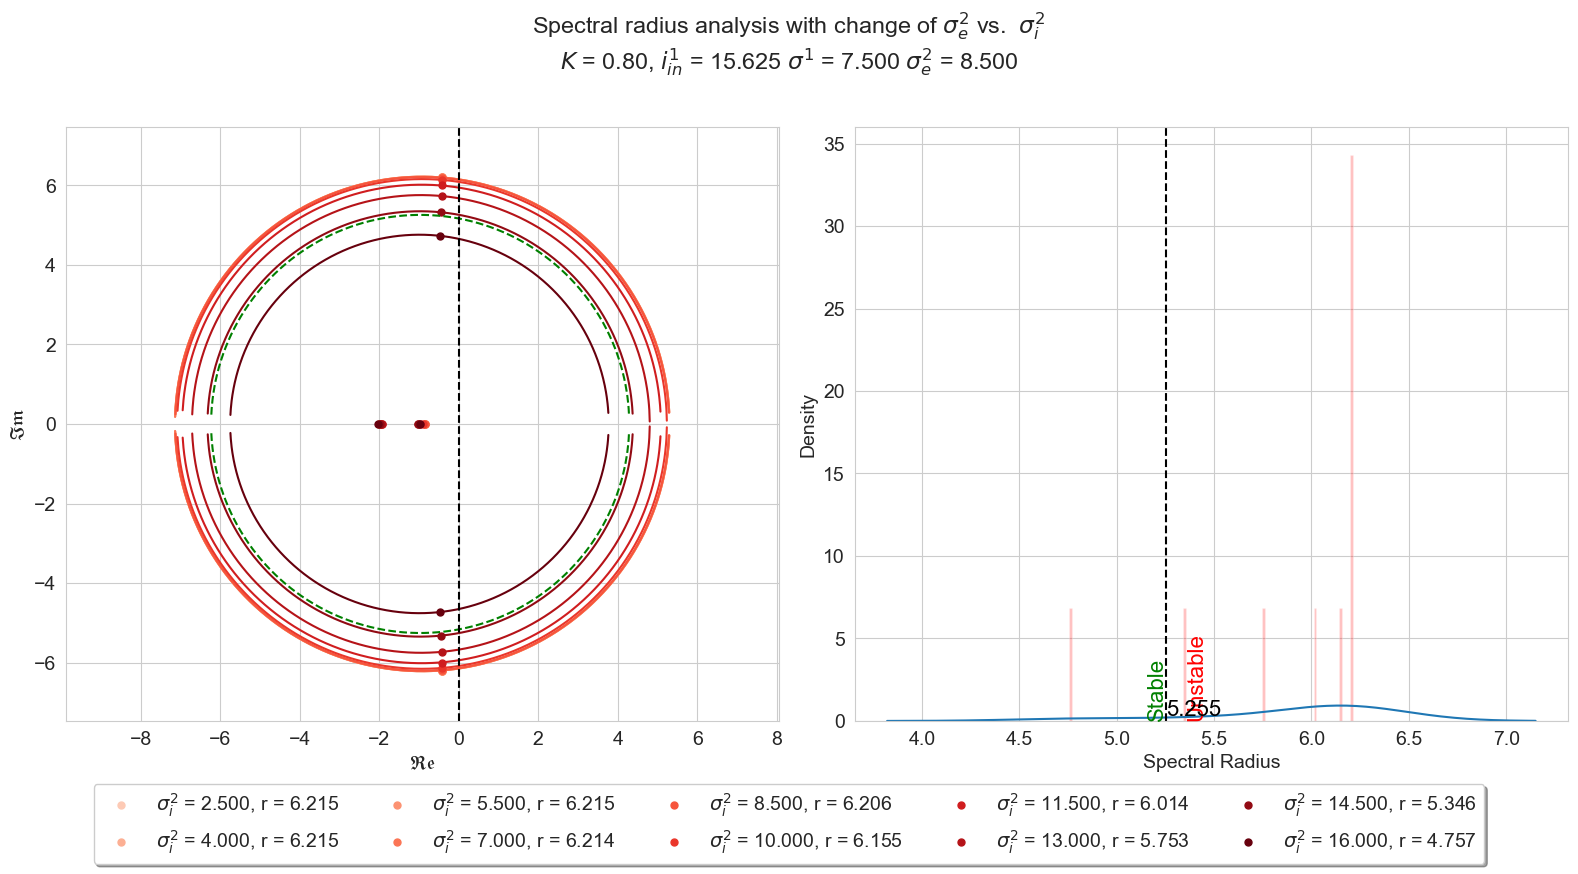

finishing sigma value --> Execution time: 27.895s


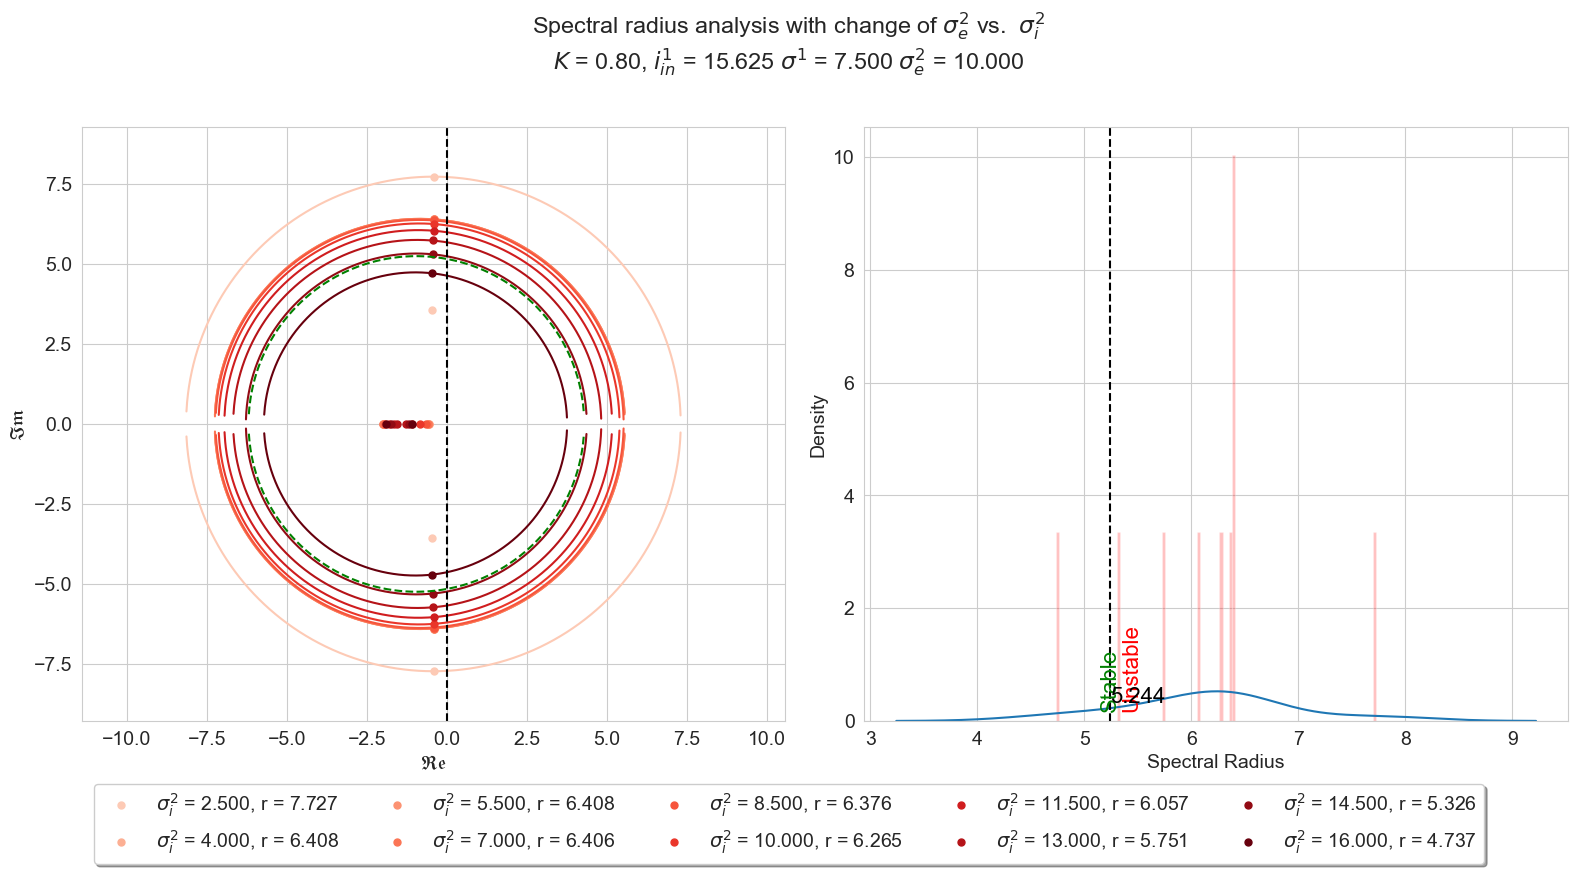

finishing sigma value --> Execution time: 27.083s


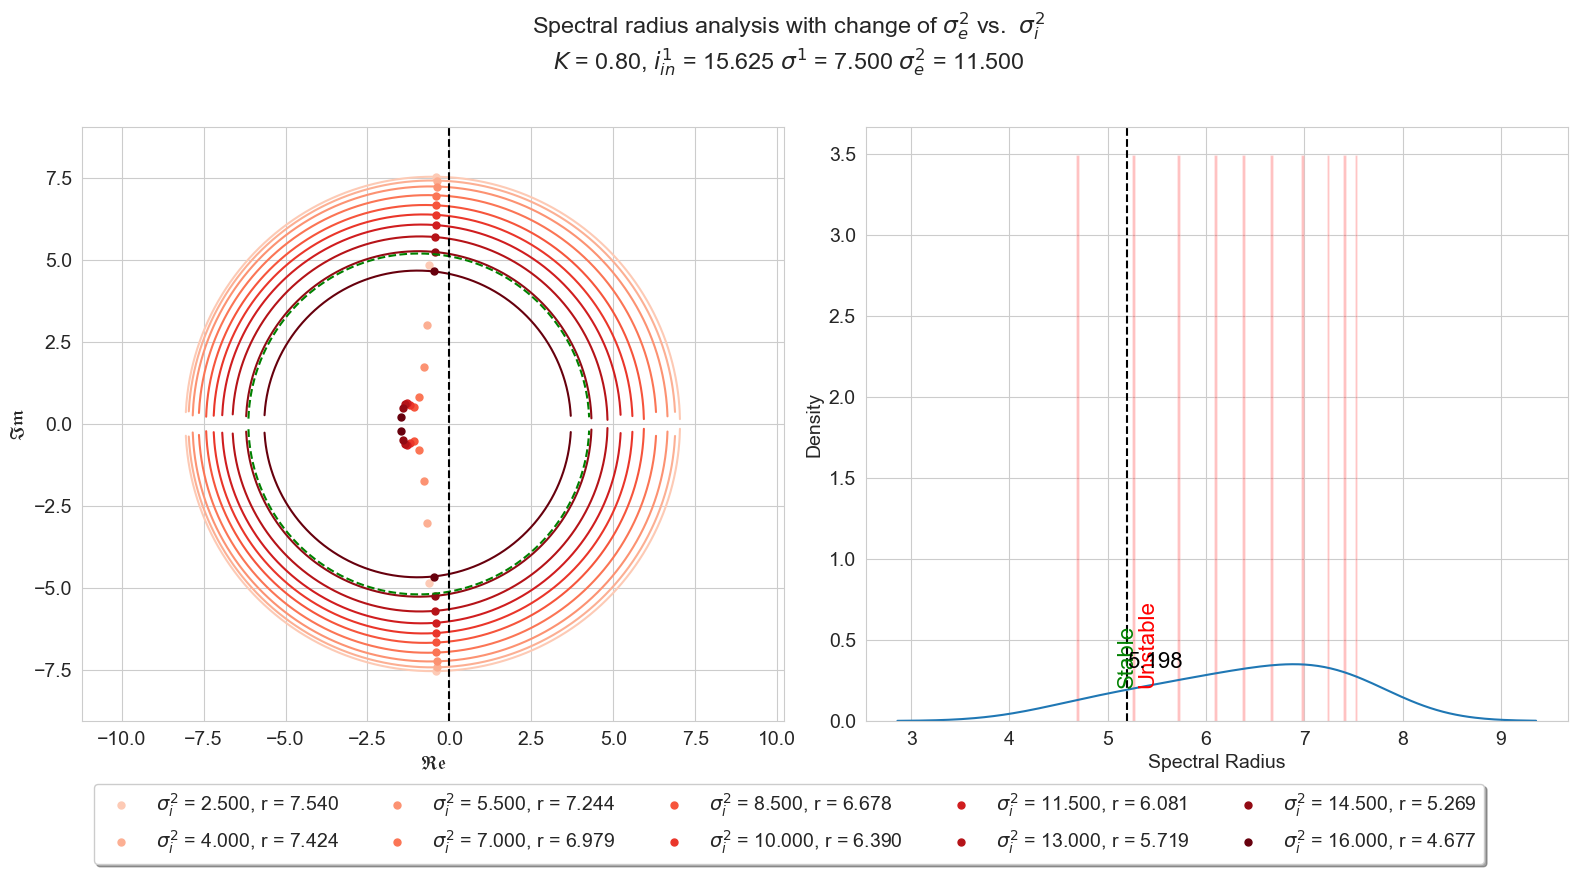

finishing sigma value --> Execution time: 26.925s


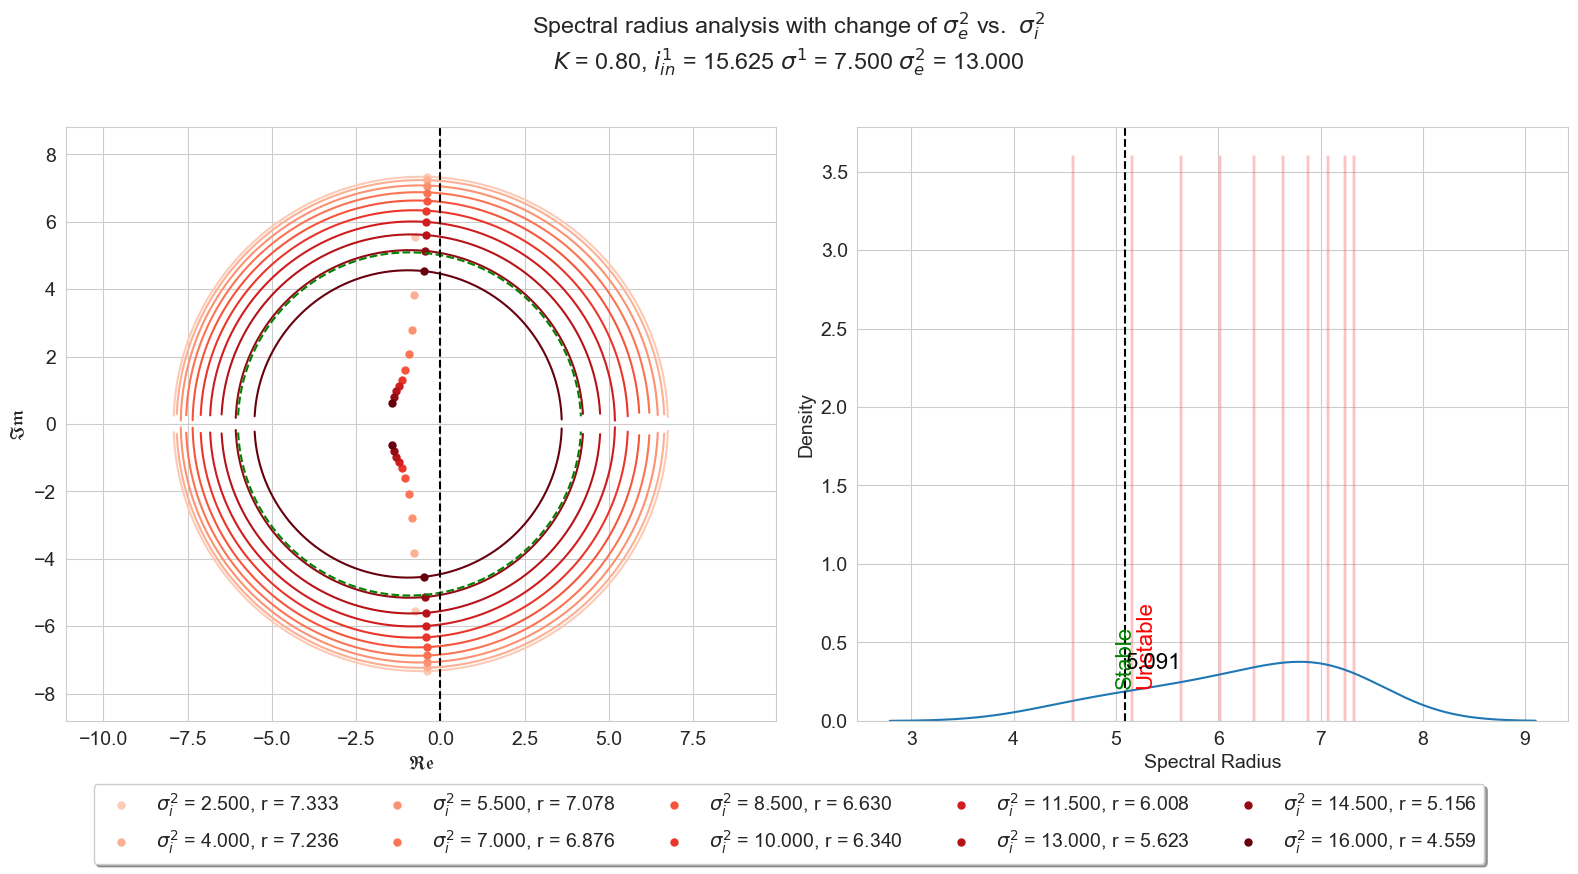

finishing sigma value --> Execution time: 41.866s


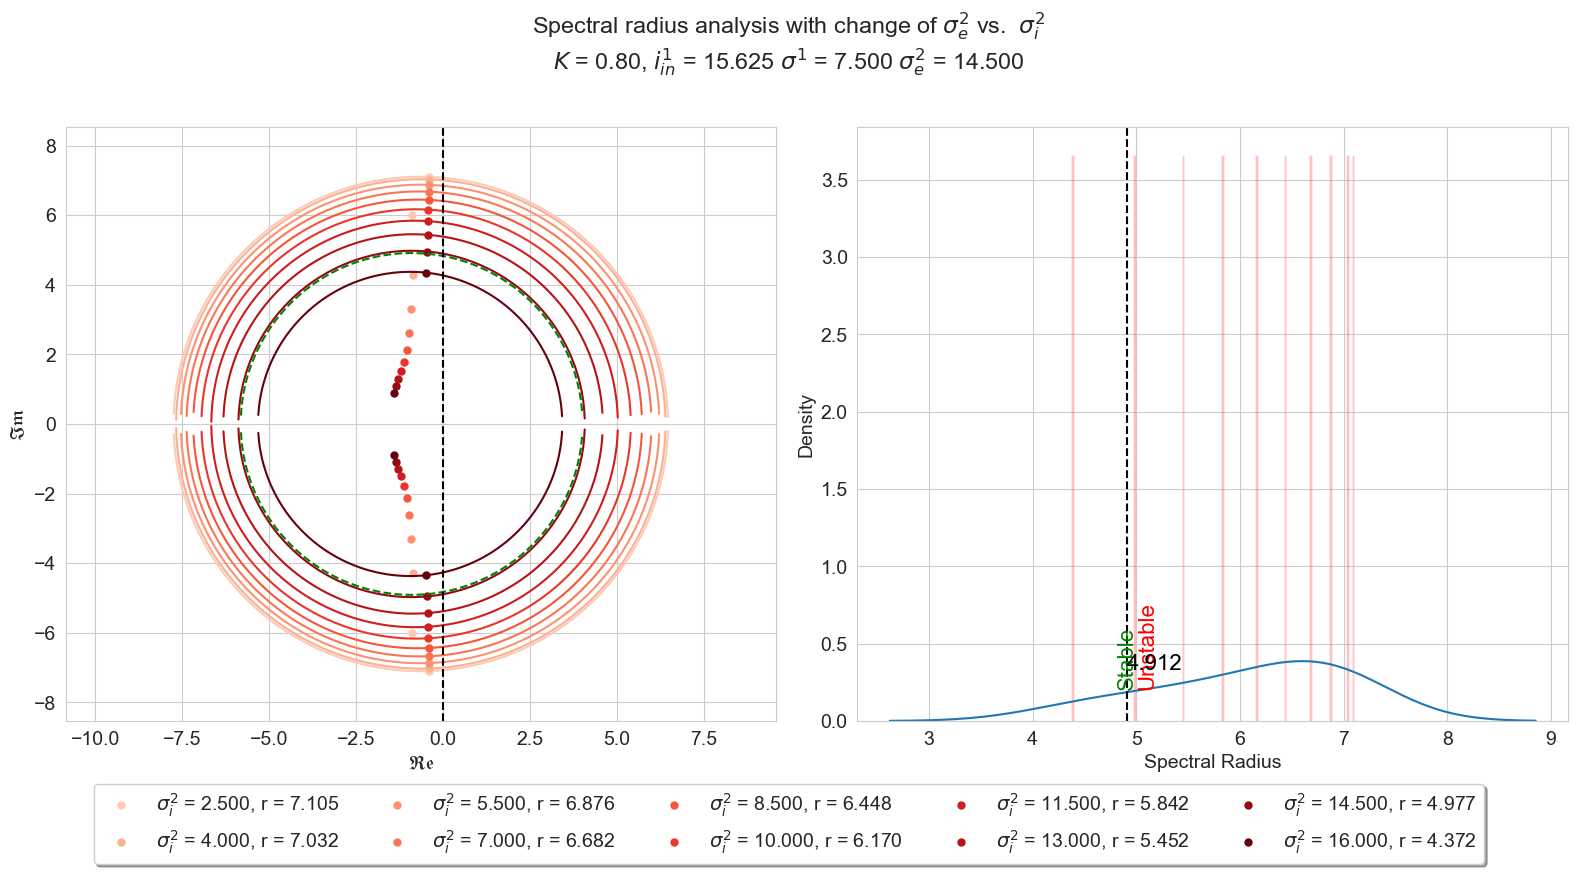

finishing sigma value --> Execution time: 59.961s


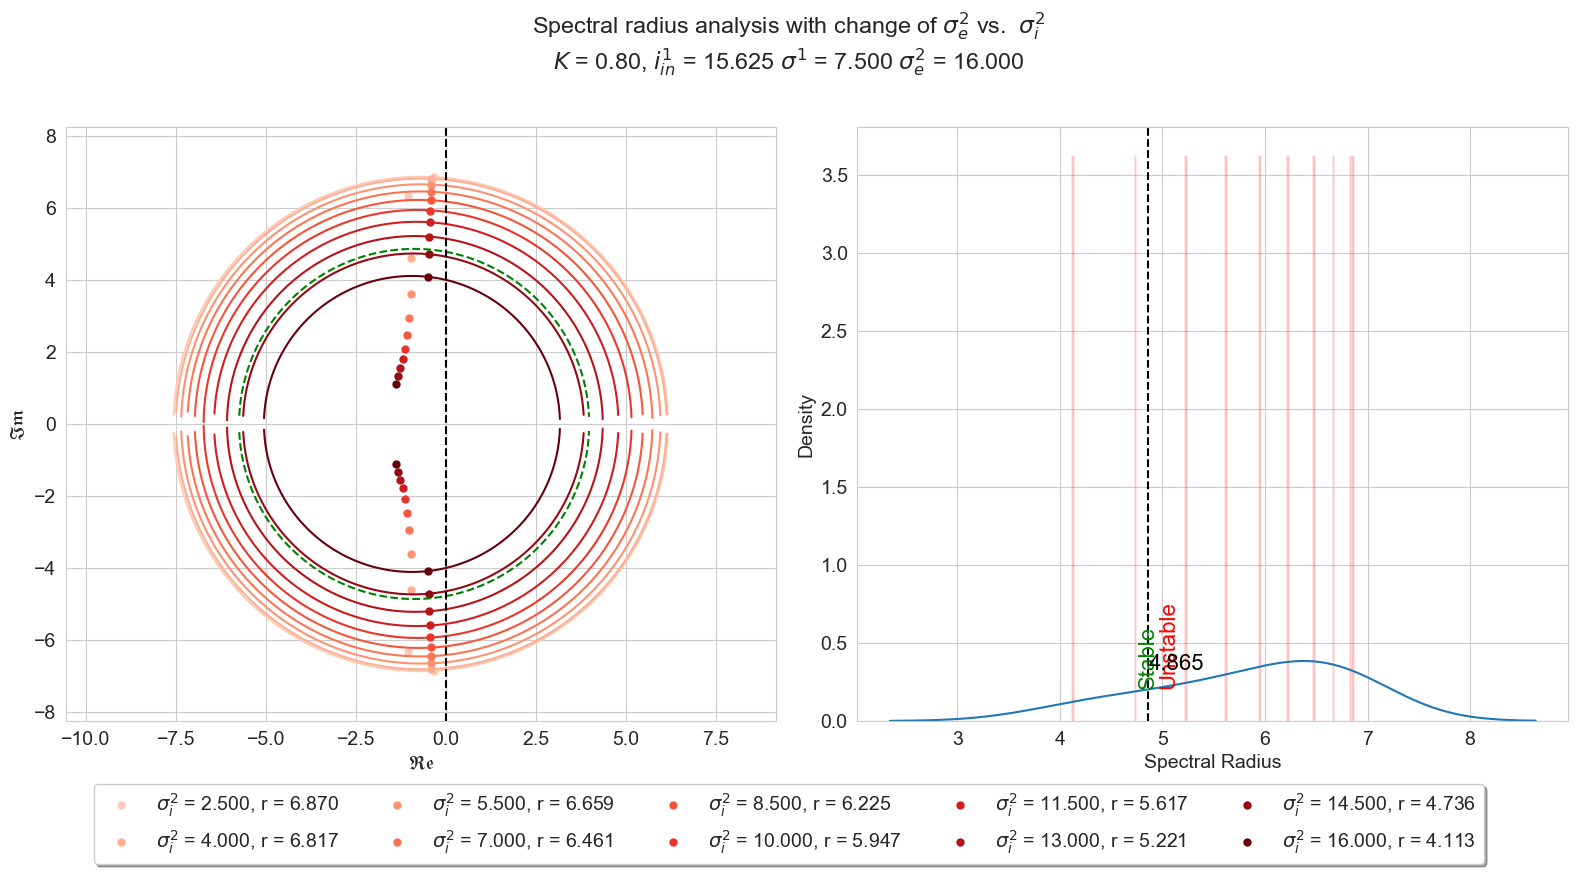

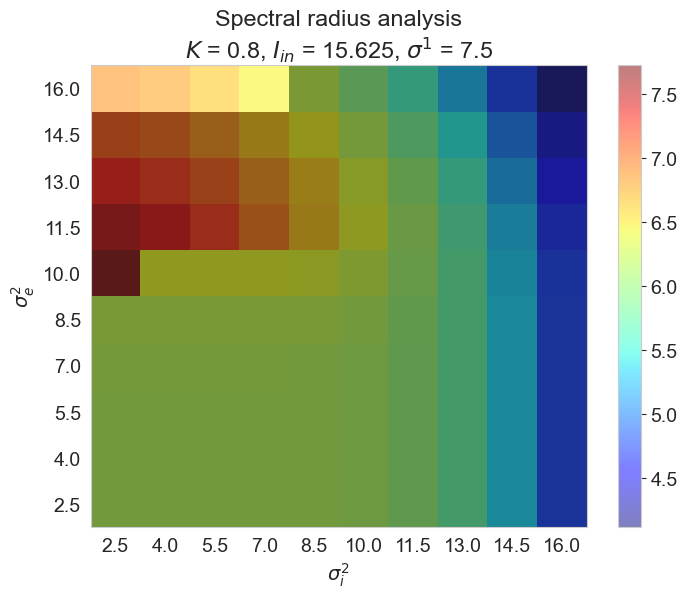

In [65]:
# spectral radius analysis and its link to stability with lyapunov exponent
spec_rad = np.zeros((sige_steps, sigi_steps))
spec_cent = np.zeros((sige_steps, sigi_steps))

x = np.arange(-50, 50, 0.01)

for e1, sig_e in enumerate(eval_sigma_e):
    params['sig_e2'] = sig_e
    rad_stable = None; rad_unstable = None
    cent_stable = None; cent_unstable = None
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 8))
        
    rad_colors = plt.get_cmap('Reds')
    rad_colors = iter(rad_colors(np.linspace(0.2, 1, sig_steps)))
    
    eig_val_colors = plt.get_cmap('Reds')
    eig_val_colors = iter(eig_val_colors(np.linspace(0.2, 1, sig_steps)))
    
    file_str = f"K_{params['K']:.3f}_ie1_{params['i_e1']:.3f}_sig_{params['sig_e1']:.3f}_{params['sig_e2']:.3f}"

    tic = time.time()
    for i1, sig_i in enumerate(eval_sigma_i):
        params['sig_i2'] = sig_i
        
        fp_dict = calc_fixed_points(
                                    minval=minval,
                                    maxval=maxval,
                                    grid_res=1000,
                                    n_init=100,
                                    cal_grad=False,
                                    **params
        )
        
        if fp_dict['n_fps'] == 0:
            u = np.zeros((1, 4, T))
            u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)
            
            fe1 = np.max(u[0, 0, t_start:])
            fi1 = np.max(u[0, 1, t_start:])
            fe2 = np.max(u[0, 2, t_start:])
            fi2 = np.max(u[0, 3, t_start:])
            
            fp_dict['fps'] = np.array([[fe1, fi1, fe2, fi2]]).T
            fp_dict['n_fps'] = 1
        
        eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
        rad_, center_, real_, img_ = spectrum_analysis(eig_dict['eigvals'])
        spec_rad[e1, i1] = rad_
        spec_cent[e1, i1] = center_
        
        lyap_val = thersh_node1[e1, i1] # thresh_mean[e1, i1]
        
        if lyap_val == 1:
            rad_unstable = rad_
            cent_unstable = center_
        
        elif lyap_val == -1 or lyap_val == 0:
            rad_stable = rad_  
            cent_stable = center_
        
        color_rads = next(rad_colors)
        color_eig = next(eig_val_colors)
        
        para_str =  r'$K$ = ' + f"{params['K']:.2f}, " + r'$i_{in}^1$ = ' + f"{params['i_e1']:.3f} " + r'$\sigma^1$ = ' + f"{params['sig_e1']:.3f} " +  r'$\sigma^2_e$ = ' + f"{params['sig_e2']:.3f}"
        ax[0].plot(real_, img_, '.', markersize=10, color=color_eig, label=r"$\sigma^2_i$" + f' = {sig_i:.3f}, r = {rad_:.3f}')
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), color=color_rads)
        
    toc = time.time()
    print(f'finishing sigma value --> Execution time: {toc - tic :.3f}s')
    
    if (rad_unstable != None) and (rad_stable != None):
        rad_ = (rad_unstable + rad_stable) / 2    
        center_ = (cent_unstable + cent_stable) / 2
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--',  color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
    elif (rad_unstable == None) and (rad_stable != None):
        rad_ = spec_rad[e1, 0]  
        center_ = spec_cent[e1, 0]
        ax[0].plot(x, np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--',  color='g')
        ax[0].plot(x, -np.sqrt(rad_ ** 2 - abs(x - center_) ** 2), '--', color='g')
    
    ax[0].axvline(x=0, color='k', linestyle='--')
    ax[0].axis('equal')
    ax[0].grid(True)
    ax[0].set_xlabel(r'$\mathfrak{Re}$');
    ax[0].set_ylabel(r'$\mathfrak{Im}$')
        
    sns.distplot(spec_rad[e1, :], kde=True, bins=20, hist=False, ax=ax[1])
    _, _, bars = ax[1].hist(spec_rad[e1, :], bins = 100, color='red',alpha=0.25, density=True)
    
    if (rad_unstable != None) and (rad_stable != None):
        ax[1].axvline(x=rad_, color='k', linestyle='--')
        ax[1].set_xlabel('Spectral Radius')
        ax[1].text(x = rad_ + 0.1, y = .23, s = 'Unstable', color='red', fontsize=16, animated = True, rotation=90)
        ax[1].text(x = rad_ - 0.1, y = .23, s = 'Stable', color='green', fontsize=16, animated = True, rotation=90)
        ax[1].text(x = rad_, y = .33, s = f'{rad_:.3f}', color='k', fontsize=16)
    elif (rad_unstable == None) and (rad_stable != None):
        ax[1].text(x = min(spec_rad[e1, :]), y = .33, s = 'Whole region is stable', color='green', fontsize=16, animated = True)
    else:
        ax[1].text(x = min(spec_rad[e1, :]), y = .33, s = 'Whole region is unstable', color='red', fontsize=16, animated = True)
    
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.10), ncols=5, fancybox=True, shadow=True)
    plt.suptitle('Spectral radius analysis with change of ' + r"$\sigma^2_e$ vs.  $\sigma^2_i$" + '\n' + para_str + '\n')
    plt.tight_layout()

    plt.savefig(os.path.join(save_dir, scene_sub_dir, file_str + '.png'), dpi=600, bbox_inches='tight')
    plt.show()

plt.figure(figsize=(8, 6))
plt.pcolormesh(eval_sigma_e, eval_sigma_i, thresh_mean, cmap='gist_gray', alpha=0.8)
plt.pcolormesh(eval_sigma_e, eval_sigma_i, spec_rad, cmap='jet', alpha=0.5)
plt.xlabel(r'$\sigma^2_i$'); plt.ylabel(r'$\sigma^2_e$')
plt.xticks(eval_sigma_i); plt.yticks(eval_sigma_e)
plt.colorbar()
plt.title("Spectral radius analysis\n" + r"$K$ = " + f"{params['K']}, " + r"$I_{in}$ = " + f"{params['i_e1']}, " + r"$\sigma^1$ = " + f"{params['sig_i1']}")
plt.savefig(os.path.join(save_dir, scene_sub_dir, f"K_{params['K']}_ie_{params['i_e1']}_sig1_{params['sig_i1']:.3f}_resmap.png"))
plt.show()

In [66]:
# ts analysis and trajectories
params['sig_e2'] = 2.5
params['sig_i2'] = 16.0

u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

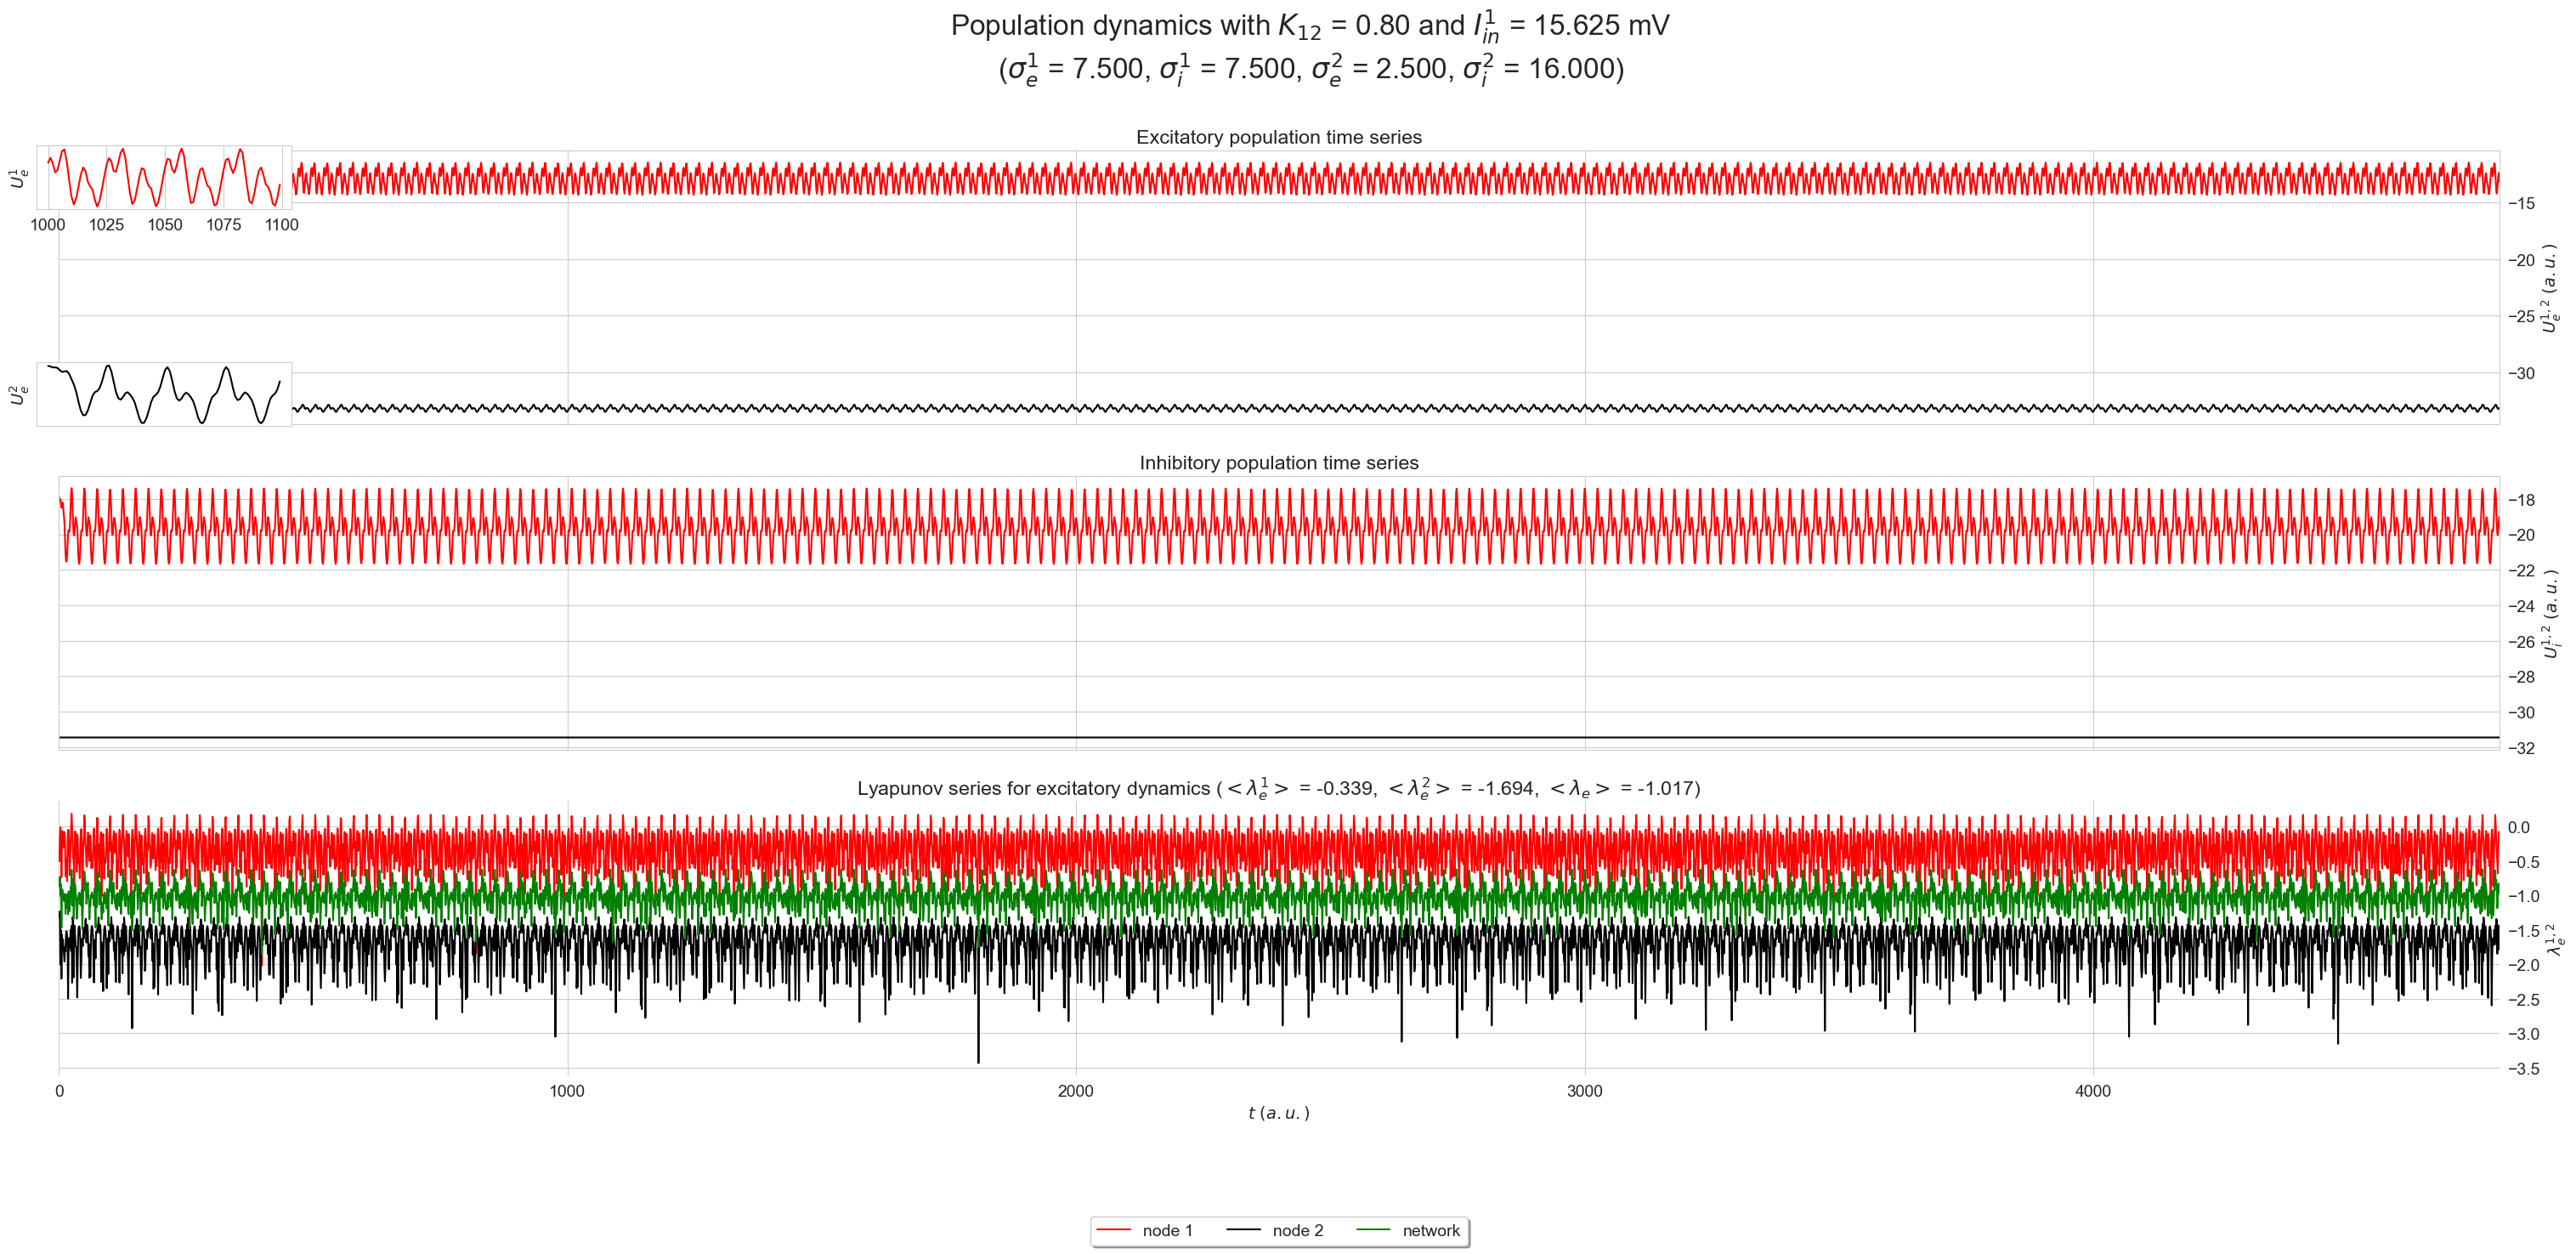

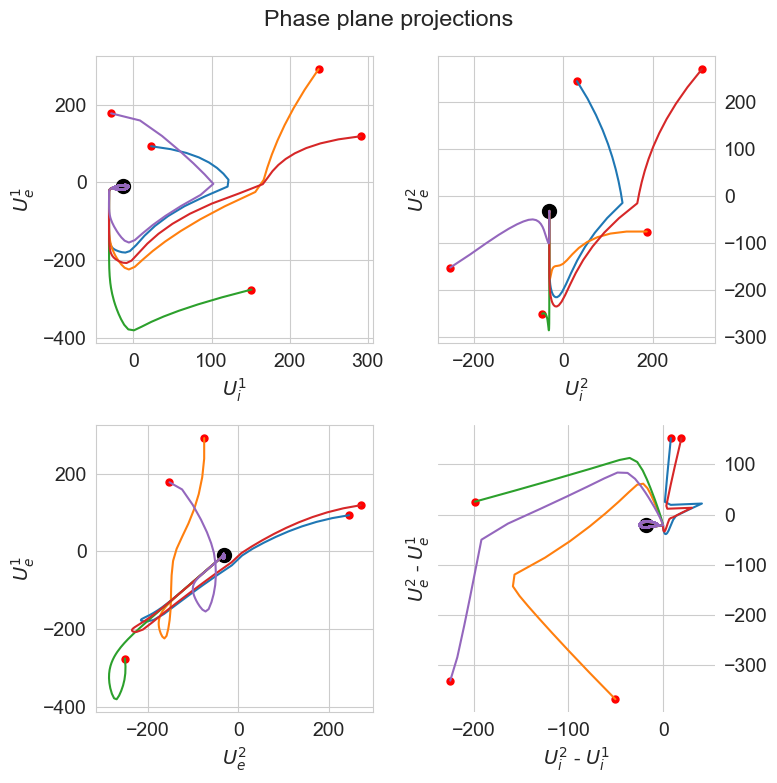

In [67]:
avg_lyap = plot_ts(
    u=u,
    t_arr=time_,
    t1=t_start,
    t2=T,
    fig_size=(30, 15),
    if_zoom=True,
    zoom_t=[1000, 1100, 0, 100],
    if_save=False,
    save_dir=save_dir,
    image_name=f"ts_sige_{params['sig_e1']:.3f}_sigi_{params['sig_i1']:.3f}_K_{params['K']}_iet_{params['i_e1']}",
    **params
)

fp_dict = calc_fixed_points(
    minval=minval,
    maxval=maxval,
    grid_res=1000,
    n_init=100,
    cal_grad=False,
    **params
)

if fp_dict['n_fps'] == 0:
    u_ = np.zeros((1, 4, T))
    u_ = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

    fe1 = np.max(u_[0, 0, t_start:])
    fi1 = np.max(u_[0, 1, t_start:])
    fe2 = np.max(u_[0, 2, t_start:])
    fi2 = np.max(u_[0, 3, t_start:])

    fp_dict['fps'] = np.array([[fe1, fi1, fe2, fi2]]).T
    fp_dict['n_fps'] = 1

    del u_, fe1, fe2, fi1, fi2

eig_dict = calc_jacobian(fp_dict['fps'].T, **params)
plot_trajectory(u, [x0_, x1_, x2_, x3_], (8, 8), **fp_dict)